# *Geant4 Efficiency Enhancing Artifical Neural Network Training (GEEANNT)*

Trying to discard KDSource for reconstructing and resampling particles in Geant4 simulations inner steps. 
The idea is to use ANN to build a model of distribution of incoming particles in a multi-step simulation and then resamples these particles to increase the number of particles reaching the detector, hence improving the statistics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.utils import shuffle
from sklearn import preprocessing
from keras import regularizers
import random
import time
from IPython.display import Image
from scipy.optimize import curve_fit
import time

import scipy.stats as st
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
from matplotlib import ticker
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.axes3d import Axes3D

#import pylandau
#from scipy.integrate import trapz
#from scipy.integrate import simps
from scipy.constants import c, m_e

from astropy.stats import poisson_conf_interval
from scipy.stats import chi2, norm

import keras
keras.__version__


'3.12.0'

## _Dataset Importing and Checks_
Importing datasets of particles registered on the virtual surface dividing stages.

In [34]:
### ---------------------------------------------------------------------------------------------- ###
### USARE PER ADDESTRAMENTO VELOCE, FILE PIU' COMPATTO
### ---------------------------------------------------------------------------------------------- ###

col_list_Det = ["EventId", "ParticleName", "Energy", "X", "Y", "Z", "Vx", "Vy", "Vz"]
# force second column (index 1) to string, all others to float
dtype_map = {name: float for name in col_list_Det}
dtype_map[col_list_Det[1]] = str

#Data_K40 = pd.read_table('/Users/francesco/Desktop/Università/Magistrale/Tesi/Sim/S1GDMLSRON3Step/KDSourceTesting/alloutputDSCryoSphere.dat', names=col_list_Det, dtype=dtype_map)
Data_K40 = pd.read_table('/Users/francesco/Desktop/Università/Magistrale/Tesi/Sim/S1GDMLSRON3Step/GEEANNT/alloutputDSCryoSphereSmall.dat', names=col_list_Det, dtype=dtype_map)

# Remove the first column from Data_K40 (EventIds are not useful for ANN training)
Data_K40.drop(columns=["EventId"], inplace=True)

print("N righe:", len(Data_K40))
print(Data_K40.head())

# Controlli rapidi di NaN / inf
print("\nNaN per colonna:\n", Data_K40.isna().sum())
for c in ["Energy","X","Y","Z","Vx","Vy","Vz"]:
    bad = ~np.isfinite(Data_K40[c].to_numpy())
    if bad.any():
        print(f"Attenzione: {bad.sum()} valori non finiti in {c}")

N righe: 1873609
  ParticleName    Energy        X         Y        Z        Vx        Vy  \
0        gamma  0.150271  19.6164  90.88580 -473.600  0.096896 -0.990521   
1        gamma  0.091620 -31.8887 -82.91700 -463.909  0.913246  0.194270   
2        gamma  0.113628  94.9088   9.60548 -481.123 -0.169791  0.894456   
3        gamma  0.305449 -47.4416 -25.87610 -424.650  0.697276 -0.601885   
4        gamma  0.258675  21.8070  91.71120 -537.841 -0.668961 -0.634526   

         Vz  
0 -0.097358  
1 -0.358107  
2 -0.413667  
3 -0.389283  
4 -0.387128  

NaN per colonna:
 ParticleName    0
Energy          0
X               0
Y               0
Z               0
Vx              0
Vy              0
Vz              0
dtype: int64


In [ ]:
### USARE PER ADDESTRAMENTO VELOCE, FILE PIU' COMPATTO (KDsINPUT format)
### ---------------------------------------------------------------------------------------------- ###

col_list_Det = ["Energy", "X", "Y", "Z", "Vx", "Vy", "Vz"]


Data_K40 = pd.read_table(
    '/Users/francesco/Desktop/Università/Magistrale/Tesi/Sim/S1GDMLSRON3Step/GEEANNT/KDsInput.dat',
    delim_whitespace=True,
    names=col_list_Det,
    dtype=np.float32,
    header=None
)

print("N righe:", len(Data_K40))
print(Data_K40.head())

# Controlli rapidi di NaN / inf
print("\nNaN per colonna:\n", Data_K40.isna().sum())
for c in ["Energy","X","Y","Z","Vx","Vy","Vz"]:
    bad = ~np.isfinite(Data_K40[c].to_numpy())
    if bad.any():
        print(f"Attenzione: {bad.sum()} valori non finiti in {c}")

/var/folders/l7/67sx0h9j2zz3l3b80sx34dj00000gn/T/ipykernel_48624/3122547659.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  Data_K40 = pd.read_table(


N righe: 1859149
     Energy        X         Y          Z        Vx        Vy        Vz
0  0.150271  1.96164  9.088580 -47.360001  0.096896 -0.990521 -0.097358
1  0.091620 -3.18887 -8.291700 -46.390900  0.913246  0.194270 -0.358107
2  0.113628  9.49088  0.960548 -48.112301 -0.169791  0.894456 -0.413667
3  0.305449 -4.74416 -2.587610 -42.465000  0.697276 -0.601885 -0.389283
4  0.258675  2.18070  9.171120 -53.784100 -0.668961 -0.634526 -0.387128

NaN per colonna:
 Energy    0
X         0
Y         0
Z         0
Vx        0
Vy        0
Vz        0
dtype: int64


In [31]:
### ----------------------- APRI QUANDO IL MODELLO SARA' PRONTO ----------------------------------- ###
### USARE SOLO QUANDO IL MODELLO SARA' PRONTO. FILE MOLTO PESANTE, NON SI PUO' CARICARE OGNI VOLTA
### ---------------------------------------------------------------------------------------------- ###

col_list_Det = ["EventId", "ParticleName", "Energy", "PhysProcess", "X", "Y", "Z", "Vx", "Vy", "Vz"]
# force second column (index 1) to string, all others to float
dtype_map = {name: float for name in col_list_Det}
dtype_map[col_list_Det[1]] = str
dtype_map[col_list_Det[3]] = str

Data_K40 = pd.read_table('/Users/francesco/Desktop/Università/Magistrale/Tesi/Sim/S1GDMLSRON3Step/GEEANNT/AlloutputDSCryoSphereBig.dat', names=col_list_Det, dtype=dtype_map, nrows=2_000_000, low_memory=False)

# Remove the first column from Data_K40 (EventIds are not useful for ANN training)
Data_K40.drop(columns=["EventId", "PhysProcess"], inplace=True)
#Data_K40.drop(columns=Data_K40.columns[0], inplace=True)
#Data_K40.drop(columns=Data_K40.columns[2], inplace=True)

print("N righe:", len(Data_K40))
print(Data_K40.head())

# Controlli rapidi di NaN / inf
print("\nNaN per colonna:\n", Data_K40.isna().sum())
for c in ["Energy","X","Y","Z","Vx","Vy","Vz"]:
    bad = ~np.isfinite(Data_K40[c].to_numpy())
    if bad.any():
        print(f"Attenzione: {bad.sum()} valori non finiti in {c}")

N righe: 2000000
  ParticleName    Energy        X        Y        Z        Vx        Vy  \
0        gamma  0.208920 -86.1871 -15.1104 -461.292  0.189948  0.504246   
1        gamma  0.219854 -26.5480 -77.9504 -564.336 -0.325228 -0.659062   
2        gamma  0.217032  88.7077  37.6837 -480.938  0.393747 -0.132461   
3        gamma  0.231447  32.5341 -27.5748 -418.257 -0.148199  0.817159   
4        gamma  0.229992 -77.5040  58.3868 -487.976 -0.038062 -0.815345   

         Vz  
0 -0.842411  
1 -0.678133  
2 -0.909625  
3 -0.557035  
4 -0.577723  

NaN per colonna:
 ParticleName    0
Energy          0
X               0
Y               0
Z               0
Vx              0
Vy              0
Vz              0
dtype: int64


## Controllo tutti i parametri spaziali e angolari e come le loro distribuzioni vengono modificate durante la standardizzazione


--- Controllo sfera RAW (r = ||x-C||) ---
r: mean = 99.23411918434232  std = 0.40461867908293037  min = 98.93981564523723  max = 100.06006989051981
Deviazione media da R: 0.7682885734999307

--- Controllo norma direzione RAW (||v||) ---
||v||: mean = 0.9999999998903653  std = 2.88613664129066e-07  min = 0.9999991604741476  max = 1.0000008313726545
Deviazione media da 1: 2.402573376849245e-07

--- Controllo energia ---
E: min = 0.0011044  max = 1.46082  #E<=0 = 0

--- Controllo sfera PROIETTATA ---
r_proj: mean = 99.99999999999902  std = 2.2897201782837348e-14  min = 99.99999999999896  max = 99.99999999999903
Deviazione media da R: 1.0007113932897926e-12

--- Controllo direzione RINORMALIZZATA ---
||vhat||: mean = 0.9999999999990034  std = 3.408393483818028e-15  min = 0.9999999999989996  max = 0.9999999999990002
Deviazione media da 1: 1.0000542428995967e-12


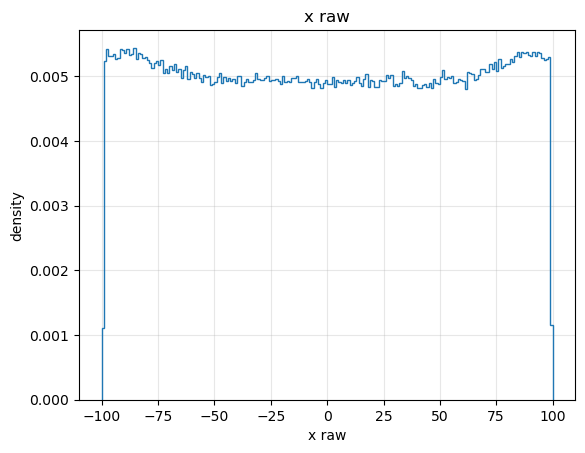

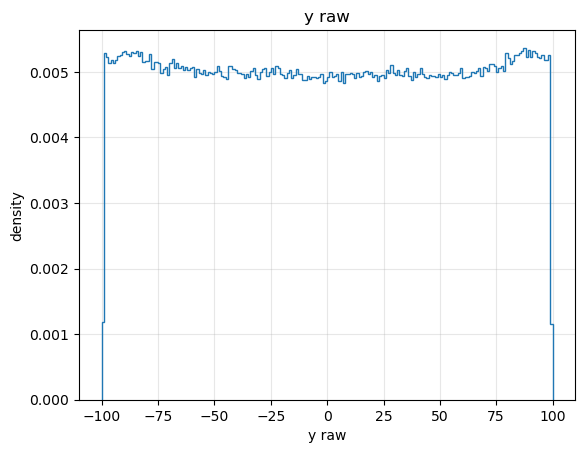

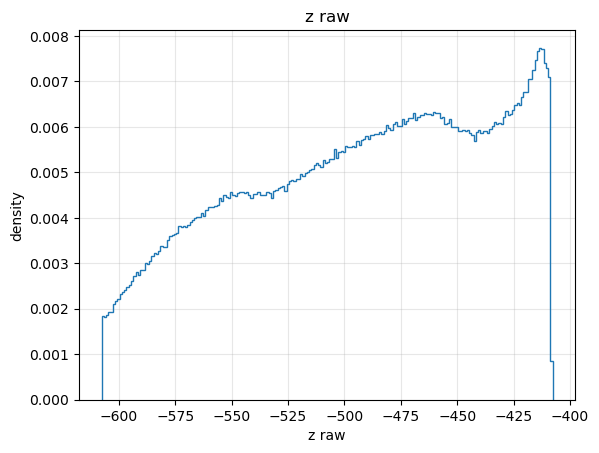

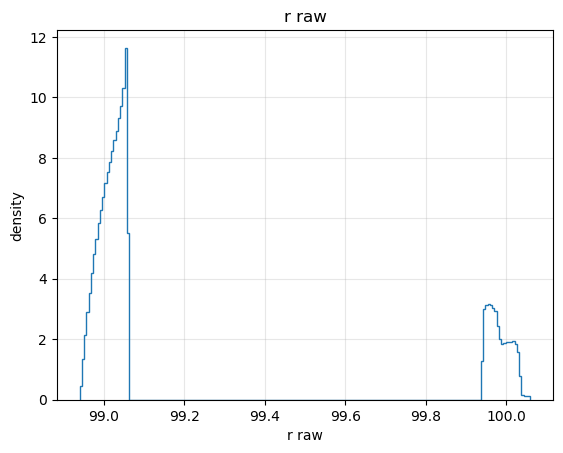

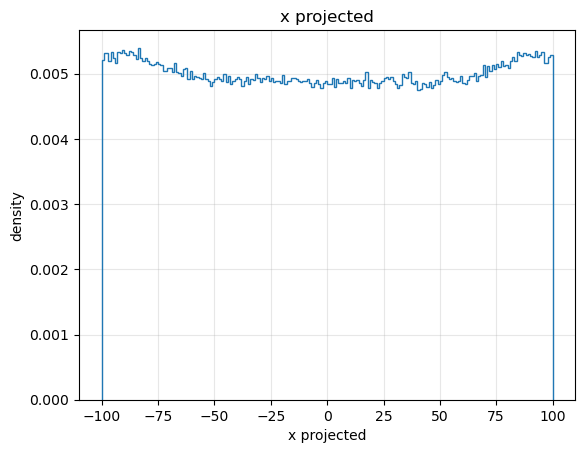

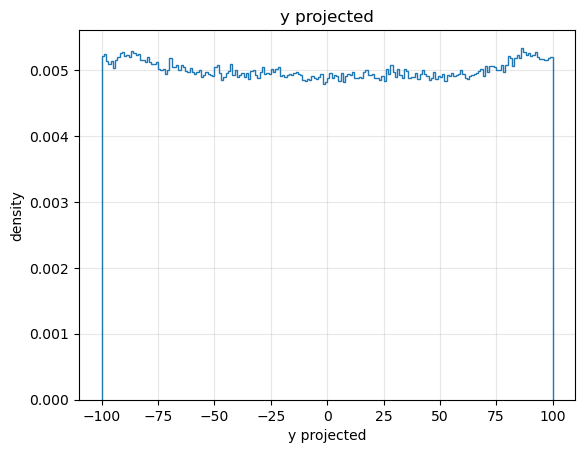

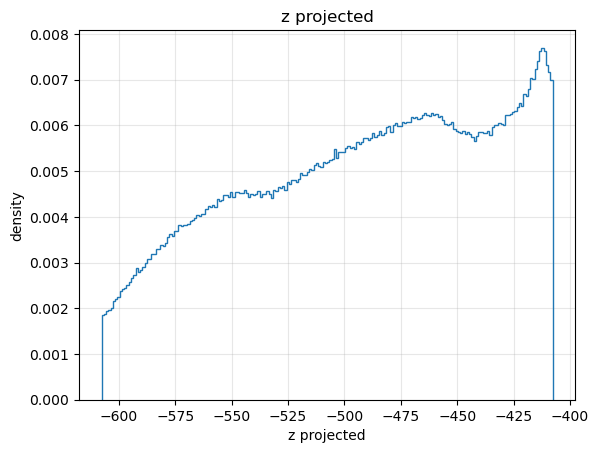

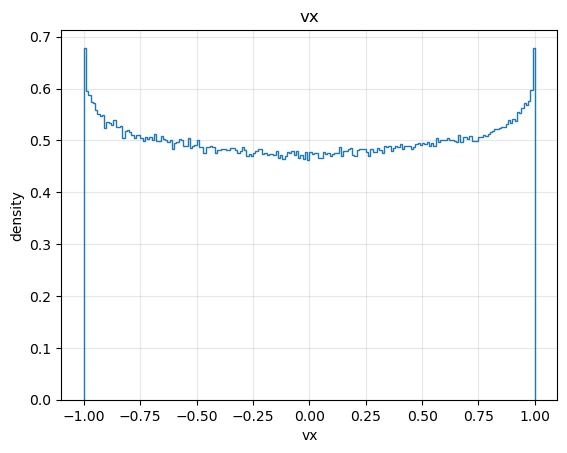

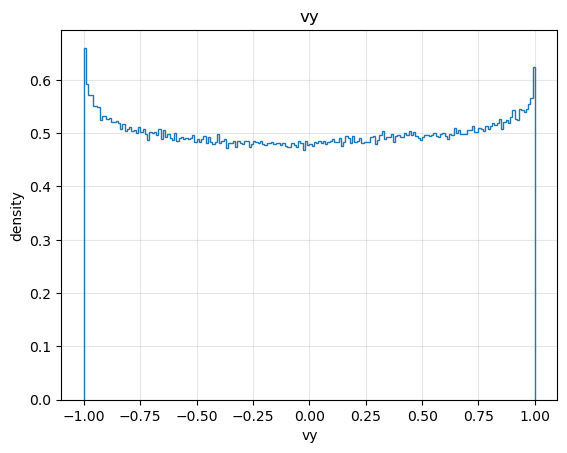

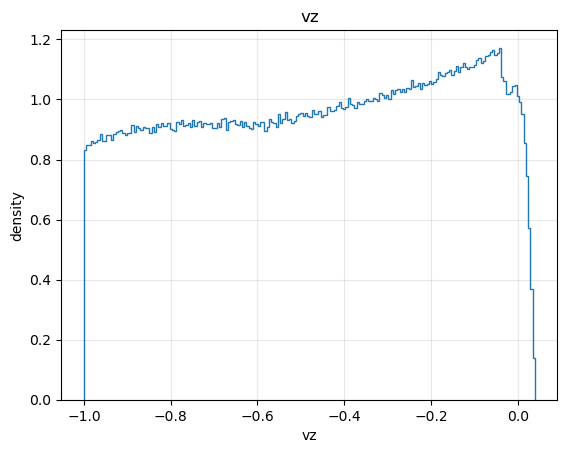

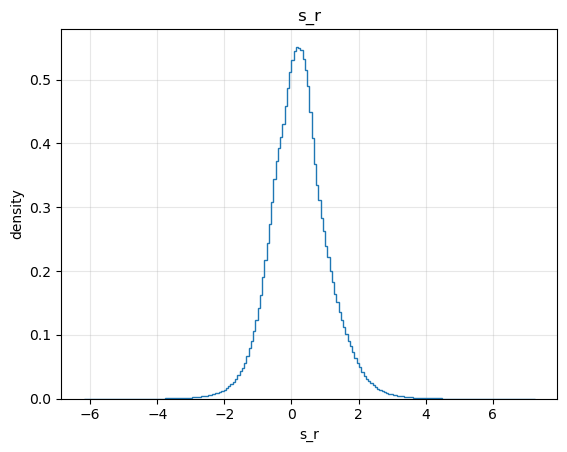

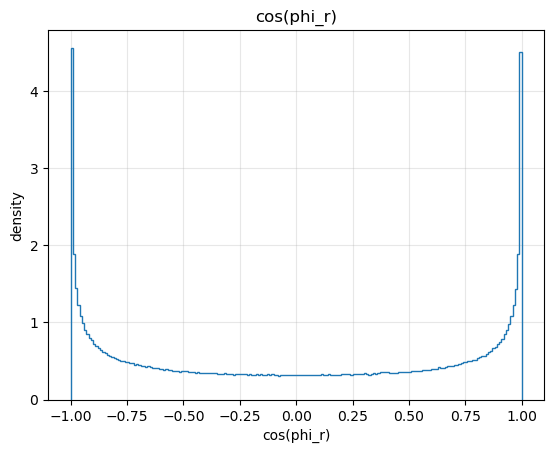

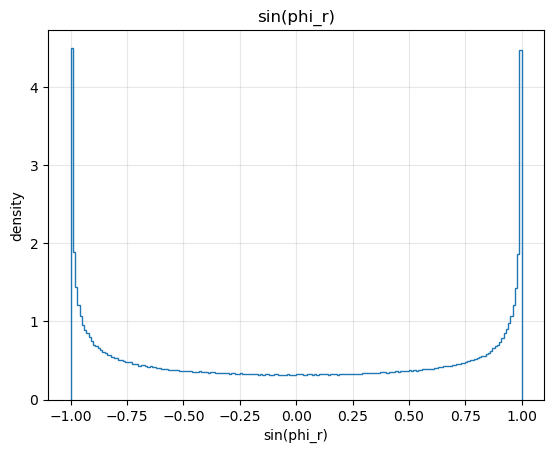

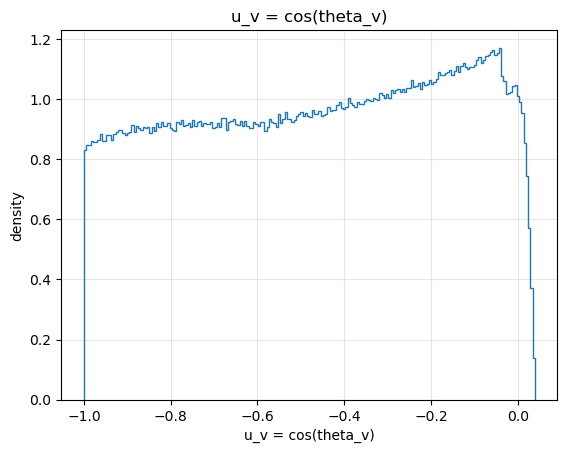

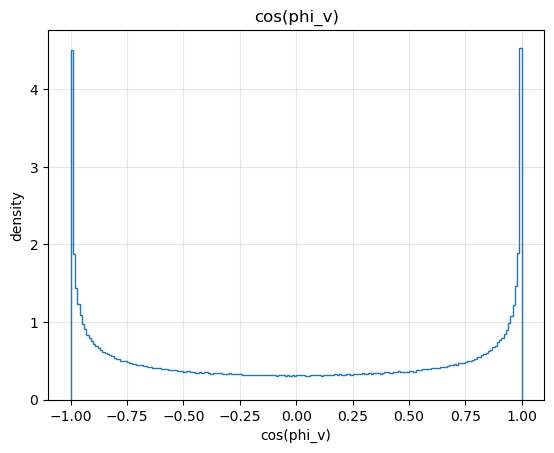

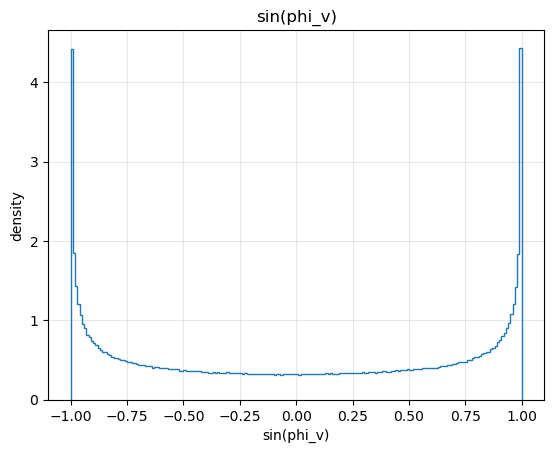

In [8]:
C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-6

xyz = Data_K40[["X", "Y", "Z"]].to_numpy(dtype=np.float64)
v   = Data_K40[["Vx", "Vy", "Vz"]].to_numpy(dtype=np.float64)
E   = Data_K40["Energy"].to_numpy(dtype=np.float64)

x = xyz[:, 0]
y = xyz[:, 1]
z = xyz[:, 2]

vx = v[:, 0]
vy = v[:, 1]
vz = v[:, 2]

# =========================
# Controlli fisici iniziali
# =========================

rvec = xyz - C[None, :]
r = np.linalg.norm(rvec, axis=1)
vnorm = np.linalg.norm(v, axis=1)

print("\n--- Controllo sfera RAW (r = ||x-C||) ---")
print("r: mean =", r.mean(), " std =", r.std(), " min =", r.min(), " max =", r.max())
print("Deviazione media da R:", np.mean(np.abs(r - R)))

print("\n--- Controllo norma direzione RAW (||v||) ---")
print("||v||: mean =", vnorm.mean(), " std =", vnorm.std(), " min =", vnorm.min(), " max =", vnorm.max())
print("Deviazione media da 1:", np.mean(np.abs(vnorm - 1.0)))

print("\n--- Controllo energia ---")
print("E: min =", E.min(), " max =", E.max(), " #E<=0 =", np.sum(E <= 0))

# =========================
# Filtro su energia valida
# =========================

mask_posE = (E > 0) & np.isfinite(E)
if not mask_posE.all():
    print(f"\nRimuovo {np.sum(~mask_posE)} righe con E<=0 o non finita.")
    Data_K40 = Data_K40.loc[mask_posE].reset_index(drop=True)

    xyz = Data_K40[["X", "Y", "Z"]].to_numpy(dtype=np.float64)
    v   = Data_K40[["Vx", "Vy", "Vz"]].to_numpy(dtype=np.float64)
    E   = Data_K40["Energy"].to_numpy(dtype=np.float64)

    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    vx = v[:, 0]
    vy = v[:, 1]
    vz = v[:, 2]

    rvec = xyz - C[None, :]
    r = np.linalg.norm(rvec, axis=1)
    vnorm = np.linalg.norm(v, axis=1)

# =========================
# REGOLARIZZAZIONE POSIZIONE:
# proiezione di tutti i punti sulla sfera di raggio R
# =========================

rhat = rvec / (r[:, None] + 1e-12)      # versore radiale
rvec_proj = R * rhat
xyz_proj = C[None, :] + rvec_proj

x_proj = xyz_proj[:, 0]
y_proj = xyz_proj[:, 1]
z_proj = xyz_proj[:, 2]

# check dopo proiezione
r_proj = np.linalg.norm(rvec_proj, axis=1)
print("\n--- Controllo sfera PROIETTATA ---")
print("r_proj: mean =", r_proj.mean(), " std =", r_proj.std(), " min =", r_proj.min(), " max =", r_proj.max())
print("Deviazione media da R:", np.mean(np.abs(r_proj - R)))

# =========================
# REGOLARIZZAZIONE DIREZIONE:
# rinormalizzo per sicurezza numerica
# =========================

vhat = v / (vnorm[:, None] + 1e-12)

vx_hat = vhat[:, 0]
vy_hat = vhat[:, 1]
vz_hat = vhat[:, 2]

vnorm_hat = np.linalg.norm(vhat, axis=1)
print("\n--- Controllo direzione RINORMALIZZATA ---")
print("||vhat||: mean =", vnorm_hat.mean(), " std =", vnorm_hat.std(), " min =", vnorm_hat.min(), " max =", vnorm_hat.max())
print("Deviazione media da 1:", np.mean(np.abs(vnorm_hat - 1.0)))

# =========================
# COSTRUZIONE FEATURE
# x = [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
# =========================

# posizione dalla sfera proiettata
u_r = np.clip(rhat[:, 2], -1.0 + eps, 1.0 - eps)
s_r = np.arctanh(u_r)

phi_r = np.arctan2(rhat[:, 1], rhat[:, 0])
cphi_r = np.cos(phi_r)
sphi_r = np.sin(phi_r)

# direzione dal vettore rinormalizzato
u_v = np.clip(vz_hat, -1.0 + eps, 1.0 - eps)

phi_v = np.arctan2(vy_hat, vx_hat)
cphi_v = np.cos(phi_v)
sphi_v = np.sin(phi_v)

# energia
logE = np.log10(E)

# =========================
# Funzione per plot
# =========================

def plot_dist(data, name, bins=200):
    plt.figure()
    plt.hist(data, bins=bins, density=True, histtype="step")
    plt.xlabel(name)
    plt.ylabel("density")
    plt.title(name)
    plt.grid(True, alpha=0.3)
    plt.show()

# =========================
# Plot posizione RAW
# =========================

plot_dist(x, "x raw")
plot_dist(y, "y raw")
plot_dist(z, "z raw")
plot_dist(r, "r raw")

# =========================
# Plot posizione PROIETTATA
# =========================

plot_dist(x_proj, "x projected")
plot_dist(y_proj, "y projected")
plot_dist(z_proj, "z projected")
#plot_dist(r_proj, "r projected")

# =========================
# Plot direzioni
# =========================

plot_dist(vx_hat, "vx")
plot_dist(vy_hat, "vy")
plot_dist(vz_hat, "vz")

# =========================
# Plot feature posizione
# =========================

plot_dist(s_r, "s_r")
plot_dist(cphi_r, "cos(phi_r)")
plot_dist(sphi_r, "sin(phi_r)")

# =========================
# Plot feature direzione
# =========================

plot_dist(u_v, "u_v = cos(theta_v)")
plot_dist(cphi_v, "cos(phi_v)")
plot_dist(sphi_v, "sin(phi_v)")

In [9]:
print("r mean =", r.mean())
print("r median =", np.median(r))
print("r std =", r.std())
print("r min/max =", r.min(), r.max())

# Centro geometrico approssimato dei punti
print("mean x,y,z =", xyz.mean(axis=0))

# range coordinate
print("x min/max =", x.min(), x.max())
print("y min/max =", y.min(), y.max())
print("z min/max =", z.min(), z.max())

r mean = 99.23411918434232
r median = 99.03347981046613
r std = 0.40461867908293037
r min/max = 98.93981564523723 100.06006989051981
mean x,y,z = [-1.64135030e-01 -1.19799073e-01 -4.93468479e+02]
x min/max = -99.9998 99.9979
y min/max = -99.9999 99.9998
z min/max = -607.599 -407.72


In [10]:
type_counts = Data_K40["ParticleName"].value_counts()
type_probs = type_counts / type_counts.sum()

print("\n--- Distribuzione ParticleName ---")
print(type_counts)
print("\nProbabilità empiriche:")
print(type_probs)


--- Distribuzione ParticleName ---
ParticleName
gamma    1859891
e-         13703
e+            15
Name: count, dtype: int64

Probabilità empiriche:
ParticleName
gamma    0.992678
e-       0.007314
e+       0.000008
Name: count, dtype: float64


### _Changing normalization_

In [27]:
# ==========================================================
# Costruzione dataframe finale delle feature
# Assumo che dalla cella precedente esistano già:
# Data_K40, E, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v
# ==========================================================

# log energia
logE = np.log10(E)

# dataframe finale
feat = pd.DataFrame({
    "ParticleName": Data_K40["ParticleName"].astype(str).to_numpy(),
    "logE":   logE.astype(np.float32),
    "s_r":    s_r.astype(np.float32),
    "cphi_r": cphi_r.astype(np.float32),
    "sphi_r": sphi_r.astype(np.float32),
    "u_v":    u_v.astype(np.float32),
    "cphi_v": cphi_v.astype(np.float32),
    "sphi_v": sphi_v.astype(np.float32),
})

print("feat shape:", feat.shape)
print("\nPrime righe:")
display(feat.head())

print("\n--- Check finitezza ---")
arr = feat[["logE","s_r","cphi_r","sphi_r","u_v","cphi_v","sphi_v"]].to_numpy()
bad = ~np.isfinite(arr).all(axis=1)
print("Righe con NaN/Inf:", np.sum(bad))

print("\n--- Range feature ---")
for c in ["logE","s_r","cphi_r","sphi_r","u_v","cphi_v","sphi_v"]:
    print(f"{c:>8s} : {feat[c].min()}  {feat[c].max()}")

print("\n--- Check cerchi unitari ---")
cr = np.sqrt(feat["cphi_r"].to_numpy()**2 + feat["sphi_r"].to_numpy()**2)
cv = np.sqrt(feat["cphi_v"].to_numpy()**2 + feat["sphi_v"].to_numpy()**2)
print("pos: mean =", cr.mean(), "std =", cr.std(), "min =", cr.min(), "max =", cr.max())
print("dir: mean =", cv.mean(), "std =", cv.std(), "min =", cv.min(), "max =", cv.max())

print("\n--- Check u_v ---")
print("u_v: min =", feat["u_v"].min(), "max =", feat["u_v"].max())
print("fraction u_v > 0 =", np.mean(feat["u_v"].to_numpy() > 0))

feat shape: (1873609, 8)

Prime righe:


,ParticleName,logE,s_r,cphi_r,sphi_r,u_v,cphi_v,sphi_v
0,gamma,-0.823125,0.358586,0.210977,0.977491,-0.097358,0.097358,-0.995249
1,gamma,-1.038010,0.474478,-0.358955,-0.933355,-0.358107,0.978114,0.208069
2,gamma,-0.944515,0.274716,0.994918,0.100693,-0.413667,-0.186496,0.982456
3,gamma,-0.515061,1.214620,-0.877904,-0.478836,-0.389283,0.756988,-0.653428
4,gamma,-0.587246,-0.314929,0.231329,0.972875,-0.387128,-0.725534,-0.688187



--- Check finitezza ---
Righe con NaN/Inf: 0

--- Range feature ---
    logE : -2.956873655319214  0.16459670662879944
     s_r : -6.184892177581787  7.254328727722168
  cphi_r : -1.0  1.0
  sphi_r : -1.0  1.0
     u_v : -0.9999989867210388  0.0394543893635273
  cphi_v : -1.0  1.0
  sphi_v : -1.0  1.0

--- Check cerchi unitari ---
pos: mean = 1.0 std = 2.5750039e-08 min = 0.99999994 max = 1.0
dir: mean = 1.0 std = 2.5729706e-08 min = 0.99999994 max = 1.0

--- Check u_v ---
u_v: min = -0.999999 max = 0.03945439
fraction u_v > 0 = 0.027152410134665236


## _Standardization and Types filtering_

In [28]:
# ==========================================================
# Filter rare particle types + build RAW feature matrix
# Features:
# [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
# ==========================================================

prob_threshold = 1e-5

# ----------------------------------------------------------
# 1) Filter rare particle types
# ----------------------------------------------------------
type_counts_full = feat["ParticleName"].value_counts()
type_probs_full = type_counts_full / type_counts_full.sum()

valid_types = type_probs_full[type_probs_full >= prob_threshold].index

print("Original particle types:", len(type_counts_full))
print("Keeping particle types:", len(valid_types))
print("Dropping rare types:", len(type_counts_full) - len(valid_types))

feat = feat[feat["ParticleName"].isin(valid_types)].reset_index(drop=True)

# Recompute counts after filtering
type_counts = feat["ParticleName"].value_counts()
type_names = type_counts.index.to_list()
n_types = len(type_names)

type_to_idx = {t: i for i, t in enumerate(type_names)}
idx_to_type = {i: t for t, i in type_to_idx.items()}

type_probs = (type_counts / type_counts.sum()).to_numpy(dtype=np.float64)

print("\nNumero tipi:", n_types)
print("Tipi:", type_names)

print("\nProbabilità empiriche:")
for t, p in zip(type_names, type_probs):
    print(f"{t:>12s}  p={p:.6e}")

# ----------------------------------------------------------
# 2) Build RAW feature matrix
# ----------------------------------------------------------
cont_cols = ["logE", "s_r", "cphi_r", "sphi_r", "u_v", "cphi_v", "sphi_v"]

X_raw = feat[cont_cols].to_numpy(dtype=np.float32)

# Labels as integer indices
y_type = feat["ParticleName"].map(type_to_idx).to_numpy(dtype=np.int32)

print("\nX_raw shape:", X_raw.shape)
print("y_type shape:", y_type.shape)

# ----------------------------------------------------------
# 3) Sanity checks on RAW features
# ----------------------------------------------------------
print("\n--- Feature ranges (RAW) ---")
for c in cont_cols:
    print(f"{c:>8s} : {feat[c].min()}  {feat[c].max()}")

print("\n--- Means/std (RAW) ---")
for j, c in enumerate(cont_cols):
    print(f"{c:>8s} : mean={X_raw[:, j].mean(): .6f}  std={X_raw[:, j].std(): .6f}")

Original particle types: 3
Keeping particle types: 2
Dropping rare types: 1

Numero tipi: 2
Tipi: ['gamma', 'e-']

Probabilità empiriche:
       gamma  p=9.926862e-01
          e-  p=7.313751e-03

X_raw shape: (1873594, 7)
y_type shape: (1873594,)

--- Feature ranges (RAW) ---
    logE : -2.956873655319214  0.16459670662879944
     s_r : -6.184892177581787  7.254328727722168
  cphi_r : -1.0  1.0
  sphi_r : -1.0  1.0
     u_v : -0.9999989867210388  0.0394543893635273
  cphi_v : -1.0  1.0
  sphi_v : -1.0  1.0

--- Means/std (RAW) ---
    logE : mean=-0.670269  std= 0.186155
     s_r : mean= 0.225049  std= 0.849546
  cphi_r : mean=-0.002363  std= 0.708133
  sphi_r : mean=-0.001698  std= 0.706073
     u_v : mean=-0.464515  std= 0.296840
  cphi_v : mean= 0.001036  std= 0.709011
  sphi_v : mean= 0.002043  std= 0.705194


Divido il set in training 70%, validazione 15% e testing 15%.

In [29]:
# ==========================================================
# Train / Validation / Test split
# 70% train, 15% val, 15% test
# SPLIT SU DATI RAW
# ==========================================================

test_size_total = 0.30
val_size_from_temp = 0.50   # metà del 30% -> 15% val, 15% test

idx_all = np.arange(len(X_raw))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all,
    y_type,
    test_size=test_size_total,
    random_state=42,
    stratify=y_type
)

idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp,
    y_temp,
    test_size=val_size_from_temp,
    random_state=42,
    stratify=y_temp
)

# ----------------------------------------------------------
# RAW splits
# ----------------------------------------------------------
X_train = X_raw[idx_train]
X_val   = X_raw[idx_val]
X_test  = X_raw[idx_test]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# ----------------------------------------------------------
# Utility: frazioni per tipo
# ----------------------------------------------------------
def frac_per_type(y_idx, n_types):
    c = np.bincount(y_idx, minlength=n_types).astype(np.float64)
    return c / c.sum()

print("\nCheck distribuzione tipi:")
print("All  :", frac_per_type(y_type,  n_types))
print("Train:", frac_per_type(y_train, n_types))
print("Val  :", frac_per_type(y_val,   n_types))
print("Test :", frac_per_type(y_test,  n_types))

# ----------------------------------------------------------
# Copie RAW esplicite per confronti fisici
# ----------------------------------------------------------
X_train_unscaled = X_train.copy()
X_val_unscaled   = X_val.copy()
X_test_unscaled  = X_test.copy()

print("\nRAW copies ready:")
print("X_train_unscaled:", X_train_unscaled.shape)
print("X_val_unscaled  :", X_val_unscaled.shape)
print("X_test_unscaled :", X_test_unscaled.shape)

Train: (1311515, 7) Val: (281039, 7) Test: (281040, 7)

Check distribuzione tipi:
All  : [0.99268625 0.00731375]
Train: [0.99268632 0.00731368]
Val  : [0.99268785 0.00731215]
Test : [0.99268432 0.00731568]

RAW copies ready:
X_train_unscaled: (1311515, 7)
X_val_unscaled  : (281039, 7)
X_test_unscaled : (281040, 7)


Standardizzo log(E) e s_r nel train set

In [30]:
# ==========================================================
# Scaling SOLO su train
# Standardizziamo:
#   col 0 -> logE
#   col 1 -> s_r
# Lasciamo invariati:
#   cphi_r, sphi_r, u_v, cphi_v, sphi_v
# ==========================================================

scaler_cont = StandardScaler()

# fit solo su train RAW, sulle prime 2 colonne
scaler_cont.fit(X_train[:, [0, 1]])

def apply_selected_scaler(X_in, scaler):
    X_out = X_in.copy()
    X_out[:, [0, 1]] = scaler.transform(X_in[:, [0, 1]]).astype(np.float32)
    return X_out

X_train_s = apply_selected_scaler(X_train, scaler_cont)
X_val_s   = apply_selected_scaler(X_val,   scaler_cont)
X_test_s  = apply_selected_scaler(X_test,  scaler_cont)

print("Scaler means  :", scaler_cont.mean_)
print("Scaler std dev:", np.sqrt(scaler_cont.var_))

# Salvo per uso futuro
logE_mean = float(scaler_cont.mean_[0])
logE_std  = float(np.sqrt(scaler_cont.var_[0]))

s_r_mean = float(scaler_cont.mean_[1])
s_r_std  = float(np.sqrt(scaler_cont.var_[1]))

print("\nSaved parameters:")
print("logE_mean =", logE_mean, " logE_std =", logE_std)
print("s_r_mean  =", s_r_mean,  " s_r_std  =", s_r_std)

# ----------------------------------------------------------
# Check rapidi
# ----------------------------------------------------------
print("\n--- RAW ranges ---")
print("logE RAW train:", X_train[:, 0].min(), X_train[:, 0].max())
print("s_r  RAW train:", X_train[:, 1].min(), X_train[:, 1].max())

print("\n--- SCALED ranges ---")
print("logE scaled train:", X_train_s[:, 0].min(), X_train_s[:, 0].max())
print("s_r  scaled train:", X_train_s[:, 1].min(), X_train_s[:, 1].max())

print("\n--- Means/std AFTER scaling (train only) ---")
print("logE: mean =", X_train_s[:, 0].mean(), "std =", X_train_s[:, 0].std())
print("s_r : mean =", X_train_s[:, 1].mean(), "std =", X_train_s[:, 1].std())

Scaler means  : [-0.67034117  0.22511628]
Scaler std dev: [0.18604365 0.85022931]

Saved parameters:
logE_mean = -0.670341170225532  logE_std = 0.18604364556068692
s_r_mean  = 0.2251162815842051  s_r_std  = 0.8502293079931205

--- RAW ranges ---
logE RAW train: -2.9568737 0.08618893
s_r  RAW train: -6.184892 7.2543287

--- SCALED ranges ---
logE scaled train: -12.290301 4.066412
s_r  scaled train: -7.5391526 8.267431

--- Means/std AFTER scaling (train only) ---
logE: mean = -1.3206584e-08 std = 1.0
s_r : mean = 1.396937e-08 std = 1.0


Produco la one-hot dei tipi per la cVAE. 
Essenzialmente rimuovo la possibile intepretazione errata da parte della rete di variabili discrete (gamma:0, e-:1 ...), lasciando solo le variabili continue di cui deve interpretare la distribuzione.

In [31]:
# ==========================================================
# One-hot encoding dei tipi di particella
# ==========================================================

def to_one_hot(y_idx, n_types):
    y_idx = np.asarray(y_idx, dtype=np.int32)
    return tf.one_hot(y_idx, depth=n_types, dtype=tf.float32)

cond_train = to_one_hot(y_train, n_types)
cond_val   = to_one_hot(y_val,   n_types)
cond_test  = to_one_hot(y_test,  n_types)

print("cond_train shape:", cond_train.shape)
print("cond_val shape  :", cond_val.shape)
print("cond_test shape :", cond_test.shape)

print("\nExample one-hot rows:")
print(cond_train[:5])

if n_types >= 1:
    print("\nClass fractions in train:")
    for i in range(n_types):
        print(f"{idx_to_type[i]}:", cond_train[:, i].numpy().mean())

cond_train shape: (1311515, 2)
cond_val shape  : (281039, 2)
cond_test shape : (281040, 2)

Example one-hot rows:
tf.Tensor(
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]], shape=(5, 2), dtype=float32)

Class fractions in train:
gamma: 0.99268633
e-: 0.0073136794


In [32]:
# ==========================================================
# Compute class weights from train set
# ==========================================================

counts_train = np.bincount(y_train, minlength=n_types).astype(np.float64)
freq_train = counts_train / counts_train.sum()

alpha = 0.5   # soft balancing

# inverse frequency weighting
w = (1.0 / np.maximum(freq_train, 1e-12)) ** alpha

# normalize so mean weight = 1
w = w / np.mean(w)

type_weights = tf.constant(w.astype(np.float32))

print("Class counts:", counts_train)
print("Class frequencies:", freq_train)
print("Class weights:", w)

Class counts: [1301923.    9592.]
Class frequencies: [0.99268632 0.00731368]
Class weights: [0.1580987 1.8419013]


Concludo la preparazione dei datasets.

In [33]:
BATCH = 4096
SHUFFLE_BUFFER = min(len(X_train_s), 200_000)

def make_dummy_targets(n):
    return tf.zeros((n, 1), dtype=tf.float32)

# ==========================================================
# Train dataset
# ==========================================================
train_ds = tf.data.Dataset.from_tensor_slices(
    ((X_train_s.astype(np.float32), cond_train),
     make_dummy_targets(len(X_train_s)))
)

train_ds = (
    train_ds
    .shuffle(SHUFFLE_BUFFER, reshuffle_each_iteration=True)
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# ==========================================================
# Validation dataset
# ==========================================================
val_ds = tf.data.Dataset.from_tensor_slices(
    ((X_val_s.astype(np.float32), cond_val),
     make_dummy_targets(len(X_val_s)))
)

val_ds = (
    val_ds
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# ==========================================================
# Test dataset
# ==========================================================
test_ds = tf.data.Dataset.from_tensor_slices(
    ((X_test_s.astype(np.float32), cond_test),
     make_dummy_targets(len(X_test_s)))
)

test_ds = (
    test_ds
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

print("Dataset pronti.")
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches :", tf.data.experimental.cardinality(test_ds).numpy())

# check rapido shapes
for (xb, cb), _ in train_ds.take(1):
    print("\nBatch check:")
    print("X batch shape   :", xb.shape)
    print("cond batch shape:", cb.shape)

Dataset pronti.
Train batches: 321
Val batches  : 69
Test batches : 69

Batch check:
X batch shape   : (4096, 7)
cond batch shape: (4096, 2)


2026-03-09 21:54:12.441511: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Training and validation

#### Modello con le Mixture Energy 
Vecchio modello con l'energia ricostruita come sovrapposizione di gaussiane e u_v costruito come gaussiana singola.
Riportava il problema di non rappresentare le righe e u_v in generazione collassava perdendo la capacità di ricostruzione della distribuzione reale.

In [19]:
class CVAE_MixtureEnergy(keras.Model):
    """
    Conditional VAE con heads separate.

    Feature di input / output:
      y = [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
      cond = one-hot particle type

    Decoder heads:
      1) logE  -> mixture of Gaussians
      2) s_r   -> Gaussian
      3) u_v   -> Gaussian
      4) phi_r -> 2D mean for (cphi_r, sphi_r)
      5) phi_v -> 2D mean for (cphi_v, sphi_v)
    """

    def __init__(
        self,
        n_types,
        latent_dim=8,
        hidden=(128, 128, 64),
        beta=0.1,
        type_weights=None,

        # mixture head for logE
        n_mix=5,
        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        # sigma regularization
        lambda_sigma=1e-3,
        sigma_target=-2.0,

        # circle regularization for phi heads
        lambda_phi=1e-2,
        lambda_phi_r=1e-2,

        # optional weights for reconstruction pieces
        w_logE=1.0,
        w_sr=1.0,
        w_uv=1.0,
        w_phi_r=1.0,
        w_phi_v=1.0,
    ):
        super().__init__()

        self.n_types = n_types
        self.latent_dim = latent_dim
        self.beta = beta
        self.type_weights = type_weights

        self.n_mix = n_mix
        self.min_log_sigma = min_log_sigma
        self.max_log_sigma = max_log_sigma

        self.lambda_sigma = lambda_sigma
        self.sigma_target = sigma_target
        self.lambda_phi = lambda_phi
        self.lambda_phi_r = lambda_phi_r

        self.w_logE = w_logE
        self.w_sr = w_sr
        self.w_uv = w_uv
        self.w_phi_r = w_phi_r
        self.w_phi_v = w_phi_v

        # ======================================================
        # Encoder
        # input = y (7) + cond (n_types)
        # ======================================================
        enc_in = layers.Input(shape=(7 + n_types,))
        x = enc_in
        for h in hidden:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.01)(x)
        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_logvar = layers.Dense(latent_dim, name="z_logvar")(x)
        self.encoder = keras.Model(enc_in, [z_mean, z_logvar], name="encoder")

        # ======================================================
        # Decoder backbone
        # input = z + cond
        # ======================================================
        dec_in = layers.Input(shape=(latent_dim + n_types,))
        x = dec_in
        for h in hidden[::-1]:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.01)(x)

        self.decoder_backbone = keras.Model(dec_in, x, name="decoder_backbone")

        # ======================================================
        # Decoder heads
        # ======================================================

        # logE mixture head
        self.logE_logits_head = layers.Dense(n_mix, name="logE_logits")
        self.logE_mu_head = layers.Dense(n_mix, name="logE_mu")
        self.logE_logsigma_head = layers.Dense(n_mix, name="logE_logsigma")

        # s_r Gaussian head
        self.sr_mu_head = layers.Dense(1, name="sr_mu")
        self.sr_logsigma_head = layers.Dense(1, name="sr_logsigma")

        # u_v Gaussian head
        self.uv_mu_head = layers.Dense(1, name="uv_mu")
        self.uv_logsigma_head = layers.Dense(1, name="uv_logsigma")

        # phi_r head: (cphi_r, sphi_r)
        self.phi_r_head = layers.Dense(2, name="phi_r_head")

        # phi_v head: (cphi_v, sphi_v)
        self.phi_v_head = layers.Dense(2, name="phi_v_head")

        # ======================================================
        # Metrics
        # ======================================================
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec")
        self.kl_tracker = keras.metrics.Mean(name="kl")
        self.nll_tracker = keras.metrics.Mean(name="nll")
        self.sigma_reg_tracker = keras.metrics.Mean(name="sigma_reg")
        self.phi_reg_tracker = keras.metrics.Mean(name="phi_reg")
        self.phi_r_reg_tracker = keras.metrics.Mean(name="phi_r_reg")

        self.logE_nll_tracker = keras.metrics.Mean(name="logE_nll")
        self.sr_nll_tracker = keras.metrics.Mean(name="sr_nll")
        self.uv_nll_tracker = keras.metrics.Mean(name="uv_nll")
        self.phi_r_mse_tracker = keras.metrics.Mean(name="phi_r_mse")
        self.phi_v_mse_tracker = keras.metrics.Mean(name="phi_v_mse")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.rec_tracker,
            self.kl_tracker,
            self.nll_tracker,
            self.sigma_reg_tracker,
            self.phi_reg_tracker,
            self.phi_r_reg_tracker,
            self.logE_nll_tracker,
            self.sr_nll_tracker,
            self.uv_nll_tracker,
            self.phi_r_mse_tracker,
            self.phi_v_mse_tracker,
        ]

    # ==========================================================
    # Utility
    # ==========================================================
    def sample_z(self, z_mean, z_logvar):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * eps

    def _decode_params(self, z, cond, training=False):
        x = self.decoder_backbone(tf.concat([z, cond], axis=1), training=training)

        logE_logits = self.logE_logits_head(x)
        logE_mu = self.logE_mu_head(x)
        logE_logsigma = tf.clip_by_value(
            self.logE_logsigma_head(x),
            self.min_log_sigma,
            self.max_log_sigma
        )

        sr_mu = self.sr_mu_head(x)
        sr_logsigma = tf.clip_by_value(
            self.sr_logsigma_head(x),
            self.min_log_sigma,
            self.max_log_sigma
        )

        uv_mu = self.uv_mu_head(x)
        uv_logsigma = tf.clip_by_value(
            self.uv_logsigma_head(x),
            self.min_log_sigma,
            self.max_log_sigma
        )

        phi_r = self.phi_r_head(x)  # (B,2)
        phi_v = self.phi_v_head(x)  # (B,2)

        return {
            "logE_logits": logE_logits,
            "logE_mu": logE_mu,
            "logE_logsigma": logE_logsigma,
            "sr_mu": sr_mu,
            "sr_logsigma": sr_logsigma,
            "uv_mu": uv_mu,
            "uv_logsigma": uv_logsigma,
            "phi_r": phi_r,
            "phi_v": phi_v,
        }

    def _gaussian_nll(self, x, mu, log_sigma):
        sigma2 = tf.exp(2.0 * log_sigma)
        return 0.5 * ((tf.square(x - mu) / sigma2) + 2.0 * log_sigma)

    def _mixture_gaussian_nll(self, x, logits, mu, log_sigma):
        """
        x: (B,1)
        logits, mu, log_sigma: (B,K)
        returns: (B,)
        """
        x = tf.cast(x, tf.float32)
        x = tf.reshape(x, (-1, 1))  # (B,1)

        sigma2 = tf.exp(2.0 * log_sigma)

        # log N(x | mu_k, sigma_k)
        log_comp = -0.5 * (
            tf.square(x - mu) / sigma2 + 2.0 * log_sigma + tf.math.log(2.0 * tf.constant(3.141592653589793, dtype=tf.float32))
        )  # (B,K)

        log_mix = tf.nn.log_softmax(logits, axis=1)  # (B,K)

        log_prob = tf.reduce_logsumexp(log_mix + log_comp, axis=1)  # (B,)
        return -log_prob

    def _sigma_regularizer(self, params):
        if self.lambda_sigma <= 0:
            return tf.constant(0.0, dtype=tf.float32)

        all_logsigmas = tf.concat([
            params["logE_logsigma"],
            params["sr_logsigma"],
            params["uv_logsigma"]
        ], axis=1)

        return self.lambda_sigma * tf.reduce_mean(
            tf.square(tf.nn.relu(all_logsigmas - self.sigma_target))
        )

    def _phi_regularizers(self, params):
        phi_r_reg = tf.constant(0.0, dtype=tf.float32)
        if self.lambda_phi_r > 0:
            c = params["phi_r"][:, 0]
            s = params["phi_r"][:, 1]
            r2 = c*c + s*s
            phi_r_reg = self.lambda_phi_r * tf.reduce_mean(tf.square(r2 - 1.0))

        phi_v_reg = tf.constant(0.0, dtype=tf.float32)
        if self.lambda_phi > 0:
            c = params["phi_v"][:, 0]
            s = params["phi_v"][:, 1]
            r2 = c*c + s*s
            phi_v_reg = self.lambda_phi * tf.reduce_mean(tf.square(r2 - 1.0))

        return phi_v_reg, phi_r_reg

    def _reconstruction_terms(self, y_true, params):
        """
        y_true = [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
        """
        logE_true = y_true[:, 0:1]
        sr_true   = y_true[:, 1:2]
        phi_r_true = y_true[:, 2:4]
        uv_true   = y_true[:, 4:5]
        phi_v_true = y_true[:, 5:7]

        logE_nll = self._mixture_gaussian_nll(
            logE_true,
            params["logE_logits"],
            params["logE_mu"],
            params["logE_logsigma"]
        )  # (B,)

        sr_nll = tf.squeeze(
            self._gaussian_nll(sr_true, params["sr_mu"], params["sr_logsigma"]),
            axis=1
        )  # (B,)

        uv_nll = tf.squeeze(
            self._gaussian_nll(uv_true, params["uv_mu"], params["uv_logsigma"]),
            axis=1
        )  # (B,)

        phi_r_mse = tf.reduce_sum(tf.square(phi_r_true - params["phi_r"]), axis=1)  # (B,)
        phi_v_mse = tf.reduce_sum(tf.square(phi_v_true - params["phi_v"]), axis=1)  # (B,)

        rec_per = (
            self.w_logE * logE_nll +
            self.w_sr   * sr_nll +
            self.w_uv   * uv_nll +
            self.w_phi_r * phi_r_mse +
            self.w_phi_v * phi_v_mse
        )

        pieces = {
            "logE_nll": logE_nll,
            "sr_nll": sr_nll,
            "uv_nll": uv_nll,
            "phi_r_mse": phi_r_mse,
            "phi_v_mse": phi_v_mse,
        }
        return rec_per, pieces

    # ==========================================================
    # Keras train/test
    # ==========================================================
    def train_step(self, data):
        (y, cond), _ = data
        x_in = tf.concat([y, cond], axis=1)

        with tf.GradientTape() as tape:
            z_mean, z_logvar = self.encoder(x_in, training=True)
            z = self.sample_z(z_mean, z_logvar)

            params = self._decode_params(z, cond, training=True)

            rec_per, pieces = self._reconstruction_terms(y, params)

            if self.type_weights is not None:
                t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
                w = tf.gather(self.type_weights, t_idx)
                rec_per_weighted = rec_per * w
            else:
                rec_per_weighted = rec_per

            rec = tf.reduce_mean(rec_per_weighted)
            nll = tf.reduce_mean(rec_per)

            kl_per = -0.5 * tf.reduce_sum(
                1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
                axis=1
            )
            kl = tf.reduce_mean(kl_per)

            sigma_reg = self._sigma_regularizer(params)
            phi_reg, phi_r_reg = self._phi_regularizers(params)

            loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)
        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.logE_nll_tracker.update_state(tf.reduce_mean(pieces["logE_nll"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.uv_nll_tracker.update_state(tf.reduce_mean(pieces["uv_nll"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (y, cond), _ = data
        x_in = tf.concat([y, cond], axis=1)

        z_mean, z_logvar = self.encoder(x_in, training=False)
        z = self.sample_z(z_mean, z_logvar)

        params = self._decode_params(z, cond, training=False)

        rec_per, pieces = self._reconstruction_terms(y, params)

        if self.type_weights is not None:
            t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
            w = tf.gather(self.type_weights, t_idx)
            rec_per_weighted = rec_per * w
        else:
            rec_per_weighted = rec_per

        rec = tf.reduce_mean(rec_per_weighted)
        nll = tf.reduce_mean(rec_per)

        kl_per = -0.5 * tf.reduce_sum(
            1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
            axis=1
        )
        kl = tf.reduce_mean(kl_per)

        sigma_reg = self._sigma_regularizer(params)
        phi_reg, phi_r_reg = self._phi_regularizers(params)

        loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)
        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.logE_nll_tracker.update_state(tf.reduce_mean(pieces["logE_nll"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.uv_nll_tracker.update_state(tf.reduce_mean(pieces["uv_nll"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))

        return {m.name: m.result() for m in self.metrics}

    # ==========================================================
    # Sampling / generation
    # ==========================================================
    @tf.function
    def decode(self, z, cond):
        return self._decode_params(z, cond, training=False)

    def _sample_mixture_logE(self, logits, mu, log_sigma):
        """
        logits, mu, log_sigma: (B,K)
        returns sample: (B,1)
        """
        # sample component index
        mix_idx = tf.random.categorical(logits, num_samples=1)  # (B,1)
        mix_idx = tf.squeeze(mix_idx, axis=1)  # (B,)

        batch_idx = tf.range(tf.shape(mu)[0], dtype=tf.int64)
        gather_idx = tf.stack([batch_idx, tf.cast(mix_idx, tf.int64)], axis=1)

        chosen_mu = tf.gather_nd(mu, gather_idx)
        chosen_log_sigma = tf.gather_nd(log_sigma, gather_idx)

        eps = tf.random.normal(tf.shape(chosen_mu))
        sample = chosen_mu + tf.exp(chosen_log_sigma) * eps
        return tf.expand_dims(sample, axis=1)

    def generate_y(self, cond, n_samples):
        """
        Restituisce y = [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
        in spazio FEATURE (quindi logE e s_r in scala standardizzata se il training li vede così).
        Il postprocessing fisico lo fai fuori.
        """
        z = tf.random.normal((n_samples, self.latent_dim))
        params = self.decode(z, cond)

        # logE from mixture
        logE = self._sample_mixture_logE(
            params["logE_logits"],
            params["logE_mu"],
            params["logE_logsigma"]
        )  # (B,1)

        # s_r Gaussian
        sr_eps = tf.random.normal(tf.shape(params["sr_mu"]))
        s_r = params["sr_mu"] + tf.exp(params["sr_logsigma"]) * sr_eps  # (B,1)

        # u_v Gaussian
        uv_eps = tf.random.normal(tf.shape(params["uv_mu"]))
        u_v = params["uv_mu"] + tf.exp(params["uv_logsigma"]) * uv_eps  # (B,1)

        # bounded physically
        u_v = tf.clip_by_value(u_v, -1.0 + 1e-6, 1.0 - 1e-6)

        # angular heads
        phi_r = params["phi_r"]   # (B,2)
        phi_v = params["phi_v"]   # (B,2)

        y = tf.concat([logE, s_r, phi_r, u_v, phi_v], axis=1)  # (B,7)
        return y

In [40]:
# Instanzia il nuovo modello e fai il fit
n_types = int(cond_train.shape[1])

model = CVAE_MixtureEnergy(
    n_types=n_types,
    latent_dim=8,
    hidden=(128, 128, 64, 32),
    beta=0.1,
    type_weights=type_weights,

    # Mixture head per logE
    n_mix=8,
    min_log_sigma=-6.0,
    max_log_sigma=1.5,

    # Regolarizzazione sigma
    lambda_sigma=1e-3,
    sigma_target=-2.0,

    # Regolarizzazione su cerchio per le coppie (cos,sin)
    lambda_phi=1e-2,
    lambda_phi_r=1e-2,

    # pesi relativi dei termini di ricostruzione
    w_logE=1.0,
    w_sr=1.0,
    w_uv=1.0,
    w_phi_r=1.0,
    w_phi_v=1.0,
)

model.compile(optimizer=keras.optimizers.Adam(1e-4))

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks
)

Epoch 1/60
321/321 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - kl: 0.0390 - logE_nll: 1.4214 - loss: 0.6161 - nll: 3.3513 - phi_r_mse: 0.9997 - phi_r_reg: 0.0096 - phi_reg: 0.0098 - phi_v_mse: 0.9970 - rec: 0.5890 - sigma_reg: 0.0038 - sr_nll: 0.5054 - uv_nll: -0.5721 - val_kl: 0.1419 - val_logE_nll: 1.4162 - val_loss: 0.5833 - val_nll: 3.1228 - val_phi_r_mse: 0.9402 - val_phi_r_reg: 0.0090 - val_phi_reg: 0.0093 - val_phi_v_mse: 0.9514 - val_rec: 0.5471 - val_sigma_reg: 0.0037 - val_sr_nll: 0.4934 - val_uv_nll: -0.6784 - learning_rate: 1.0000e-04
Epoch 2/60
321/321 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - kl: 0.5226 - logE_nll: 1.4044 - loss: 0.5558 - nll: 2.7877 - phi_r_mse: 0.7928 - phi_r_reg: 0.0063 - phi_reg: 0.0067 - phi_v_mse: 0.8128 - rec: 0.4871 - sigma_reg: 0.0034 - sr_nll: 0.4769 - uv_nll: -0.6992 - val_kl: 0.7327 - val_logE_nll: 1.3939 - val_loss: 0.5357 - val_nll: 2.5922 - val_phi_r_mse: 0.7380 - val_phi_r_reg: 0.0052 - val_phi_reg: 0.0055 - val_phi_v_mse: 0.7452 - val_rec: 0.4487 - v

History keys: ['kl', 'logE_nll', 'loss', 'nll', 'phi_r_mse', 'phi_r_reg', 'phi_reg', 'phi_v_mse', 'rec', 'sigma_reg', 'sr_nll', 'uv_nll', 'val_kl', 'val_logE_nll', 'val_loss', 'val_nll', 'val_phi_r_mse', 'val_phi_r_reg', 'val_phi_reg', 'val_phi_v_mse', 'val_rec', 'val_sigma_reg', 'val_sr_nll', 'val_uv_nll', 'learning_rate']


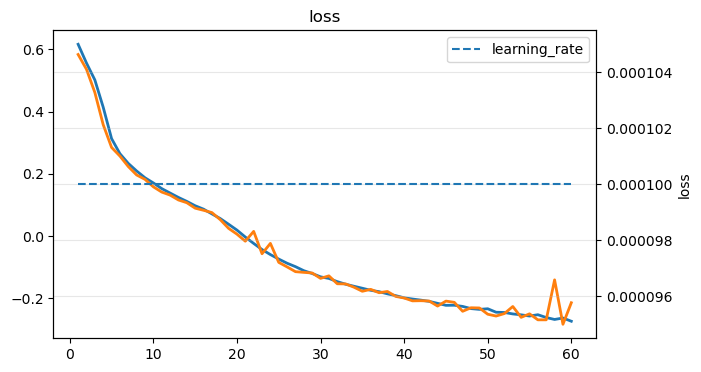

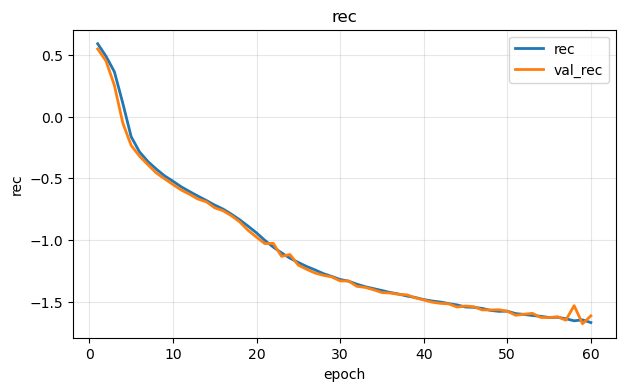

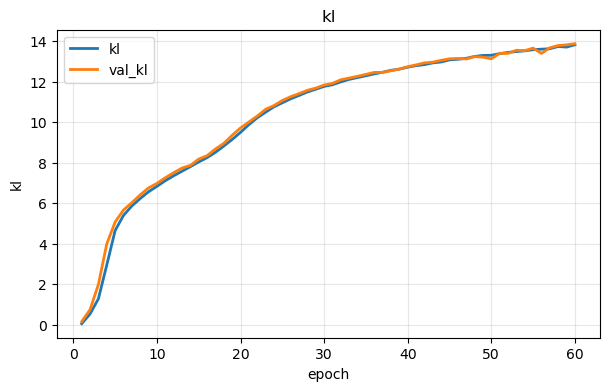

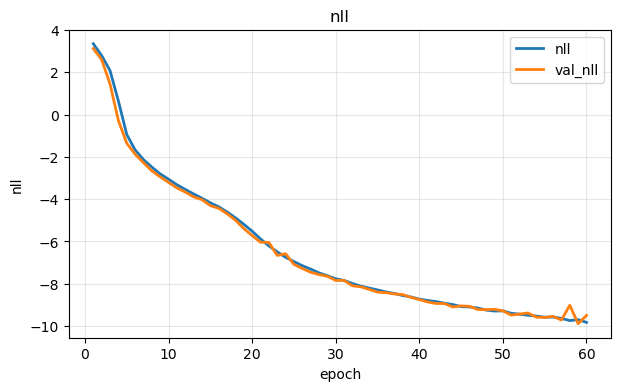

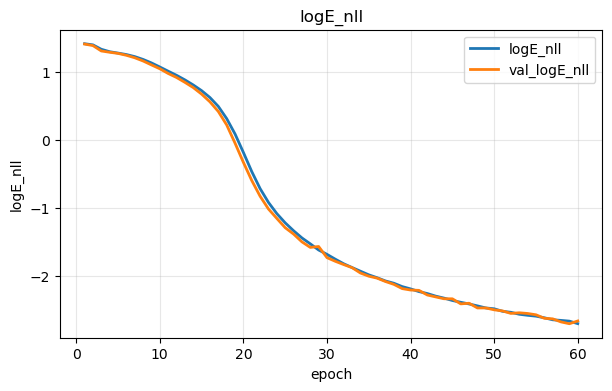

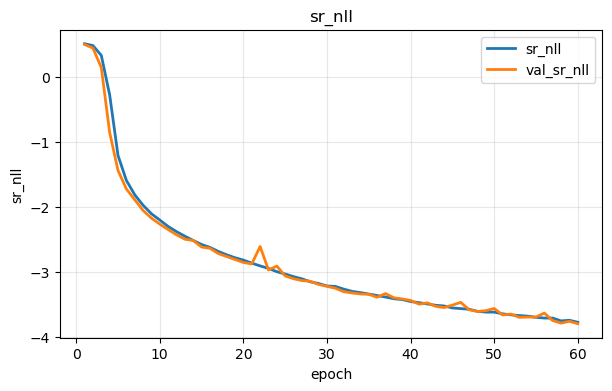

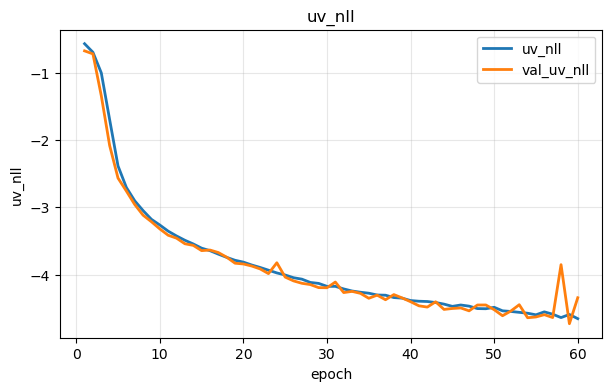

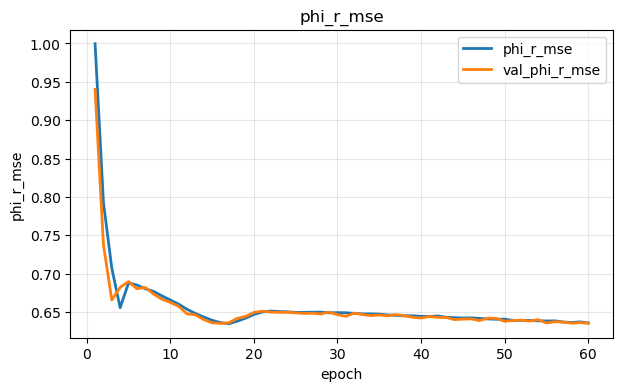

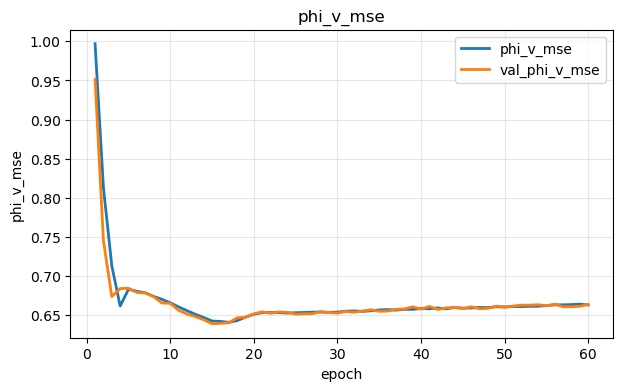

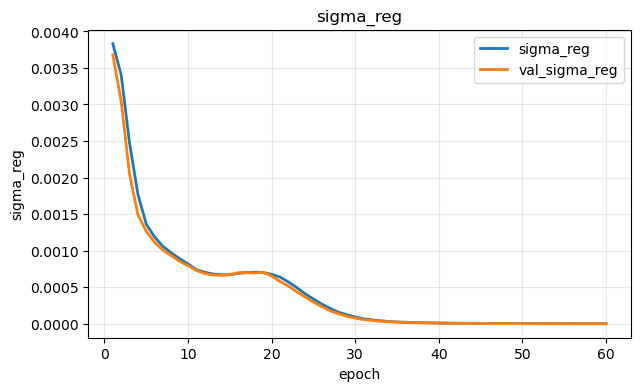

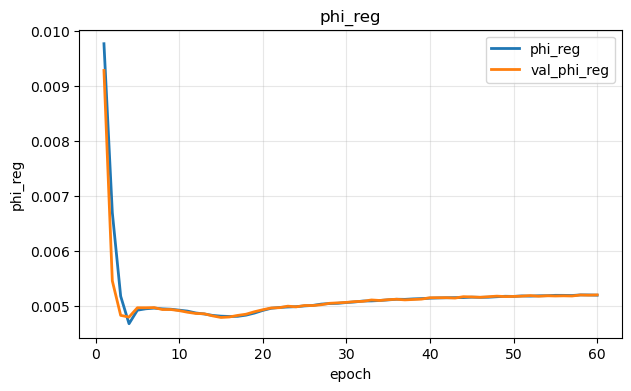

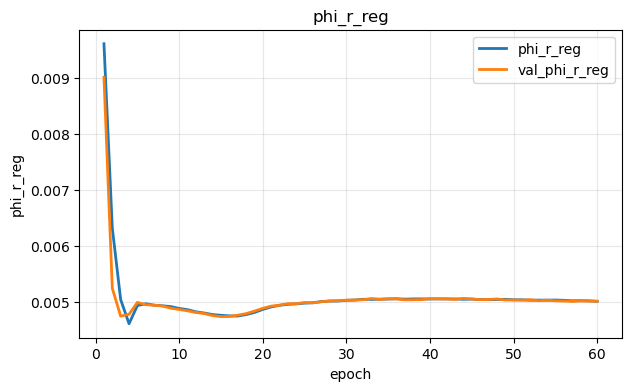

In [41]:
def plot_history(history, keys=None, show_available=True):
    h = history.history

    if show_available:
        print("History keys:", list(h.keys()))

    # Metriche default coerenti con CVAE_MixtureEnergy
    if keys is None:
        keys = [
            "loss",
            "rec",
            "kl",
            "nll",
            "logE_nll",
            "sr_nll",
            "uv_nll",
            "phi_r_mse",
            "phi_v_mse",
            "sigma_reg",
            "phi_reg",
            "phi_r_reg",
        ]

    # numero epoche
    n_ep = len(h["loss"]) if "loss" in h else len(next(iter(h.values())))
    epochs = np.arange(1, n_ep + 1)

    has_lr = ("learning_rate" in h)

    for k in keys:
        if k not in h:
            print("Missing key:", k)
            continue

        plt.figure(figsize=(7, 4))
        plt.plot(epochs, h[k], label=k, linewidth=2)

        val_k = "val_" + k
        if val_k in h:
            plt.plot(epochs, h[val_k], label=val_k, linewidth=2)

        # learning rate solo sul grafico della loss
        if k == "loss" and has_lr:
            ax1 = plt.gca()
            ax2 = ax1.twinx()
            ax2.plot(epochs, h["learning_rate"], linestyle="--", label="learning_rate")
            ax2.set_ylabel("learning_rate")
            ax2.legend(loc="upper right")

        plt.xlabel("epoch")
        plt.ylabel(k)
        plt.title(k)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# uso standard
plot_history(history)

#### Nuovo Modello con heads riformulate per energia e direzioni
Log(E) viene binnato ora per poter riconoscere e ricostruire le singole righe spettrali.

u_v viene ora costruita con una beta head: $x_v = \frac{u_v +1}{2}$ direttamente all'interno del modello.

In [46]:
# ==========================================================
# Binning di logE (in spazio scalato)
# ==========================================================

n_logE_bins = 512   # prova 256 / 512 / 1024

logE_train_scaled = X_train_s[:, 0].astype(np.float32)

logE_bin_edges = np.linspace(
    logE_train_scaled.min(),
    logE_train_scaled.max(),
    n_logE_bins + 1,
    dtype=np.float32
)

print("n_logE_bins:", n_logE_bins)
print("logE scaled min/max:", logE_train_scaled.min(), logE_train_scaled.max())
print("bin width:", logE_bin_edges[1] - logE_bin_edges[0])

n_logE_bins: 512
logE scaled min/max: -12.290301 4.066412
bin width: 0.031947136


In [82]:
# ==========================================================
# CVAE_CatLogE_BetaUV
# ==========================================================
#
# Conditional Variational Autoencoder con heads separate per
# modellare in modo più adatto:
#   - logE con righe strette  -> categorical discretized head
#   - s_r                     -> Gaussian head
#   - u_v in [-1,1]           -> Beta head su x_v=(u_v+1)/2 in (0,1)
#   - (cphi_r, sphi_r)        -> head 2D con regolarizzazione su cerchio
#   - (cphi_v, sphi_v)        -> head 2D con regolarizzazione su cerchio
#
# INPUT / OUTPUT FEATURES
#   y = [logE_s, s_r_s, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
#
# dove:
#   - logE_s e s_r_s sono le versioni scalate usate nel training
#   - cphi_*, sphi_* restano non scalate
#   - u_v = cos(theta_v) resta in [-1,1]
#
# ----------------------------------------------------------
# PARAMETRI PRINCIPALI
# ----------------------------------------------------------
#
# n_types
#   Numero di classi/particelle condizionanti.
#   Non è un iperparametro da ottimizzare.
#
# logE_bin_edges
#   Bordi dei bin per la head categorica di logE.
#   Più bin => migliore risoluzione delle righe strette,
#   ma training più difficile.
#   Valori tipici:
#     256   = stabile
#     512   = buon compromesso
#     1024  = più preciso ma più costoso
#
# latent_dim
#   Dimensione del collo di bottiglia latente.
#   Troppo piccolo: perde correlazioni.
#   Troppo grande: latente meno regolare.
#   Range utile:
#     8  = baseline buona
#     12 = più flessibile
#     16 = solo se necessario
#
# hidden
#   Struttura dei layer Dense del backbone encoder/decoder.
#   Più profondità/capacità aiuta correlazioni complesse, ma può
#   sbilanciare l'apprendimento tra le diverse heads.
#   Esempi utili:
#     (128,128,64)
#     (128,128,64,64)
#     (128,128,64,64,64)
#
# beta
#   Peso del termine KL nella loss VAE:
#       loss = rec + beta * KL + regularizers
#   Beta più bassa => migliore ricostruzione, meno regolarità.
#   Beta più alta  => latente più regolare, più smoothing.
#   Range utile per questo problema:
#     0.05 - 0.10  = più fedele
#     0.20         = più regolare
#
# type_weights
#   Pesi di classe per compensare lo sbilanciamento tra tipi di particella.
#   Utile quando classi rare (es. e-) sarebbero altrimenti ignorate.
#
# min_log_sigma, max_log_sigma
#   Range consentito alle sigma delle heads gaussiane.
#   Evitano sigma troppo piccole o troppo grandi.
#   Range tipico:
#     min_log_sigma = -6
#     max_log_sigma = 1 o 1.5
#
# lambda_sigma
#   Penalità sulle sigma troppo grandi.
#   Se le distribuzioni generate risultano troppo larghe, aumentare.
#   Range utile:
#     5e-4, 1e-3, 2e-3
#
# sigma_target
#   Soglia sopra cui log_sigma viene penalizzato.
#   Più negativo => sigma preferite più strette.
#   Range utile:
#     -2.0   baseline
#     -2.5   più stretto
#
# lambda_phi
#   Regolarizzazione della norma di (cphi_v, sphi_v):
#       (c^2 + s^2 - 1)^2
#   Aiuta la coerenza geometrica della direzione.
#   Range utile:
#     1e-2, 2e-2, 5e-2
#
# lambda_phi_r
#   Regolarizzazione analoga per (cphi_r, sphi_r).
#   Importante se x,y risultano peggiori di z.
#   Range utile:
#     1e-2, 2e-2, 5e-2
#
# w_logE
#   Peso della loss energia.
#   Se troppo alto, il modello può privilegiare logE a scapito della geometria.
#   Range utile:
#     0.8 - 1.2
#
# w_sr
#   Peso della loss su s_r.
#   Influenza soprattutto z.
#   Range utile:
#     1.0 baseline
#
# w_uv
#   Peso della loss su u_v.
#   Se u_v è ancora poco accurata, aumentare moderatamente.
#   Range utile:
#     1.0 - 2.0
#
# w_phi_r
#   Peso della loss su (cphi_r, sphi_r).
#   Influenza soprattutto x,y.
#   Se x,y sono peggiori di z, aumentare.
#   Range utile:
#     1.0 baseline
#     1.5 - 3.0 per migliorare x,y
#
# w_phi_v
#   Peso della loss su (cphi_v, sphi_v).
#   Influenza vx, vy.
#   Range utile:
#     1.0 baseline
#
#
# lambda_uv_shape
#   Regolarizzazione sulla shape della Beta head di u_v.
#   Serve a evitare che i parametri della Beta (soprattutto alpha)
#   diventino troppo piccoli, producendo spike artificiali vicino ai bordi,
#   in particolare vicino a u_v = -1.
#
#   Se lo spike a u_v=-1 è ancora troppo pronunciato, aumentare leggermente.
#   Range utile:
#     5e-4, 1e-3, 2e-3
#
# uv_alpha_min
#   Soglia minima "desiderata" per alpha nella Beta head di u_v.
#   Se alpha scende troppo, la distribuzione può divergere vicino a x_v=0
#   (cioè u_v ~ -1).
#
#   Più alto => meno spike al bordo, ma anche meno flessibilità della head.
#   Range utile:
#     0.8 baseline
#     1.0 più conservativo
#
# uv_beta_min
#   Soglia minima "desiderata" per beta nella Beta head di u_v.
#   In questo problema è meno critica di alpha, ma aiuta a evitare forme
#   troppo patologiche della Beta.
#
#   Range utile:
#     0.2 - 0.5
#
# ----------------------------------------------------------
# NOTA SULLA BETA HEAD DI u_v
# ----------------------------------------------------------
#
# u_v viene modellata tramite:
#     x_v = (u_v + 1)/2  in (0,1)
#
# e poi con una Beta(alpha, beta).
#
# Questa scelta è molto più adatta di una Gaussiana diretta su u_v, perché:
#   - il supporto è corretto
#   - la distribuzione può essere fortemente asimmetrica
#   - si adatta bene a dati accumulati vicino ai bordi
#
# Tuttavia, se alpha diventa troppo piccola, può comparire uno spike artificiale
# vicino a u_v = -1. La regolarizzazione lambda_uv_shape serve proprio a ridurre
# questo effetto senza perdere il vantaggio della Beta head.
#
#
# ----------------------------------------------------------
# TUNING PRATICO CONSIGLIATO
# ----------------------------------------------------------
#
# Per migliorare x,y:
#   - aumentare w_phi_r
#   - aumentare lambda_phi_r
#   - usare hidden meno compressi nell'ultimo layer
#   - aggiungere una xy-loss geometrica diretta
#
# Per migliorare u_v:
#   - aumentare w_uv
#   - usare Beta head (già implementata qui)
#   - eventualmente limitare i dati troppo vicini ai bordi
#   - in alternativa valutare una parametrizzazione s_v = atanh(u_v)
#
# Per migliorare logE:
#   - aumentare n_logE_bins
#   - usare più capacità nel backbone
#   - tenere beta non troppo alta
# ==========================================================

class CVAE_CatLogE_BetaUV(keras.Model):
    """
    Conditional VAE con heads separate.

    Input/output features:
      y = [logE_s, s_r_s, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
      cond = one-hot particle type

    Decoder heads:
      1) logE_s  -> categorical discretized head
      2) s_r_s   -> Gaussian head
      3) u_v     -> Beta head su x_v = (u_v + 1)/2 in (0,1)
      4) phi_r   -> 2D head for (cphi_r, sphi_r)
      5) phi_v   -> 2D head for (cphi_v, sphi_v)
    """

    def __init__(
        self,
        n_types,
        logE_bin_edges,
        latent_dim=8,
        hidden=(128, 128, 64),
        beta=0.1,
        type_weights=None,

        # Gaussian head for s_r
        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        # regularization
        lambda_sigma=1e-3,
        sigma_target=-2.0,
        lambda_phi=1e-2,
        lambda_phi_r=1e-2,

        # reconstruction weights
        w_logE=1.0,
        w_sr=1.0,
        w_uv=1.0,
        w_phi_r=1.0,
        w_phi_v=1.0,

        # geometric xy-loss from position head
        w_xy=0.0,
        sphere_R=100.0,
                
        # regularization on Beta shape for u_v
        lambda_uv_shape=1e-3,
        uv_alpha_min=0.8,
        uv_beta_min=0.3,
    ):
        super().__init__()

        self.n_types = n_types
        self.latent_dim = latent_dim
        self.beta = beta
        self.type_weights = type_weights

        self.min_log_sigma = min_log_sigma
        self.max_log_sigma = max_log_sigma

        self.lambda_sigma = lambda_sigma
        self.sigma_target = sigma_target
        self.lambda_phi = lambda_phi
        self.lambda_phi_r = lambda_phi_r

        self.w_logE = w_logE
        self.w_sr = w_sr
        self.w_uv = w_uv
        self.w_phi_r = w_phi_r
        self.w_phi_v = w_phi_v

        self.w_xy = w_xy
        self.sphere_R = sphere_R

        self.lambda_uv_shape = lambda_uv_shape
        self.uv_alpha_min = uv_alpha_min
        self.uv_beta_min = uv_beta_min

        # logE bins
        logE_bin_edges = tf.convert_to_tensor(logE_bin_edges, dtype=tf.float32)
        self.logE_bin_edges = logE_bin_edges                      # shape (B+1,)
        self.n_logE_bins = int(logE_bin_edges.shape[0] - 1)

        # bin centers for optional deterministic visualization
        self.logE_bin_centers = 0.5 * (logE_bin_edges[:-1] + logE_bin_edges[1:])

        # ======================================================
        # Encoder
        # ======================================================
        enc_in = layers.Input(shape=(7 + n_types,))
        x = enc_in
        for h in hidden:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.01)(x)
        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_logvar = layers.Dense(latent_dim, name="z_logvar")(x)
        self.encoder = keras.Model(enc_in, [z_mean, z_logvar], name="encoder")

        # ======================================================
        # Decoder backbone
        # ======================================================
        dec_in = layers.Input(shape=(latent_dim + n_types,))
        x = dec_in
        for h in hidden[::-1]:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.01)(x)
        self.decoder_backbone = keras.Model(dec_in, x, name="decoder_backbone")

        # ======================================================
        # Decoder heads
        # ======================================================

        # logE categorical head
        self.logE_logits_head = layers.Dense(self.n_logE_bins, name="logE_logits")

        # s_r Gaussian head
        self.sr_mu_head = layers.Dense(1, name="sr_mu")
        self.sr_logsigma_head = layers.Dense(1, name="sr_logsigma")

        # u_v Beta head via x_v=(u_v+1)/2
        self.uv_alpha_head = layers.Dense(1, name="uv_alpha_raw")
        self.uv_beta_head  = layers.Dense(1, name="uv_beta_raw")

        # phi_r head
        # self.phi_r_head = layers.Dense(2, name="phi_r_head")
        self.phi_r_head = keras.Sequential([
            layers.Dense(32),
            layers.LeakyReLU(0.01),
            layers.Dense(2)
        ], name="phi_r_head") #Modifica per rendere phi_r più flessibile

        # phi_v head
        self.phi_v_head = layers.Dense(2, name="phi_v_head")

        # ======================================================
        # Metrics
        # ======================================================
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec")
        self.kl_tracker = keras.metrics.Mean(name="kl")
        self.nll_tracker = keras.metrics.Mean(name="nll")
        self.sigma_reg_tracker = keras.metrics.Mean(name="sigma_reg")
        self.phi_reg_tracker = keras.metrics.Mean(name="phi_reg")
        self.phi_r_reg_tracker = keras.metrics.Mean(name="phi_r_reg")

        self.logE_ce_tracker = keras.metrics.Mean(name="logE_ce")
        self.sr_nll_tracker = keras.metrics.Mean(name="sr_nll")
        self.uv_beta_nll_tracker = keras.metrics.Mean(name="uv_beta_nll")
        self.phi_r_mse_tracker = keras.metrics.Mean(name="phi_r_mse")
        self.phi_v_mse_tracker = keras.metrics.Mean(name="phi_v_mse")
        self.xy_mse_tracker = keras.metrics.Mean(name="xy_mse")
        self.uv_shape_reg_tracker = keras.metrics.Mean(name="uv_shape_reg")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.rec_tracker,
            self.kl_tracker,
            self.nll_tracker,
            self.sigma_reg_tracker,
            self.phi_reg_tracker,
            self.phi_r_reg_tracker,
            self.logE_ce_tracker,
            self.sr_nll_tracker,
            self.uv_beta_nll_tracker,
            self.phi_r_mse_tracker,
            self.phi_v_mse_tracker,
            self.xy_mse_tracker,
            self.uv_shape_reg_tracker,
        ]

    # ==========================================================
    # Utilities
    # ==========================================================
    def sample_z(self, z_mean, z_logvar):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * eps

    def _decode_params(self, z, cond, training=False):
        x = self.decoder_backbone(tf.concat([z, cond], axis=1), training=training)

        logE_logits = self.logE_logits_head(x)

        sr_mu = self.sr_mu_head(x)
        sr_logsigma = tf.clip_by_value(
            self.sr_logsigma_head(x),
            self.min_log_sigma,
            self.max_log_sigma
        )

        # Beta params via softplus + floor
        uv_alpha = tf.nn.softplus(self.uv_alpha_head(x)) + 1e-3
        uv_beta  = tf.nn.softplus(self.uv_beta_head(x))  + 1e-3

        phi_r = self.phi_r_head(x)
        phi_v = self.phi_v_head(x)

        return {
            "logE_logits": logE_logits,
            "sr_mu": sr_mu,
            "sr_logsigma": sr_logsigma,
            "uv_alpha": uv_alpha,
            "uv_beta": uv_beta,
            "phi_r": phi_r,
            "phi_v": phi_v,
        }

    def _gaussian_nll(self, x, mu, log_sigma):
        sigma2 = tf.exp(2.0 * log_sigma)
        return 0.5 * ((tf.square(x - mu) / sigma2) + 2.0 * log_sigma)

    def _logE_to_bin_index(self, logE_scaled):
        """
        logE_scaled: (B,1) or (B,)
        returns int indices in [0, n_bins-1]
        """
        x = tf.reshape(logE_scaled, [-1])
        # internal boundaries exclude first and last edge
        boundaries = self.logE_bin_edges[1:-1]
        idx = tf.searchsorted(boundaries, x, side="right")
        idx = tf.cast(idx, tf.int32)
        return idx

    def _categorical_logE_nll(self, logE_scaled, logits):
        """
        Sparse CE on discretized logE.
        """
        idx = self._logE_to_bin_index(logE_scaled)
        ce = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=idx,
            logits=logits
        )
        return ce

    def _beta_nll_uv(self, u_v_true, alpha, beta):
        """
        Model u_v via x_v=(u_v+1)/2 in (0,1), with Beta(alpha,beta)
        """
        x_v = 0.5 * (u_v_true + 1.0)
        x_v = tf.clip_by_value(x_v, 1e-6, 1.0 - 1e-6)

        alpha = tf.squeeze(alpha, axis=1)
        beta = tf.squeeze(beta, axis=1)
        x_v = tf.squeeze(x_v, axis=1)

        log_prob = (
            (alpha - 1.0) * tf.math.log(x_v) +
            (beta  - 1.0) * tf.math.log(1.0 - x_v) -
            (tf.math.lgamma(alpha) + tf.math.lgamma(beta) - tf.math.lgamma(alpha + beta))
        )
        return -log_prob

    def _sigma_regularizer(self, params):
        if self.lambda_sigma <= 0:
            return tf.constant(0.0, dtype=tf.float32)

        logsigmas = params["sr_logsigma"]
        return self.lambda_sigma * tf.reduce_mean(
            tf.square(tf.nn.relu(logsigmas - self.sigma_target))
        )

    def _phi_regularizers(self, params):
        phi_r_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi_r > 0:
            c = params["phi_r"][:, 0]
            s = params["phi_r"][:, 1]
            r2 = c*c + s*s
            phi_r_reg = self.lambda_phi_r * tf.reduce_mean(tf.square(r2 - 1.0))

        phi_v_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi > 0:
            c = params["phi_v"][:, 0]
            s = params["phi_v"][:, 1]
            r2 = c*c + s*s
            phi_v_reg = self.lambda_phi * tf.reduce_mean(tf.square(r2 - 1.0))

        return phi_v_reg, phi_r_reg
    
    def _xy_from_sr_phi(self, s_r, phi_pair):
        """
        s_r: (B,1)
        phi_pair: (B,2) = [cphi, sphi]
        returns:
          x, y as tensors of shape (B,)
        """
        u_r = tf.tanh(tf.squeeze(s_r, axis=1))  # (B,)

        c = phi_pair[:, 0]
        s = phi_pair[:, 1]

        # rinormalizzo la coppia angolare
        norm = tf.sqrt(c*c + s*s + 1e-12)
        c = c / norm
        s = s / norm

        sin_theta = tf.sqrt(tf.maximum(0.0, 1.0 - u_r*u_r))

        x = self.sphere_R * sin_theta * c
        y = self.sphere_R * sin_theta * s
        return x, y
    
    def _uv_shape_regularizer(self, params):
        """
        Regolarizzazione sulla Beta head di u_v.

        Obiettivo:
        - evitare alpha troppo piccole -> spike vicino a x_v = 0 -> u_v ~ -1
        - opzionalmente evitare beta troppo piccole

        params["uv_alpha"], params["uv_beta"] hanno shape (B,1)
        """
        if self.lambda_uv_shape <= 0:
            return tf.constant(0.0, dtype=tf.float32)

        alpha = tf.squeeze(params["uv_alpha"], axis=1)  # (B,)
        beta  = tf.squeeze(params["uv_beta"], axis=1)   # (B,)

        # penalizza alpha sotto una soglia
        reg_alpha = tf.reduce_mean(tf.square(tf.nn.relu(self.uv_alpha_min - alpha)))

        # penalizza beta sotto una soglia, ma in modo più debole
        reg_beta = tf.reduce_mean(tf.square(tf.nn.relu(self.uv_beta_min - beta)))

        return self.lambda_uv_shape * (reg_alpha + 0.2 * reg_beta)

    def _reconstruction_terms(self, y_true, params):
        """
        y_true = [logE_s, s_r_s, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
        """
        logE_true = y_true[:, 0:1]
        sr_true   = y_true[:, 1:2]
        phi_r_true = y_true[:, 2:4]
        uv_true   = y_true[:, 4:5]
        phi_v_true = y_true[:, 5:7]

        # 1) logE categorical CE
        logE_ce = self._categorical_logE_nll(logE_true, params["logE_logits"])  # (B,)

        # 2) s_r Gaussian NLL
        sr_nll = tf.squeeze(
            self._gaussian_nll(sr_true, params["sr_mu"], params["sr_logsigma"]),
            axis=1
        )  # (B,)

        # 3) u_v Beta NLL
        uv_beta_nll = self._beta_nll_uv(uv_true, params["uv_alpha"], params["uv_beta"])  # (B,)

        # 4) angular heads
        phi_r_mse = tf.reduce_sum(tf.square(phi_r_true - params["phi_r"]), axis=1)  # (B,)
        phi_v_mse = tf.reduce_sum(tf.square(phi_v_true - params["phi_v"]), axis=1)  # (B,)

        # 5) geometric xy-loss derived from sr + phi_r
        x_true, y_true_xy = self._xy_from_sr_phi(sr_true, phi_r_true)
        x_pred, y_pred_xy = self._xy_from_sr_phi(params["sr_mu"], params["phi_r"])

        xy_mse = tf.square(x_true - x_pred) + tf.square(y_true_xy - y_pred_xy)  # (B,)

        rec_per = (
            self.w_logE  * logE_ce +
            self.w_sr    * sr_nll +
            self.w_uv    * uv_beta_nll +
            self.w_phi_r * phi_r_mse +
            self.w_phi_v * phi_v_mse +
            self.w_xy    * xy_mse
        )

        pieces = {
            "logE_ce": logE_ce,
            "sr_nll": sr_nll,
            "uv_beta_nll": uv_beta_nll,
            "phi_r_mse": phi_r_mse,
            "phi_v_mse": phi_v_mse,
            "xy_mse": xy_mse,
        }
        return rec_per, pieces
    

    # ==========================================================
    # Keras train/test
    # ==========================================================
    def train_step(self, data):
        (y, cond), _ = data
        x_in = tf.concat([y, cond], axis=1)

        with tf.GradientTape() as tape:
            z_mean, z_logvar = self.encoder(x_in, training=True)
            z = self.sample_z(z_mean, z_logvar)

            params = self._decode_params(z, cond, training=True)

            rec_per, pieces = self._reconstruction_terms(y, params)

            if self.type_weights is not None:
                t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
                w = tf.gather(self.type_weights, t_idx)
                rec_per_weighted = rec_per * w
            else:
                rec_per_weighted = rec_per

            rec = tf.reduce_mean(rec_per_weighted)
            nll = tf.reduce_mean(rec_per)

            kl_per = -0.5 * tf.reduce_sum(
                1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
                axis=1
            )
            kl = tf.reduce_mean(kl_per)

            sigma_reg = self._sigma_regularizer(params)
            phi_reg, phi_r_reg = self._phi_regularizers(params)
            uv_shape_reg = self._uv_shape_regularizer(params)

            loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg + uv_shape_reg

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)
        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.logE_ce_tracker.update_state(tf.reduce_mean(pieces["logE_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.uv_beta_nll_tracker.update_state(tf.reduce_mean(pieces["uv_beta_nll"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))
        self.uv_shape_reg_tracker.update_state(uv_shape_reg)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (y, cond), _ = data
        x_in = tf.concat([y, cond], axis=1)

        z_mean, z_logvar = self.encoder(x_in, training=False)
        z = self.sample_z(z_mean, z_logvar)

        params = self._decode_params(z, cond, training=False)

        rec_per, pieces = self._reconstruction_terms(y, params)

        if self.type_weights is not None:
            t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
            w = tf.gather(self.type_weights, t_idx)
            rec_per_weighted = rec_per * w
        else:
            rec_per_weighted = rec_per

        rec = tf.reduce_mean(rec_per_weighted)
        nll = tf.reduce_mean(rec_per)

        kl_per = -0.5 * tf.reduce_sum(
            1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
            axis=1
        )
        kl = tf.reduce_mean(kl_per)

        sigma_reg = self._sigma_regularizer(params)
        phi_reg, phi_r_reg = self._phi_regularizers(params)
        uv_shape_reg = self._uv_shape_regularizer(params)

        loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg + uv_shape_reg

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)
        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.logE_ce_tracker.update_state(tf.reduce_mean(pieces["logE_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.uv_beta_nll_tracker.update_state(tf.reduce_mean(pieces["uv_beta_nll"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))
        self.uv_shape_reg_tracker.update_state(uv_shape_reg)

        return {m.name: m.result() for m in self.metrics}

    # ==========================================================
    # Sampling / generation
    # ==========================================================
    @tf.function
    def decode(self, z, cond):
        return self._decode_params(z, cond, training=False)

    def _sample_logE_from_logits(self, logits):
        """
        Sample logE_s from categorical bins with uniform jitter inside the bin.
        logits: (B, n_bins)
        returns: (B,1)
        """
        bin_idx = tf.random.categorical(logits, num_samples=1)  # (B,1)
        bin_idx = tf.squeeze(bin_idx, axis=1)                   # (B,)

        edges_left = tf.gather(self.logE_bin_edges[:-1], bin_idx)
        edges_right = tf.gather(self.logE_bin_edges[1:], bin_idx)

        u = tf.random.uniform(tf.shape(edges_left), 0.0, 1.0)
        sample = edges_left + u * (edges_right - edges_left)

        return tf.expand_dims(sample, axis=1)

    def _sample_beta_uv(self, alpha, beta):
        """
        Sample x_v in (0,1) via Gamma trick, then map to u_v in (-1,1)
        """
        alpha = tf.squeeze(alpha, axis=1)
        beta = tf.squeeze(beta, axis=1)

        ga = tf.random.gamma(shape=[], alpha=alpha)
        gb = tf.random.gamma(shape=[], alpha=beta)
        x_v = ga / (ga + gb + 1e-12)

        u_v = 2.0 * x_v - 1.0
        u_v = tf.clip_by_value(u_v, -1.0 + 1e-6, 1.0 - 1e-6)
        return tf.expand_dims(u_v, axis=1)

    def generate_y(self, cond, n_samples):
        """
        Restituisce y = [logE_s, s_r_s, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
        nel feature space del training.
        """
        z = tf.random.normal((n_samples, self.latent_dim))
        params = self.decode(z, cond)

        # logE categorical
        logE_s = self._sample_logE_from_logits(params["logE_logits"])

        # s_r Gaussian
        sr_eps = tf.random.normal(tf.shape(params["sr_mu"]))
        s_r_s = params["sr_mu"] + tf.exp(params["sr_logsigma"]) * sr_eps

        # u_v Beta
        u_v = self._sample_beta_uv(params["uv_alpha"], params["uv_beta"])

        # angular heads
        phi_r = params["phi_r"]
        phi_v = params["phi_v"]

        y = tf.concat([logE_s, s_r_s, phi_r, u_v, phi_v], axis=1)
        return y

In [93]:
# Instanzia il nuovo modello e fai il fit
n_types = int(cond_train.shape[1])

model = CVAE_CatLogE_BetaUV(
    n_types=n_types,
    logE_bin_edges=logE_bin_edges, # (512 bins tra min e max di logE scalato)
    latent_dim=12,
    hidden=(128, 128, 64, 64),
    beta=0.1,
    type_weights=type_weights,

    min_log_sigma=-6.0,
    max_log_sigma=1.5,

    lambda_sigma=1e-3,
    sigma_target=-2.0,
    lambda_phi=2e-2,
    lambda_phi_r=2e-2, # Aumentato lambda_phi_r per cercare di migliorare la ricostruzione degli angoli di emissione da 1e-2 a 4e-2

    w_logE=1.0,
    w_sr=1.0,
    w_uv=0.8, # Ridotto leggermente w_uv per bilanciare meglio con le altre loss e evitare di privilegiare troppo u_v
    w_phi_r=1.5, #Modificato da 1.0 a 1.5 per cercare di migliorare la ricostruzione degli angoli di emissione
    w_phi_v=1.0,
    w_xy = 0.01, # Aggiunta di una piccola perdita geometrica xy per migliorare la coerenza spaziale

    lambda_uv_shape=2e-3, # Regolarizzazione sulla forma della distribuzione Beta per u_v
    uv_alpha_min=1.0, # Soglia minima più conservativa per alpha nella Beta head di u_v rispetto a 0.8, per ridurre ulteriormente lo spike vicino a u_v = -1
    uv_beta_min=0.3,
)

model.compile(
    optimizer=keras.optimizers.Adam(5e-4)
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
321/321 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - kl: 6.4332 - logE_ce: 5.3221 - loss: 5.2844 - nll: 26.8932 - phi_r_mse: 0.2789 - phi_r_reg: 0.0080 - phi_reg: 0.0168 - phi_v_mse: 0.9521 - rec: 4.6106 - sigma_reg: 0.0055 - sr_nll: 0.9538 - uv_beta_nll: -0.2396 - uv_shape_reg: 1.5474e-04 - xy_mse: 1943.8468 - val_kl: 7.2866 - val_logE_ce: 4.9169 - val_loss: 2.1781 - val_nll: 8.2822 - val_phi_r_mse: 0.0610 - val_phi_r_reg: 0.0028 - val_phi_reg: 0.0157 - val_phi_v_mse: 0.9162 - val_rec: 1.4266 - val_sigma_reg: 0.0043 - val_sr_nll: 0.4878 - val_uv_beta_nll: -0.4490 - val_uv_shape_reg: 3.3205e-07 - val_xy_mse: 222.9059 - learning_rate: 5.0000e-04
Epoch 2/60
321/321 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - kl: 6.5896 - logE_ce: 4.8661 - loss: 1.9773 - nll: 7.5381 - phi_r_mse: 0.0499 - phi_r_reg: 0.0021 - phi_reg: 0.0149 - phi_v_mse: 0.8995 - rec: 1.2975 - sigma_reg: 0.0038 - sr_nll: 0.3240 - uv_beta_nll: -0.5100 - uv_shape_reg: 1.2637e-07 - xy_mse: 178.1644 - val_kl: 6.1186 - val_logE_ce: 4


Available history keys:
['kl', 'logE_ce', 'loss', 'nll', 'phi_r_mse', 'phi_r_reg', 'phi_reg', 'phi_v_mse', 'rec', 'sigma_reg', 'sr_nll', 'uv_beta_nll', 'uv_shape_reg', 'val_kl', 'val_logE_ce', 'val_loss', 'val_nll', 'val_phi_r_mse', 'val_phi_r_reg', 'val_phi_reg', 'val_phi_v_mse', 'val_rec', 'val_sigma_reg', 'val_sr_nll', 'val_uv_beta_nll', 'val_uv_shape_reg', 'val_xy_mse', 'xy_mse', 'learning_rate']


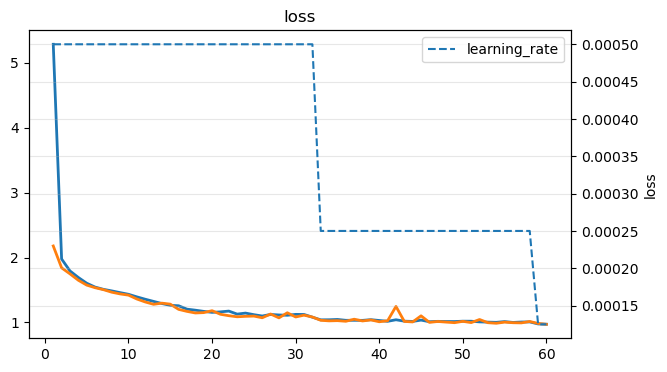

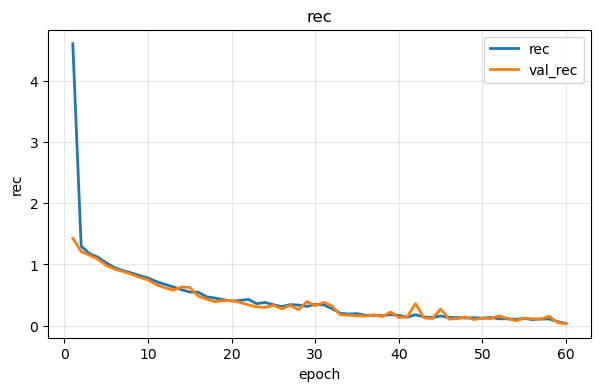

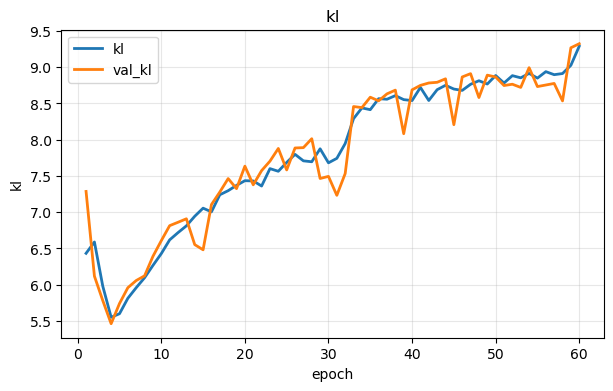

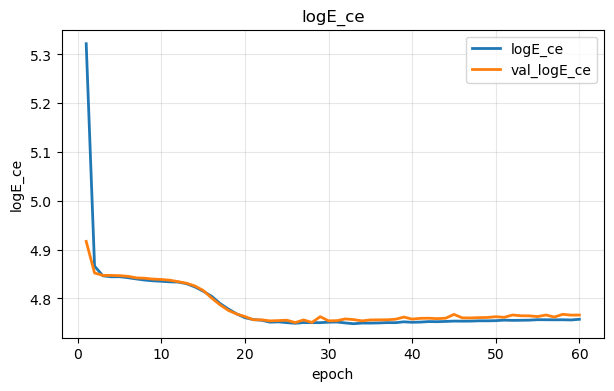

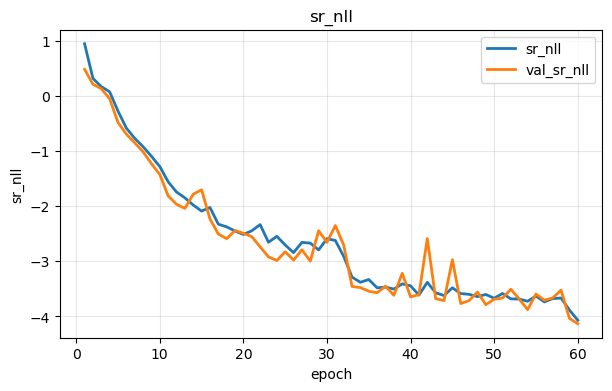

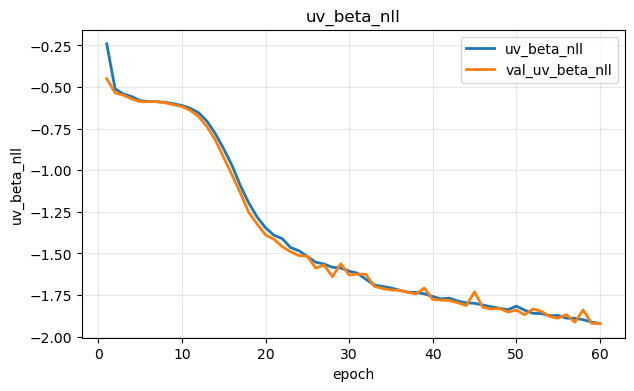

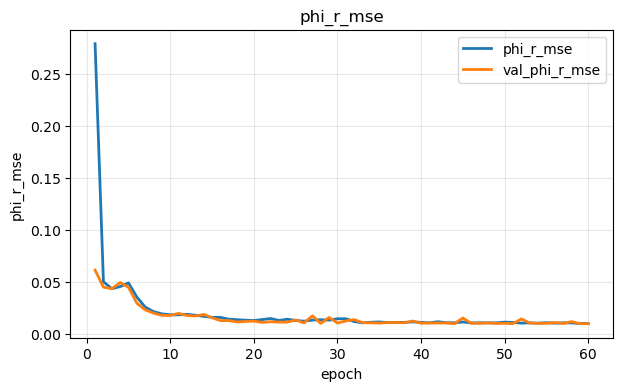

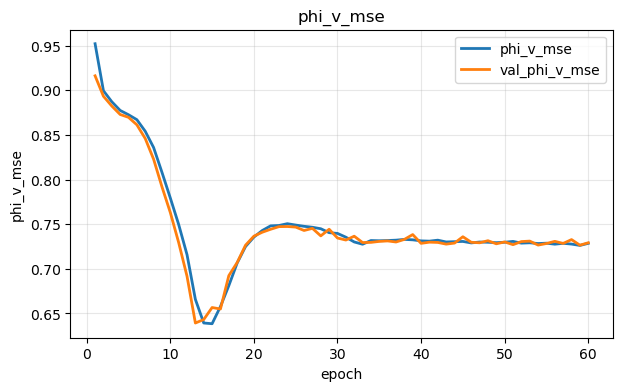

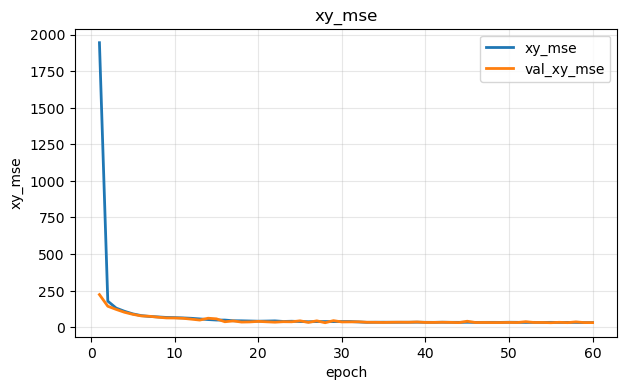

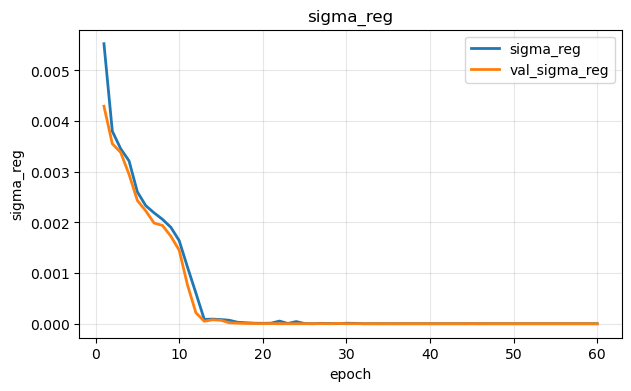

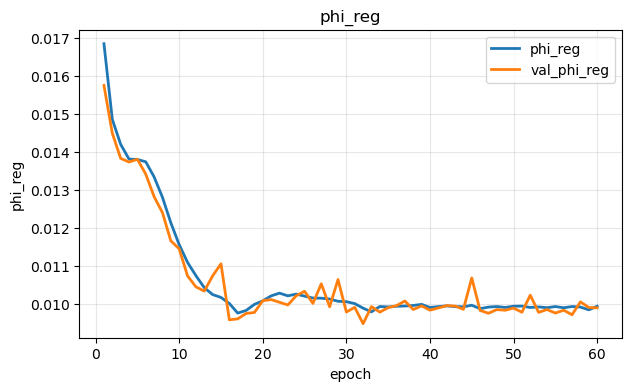

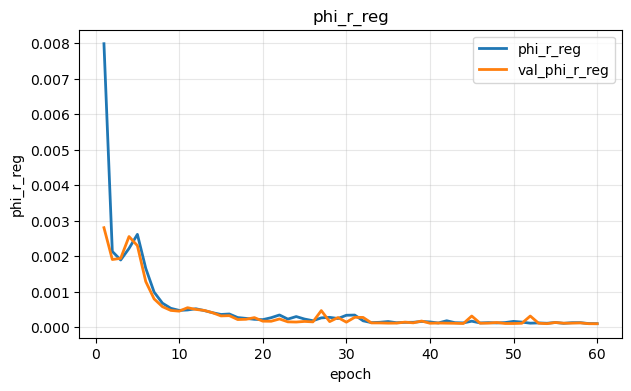

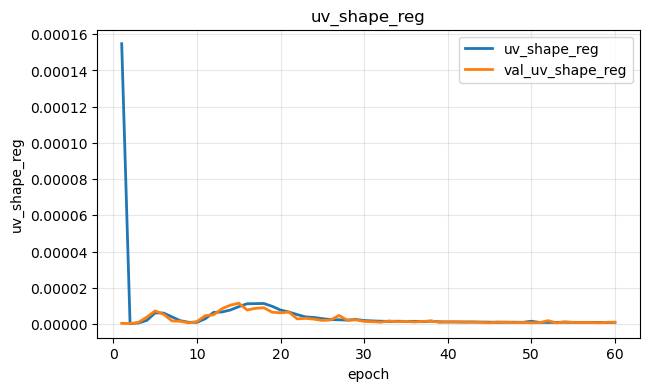

In [94]:
def plot_history(history, keys=None, show_available=True):
    h = history.history

    if show_available:
        print("\nAvailable history keys:")
        print(list(h.keys()))

    # ==========================================================
    # Metriche default per CVAE_CatLogE_BetaUV aggiornato
    # ==========================================================
    if keys is None:
        keys = [
            "loss",
            "rec",
            "kl",

            # energia
            "logE_ce",

            # posizione polare
            "sr_nll",

            # direzione polare
            "uv_beta_nll",

            # direzioni azimutali
            "phi_r_mse",
            "phi_v_mse",

            # nuova xy loss
            "xy_mse",

            # regularizers
            "sigma_reg",
            "phi_reg",
            "phi_r_reg",
            "uv_shape_reg",
        ]

    # ==========================================================
    # numero epoche
    # ==========================================================
    if "loss" in h:
        n_ep = len(h["loss"])
    else:
        n_ep = len(next(iter(h.values())))

    epochs = np.arange(1, n_ep + 1)

    has_lr = ("learning_rate" in h)

    # ==========================================================
    # plotting
    # ==========================================================
    for k in keys:

        if k not in h:
            print("Metric not present:", k)
            continue

        plt.figure(figsize=(7,4))

        plt.plot(
            epochs,
            h[k],
            label=k,
            linewidth=2
        )

        val_k = "val_" + k

        if val_k in h:
            plt.plot(
                epochs,
                h[val_k],
                label=val_k,
                linewidth=2
            )

        # learning rate solo sul grafico della loss
        if k == "loss" and has_lr:
            ax1 = plt.gca()
            ax2 = ax1.twinx()

            ax2.plot(
                epochs,
                h["learning_rate"],
                linestyle="--",
                label="learning_rate"
            )

            ax2.set_ylabel("learning_rate")
            ax2.legend(loc="upper right")

        plt.xlabel("epoch")
        plt.ylabel(k)
        plt.title(k)

        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.show()


# ==========================================================
# uso standard
# ==========================================================
plot_history(history)

### Generazione dei campioni
Qui facciamo:
	
	1.	generazione di un campione “misto” (tipi campionati con type_probs)
	
	2.	ricostruzione in variabili fisiche (E, x,y,z, vx,vy,vz)
	
	3.	checks vincoli + test distribuzioni

#### Per il primo modello usare questa v

In [42]:
def sample_types(n_samples, type_probs, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.choice(len(type_probs), size=n_samples, p=type_probs)
    return idx.astype(np.int32)

def one_hot_from_idx(idx, n_types):
    return tf.one_hot(idx, depth=n_types, dtype=tf.float32)

# ==========================================================
# Generazione tipi di particella
# ==========================================================
NGEN = 1_000_000   # per confronti più rapidi puoi anche usare len(X_test)

gen_type_idx = sample_types(NGEN, type_probs)
gen_cond = one_hot_from_idx(gen_type_idx, n_types)

unique, counts = np.unique(gen_type_idx, return_counts=True)

print("\nGenerated particle counts:")
for u, c in zip(unique, counts):
    print(idx_to_type[u], c)

# ==========================================================
# Generazione feature nello spazio usato dal training
# y_gen_scaled = [logE_s, s_r_s, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
# ==========================================================
y_gen_scaled = model.generate_y(gen_cond, NGEN).numpy()

# ==========================================================
# Unscale delle feature scalate
# - col 0 = logE
# - col 1 = s_r
# ==========================================================
y_gen = y_gen_scaled.copy()

y_gen[:, 0] = y_gen_scaled[:, 0] * logE_std + logE_mean   # logE fisico
y_gen[:, 1] = y_gen_scaled[:, 1] * s_r_std  + s_r_mean    # s_r fisico

# ==========================================================
# Energia fisica
# ==========================================================
E_gen = 10.0 ** y_gen[:, 0]

# ==========================================================
# Check rapidi
# ==========================================================
print("\n--- Generated feature ranges ---")
print("logE_gen min/max:", y_gen[:, 0].min(), y_gen[:, 0].max())
print("s_r_gen  min/max:", y_gen[:, 1].min(), y_gen[:, 1].max())
print("u_v_gen  min/max:", y_gen[:, 4].min(), y_gen[:, 4].max())
print("E_gen    min/max:", E_gen.min(), E_gen.max())


Generated particle counts:
gamma 992754
e- 7246

--- Generated feature ranges ---
logE_gen min/max: -1.6258092 0.18362743
s_r_gen  min/max: -3.4598625 4.5392756
u_v_gen  min/max: -0.999999 0.80246955
E_gen    min/max: 0.023669593 1.5262562


In [43]:
# Ricostruzione posizione e direzione da feature generate
C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-6

def renorm_cos_sin(c, s, eps=1e-12):
    r = np.sqrt(c*c + s*s) + eps
    return c/r, s/r

def u_from_sr(s):
    # u_r in (-1,1)
    return np.tanh(s)

# ==========================================================
# Estrai feature generate
# y = [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
# ==========================================================

s_r_gen = y_gen[:, 1]
u_r_gen = u_from_sr(s_r_gen)

# ==========================================================
# POSIZIONE su sfera
# ==========================================================

cpr_gen, spr_gen = renorm_cos_sin(y_gen[:, 2], y_gen[:, 3])
sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen*u_r_gen))

x_gen = C[0] + R * sin_tr_gen * cpr_gen
ypos_gen = C[1] + R * sin_tr_gen * spr_gen
z_gen = C[2] + R * u_r_gen

# ==========================================================
# DIREZIONE: (u_v, phi_v) -> (vx, vy, vz)
# ==========================================================

u_v_gen = y_gen[:, 4].copy()
u_v_gen = np.clip(u_v_gen, -1.0 + eps, 1.0 - eps)

cpv_gen, spv_gen = renorm_cos_sin(y_gen[:, 5], y_gen[:, 6])
sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen*u_v_gen))

vx_gen = sin_tv_gen * cpv_gen
vy_gen = sin_tv_gen * spv_gen
vz_gen = u_v_gen

# ==========================================================
# Sanity check vincoli
# ==========================================================

rvec_gen = np.vstack([x_gen, ypos_gen, z_gen]).T - C[None, :]
r_gen = np.linalg.norm(rvec_gen, axis=1)

vnorm_gen_check = np.sqrt(vx_gen*vx_gen + vy_gen*vy_gen + vz_gen*vz_gen)

phi_r_norm = np.sqrt(cpr_gen*cpr_gen + spr_gen*spr_gen)
phi_v_norm = np.sqrt(cpv_gen*cpv_gen + spv_gen*spv_gen)

print("--- VINCOLI ---")
print("r_gen: mean", r_gen.mean(), "std", r_gen.std(), "min", r_gen.min(), "max", r_gen.max())
print("mean |r-R| =", np.mean(np.abs(r_gen - R)))

print("||v||: mean", vnorm_gen_check.mean(), "std", vnorm_gen_check.std(),
      "min", vnorm_gen_check.min(), "max", vnorm_gen_check.max())
print("mean ||v||-1| =", np.mean(np.abs(vnorm_gen_check - 1.0)))

print("phi_r norm: mean", phi_r_norm.mean(), "std", phi_r_norm.std(),
      "min", phi_r_norm.min(), "max", phi_r_norm.max())
print("phi_v norm: mean", phi_v_norm.mean(), "std", phi_v_norm.std(),
      "min", phi_v_norm.min(), "max", phi_v_norm.max())

print("E_gen: min", E_gen.min(), "max", E_gen.max())
print("u_r_gen min/max:", u_r_gen.min(), u_r_gen.max())
print("u_v_gen min/max:", u_v_gen.min(), u_v_gen.max())
print("fraction u_v_gen > 0:", np.mean(u_v_gen > 0))

--- VINCOLI ---
r_gen: mean 99.9999999808351 std 4.123942068510461e-06 min 99.99997923285106 max 100.00002124428502
mean |r-R| = 3.244092541868227e-06
||v||: mean 1.0 std 3.6582204e-08 min 0.99999976 max 1.0000001
mean ||v||-1| = 1.8782973e-08
phi_r norm: mean 1.0 std 3.659104e-08 min 0.9999998 max 1.0000001
phi_v norm: mean 1.0 std 3.6546204e-08 min 0.9999998 max 1.0000001
E_gen: min 0.023669593 max 1.5262562
u_r_gen min/max: -0.9980258 0.9997719
u_v_gen min/max: -0.999999 0.80246955
fraction u_v_gen > 0: 0.064257


##### Validazione con confronto delle distribuzioni

In [44]:
# ==========================================================
# Metriche di validazione su logE
# ==========================================================
from scipy.stats import ks_2samp, wasserstein_distance
import numpy as np

# Reale (test set) in scala fisica
logE_real_test = X_test_s[:, 0] * logE_std + logE_mean

# Generato (già riportato in scala fisica nella cella di generazione)
logE_gen = y_gen[:, 0]

# ----------------------------------------------------------
# Metriche globali
# ----------------------------------------------------------
ks_global = ks_2samp(logE_real_test, logE_gen).statistic
wd_global = wasserstein_distance(logE_real_test, logE_gen)

print("\n--- METRICHE logE globale ---")
print("KS(logE) =", ks_global)
print("Wasserstein(logE) =", wd_global)
print("logE real min/max:", logE_real_test.min(), logE_real_test.max())
print("logE gen  min/max:", logE_gen.min(), logE_gen.max())

# ----------------------------------------------------------
# Metriche per tipo
# ----------------------------------------------------------
def metrics_per_type(type_name):
    if type_name not in type_to_idx:
        return None

    t = type_to_idx[type_name]

    ref = logE_real_test[y_test == t]
    gen = logE_gen[gen_type_idx == t]

    if len(ref) < 50 or len(gen) < 50:
        return None

    ks = ks_2samp(ref, gen).statistic
    wd = wasserstein_distance(ref, gen)

    return {
        "type": type_name,
        "n_ref": len(ref),
        "n_gen": len(gen),
        "frac_ref": len(ref) / len(logE_real_test),
        "frac_gen": len(gen) / len(logE_gen),
        "ks": ks,
        "wd": wd,
    }

for tname in type_names:
    out = metrics_per_type(tname)

    if out is None:
        print(f"\nTipo {tname}: pochi eventi per metriche stabili.")
    else:
        print(f"\n--- {out['type']} ---")
        print("N_ref", out["n_ref"], "N_gen", out["n_gen"])
        print("frac_ref", out["frac_ref"], "frac_gen", out["frac_gen"])
        print("KS(logE)", out["ks"], "Wasserstein(logE)", out["wd"])


--- METRICHE logE globale ---
KS(logE) = 0.03256989154568746
Wasserstein(logE) = 0.009651809967396714
logE real min/max: -2.833067 0.16459668
logE gen  min/max: -1.6258092 0.18362743

--- gamma ---
N_ref 278984 N_gen 992754
frac_ref 0.9926843153999431 frac_gen 0.992754
KS(logE) 0.031056247625581235 Wasserstein(logE) 0.00926426240871345

--- e- ---
N_ref 2056 N_gen 7246
frac_ref 0.0073156846000569315 frac_gen 0.007246
KS(logE) 0.24069740342451115 Wasserstein(logE) 0.19012113217333265


##### Plots di confronto

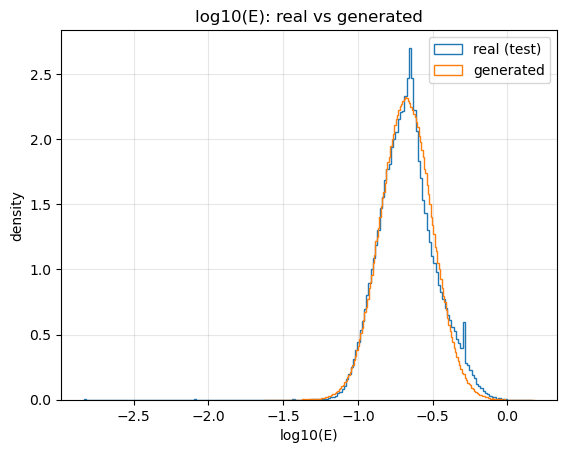

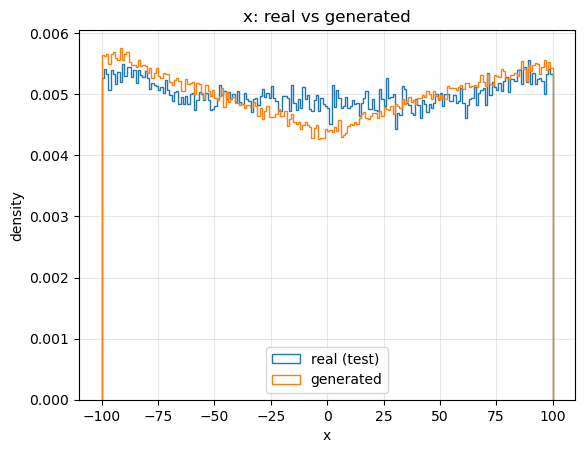

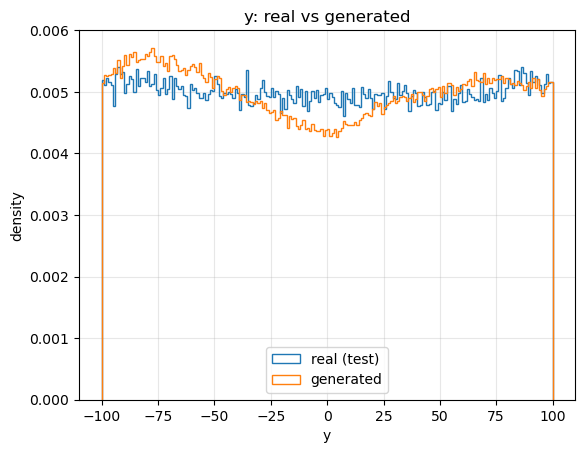

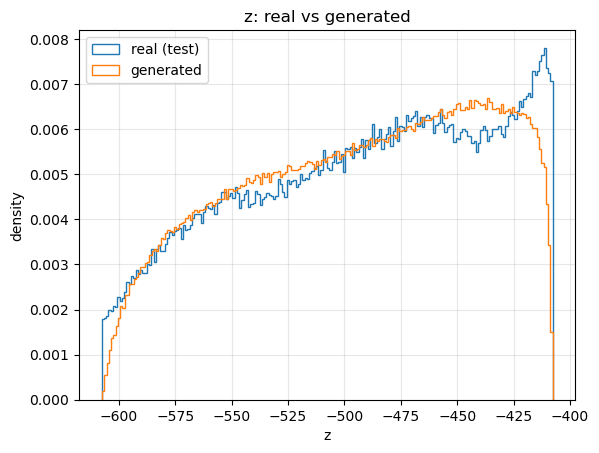

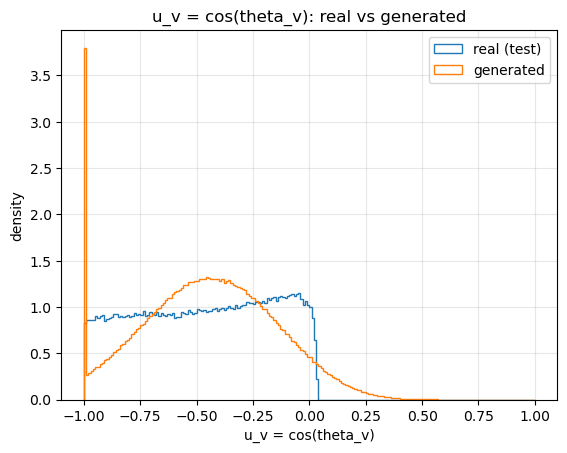

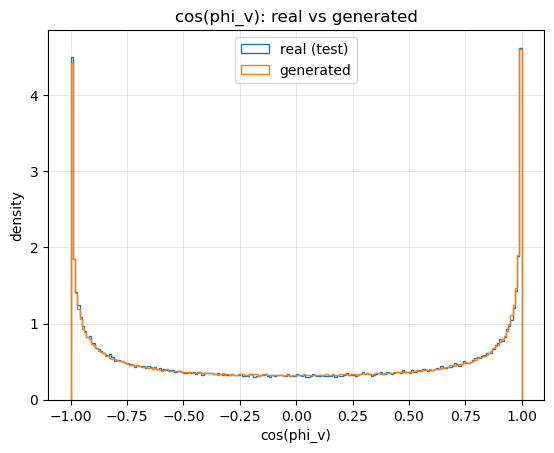

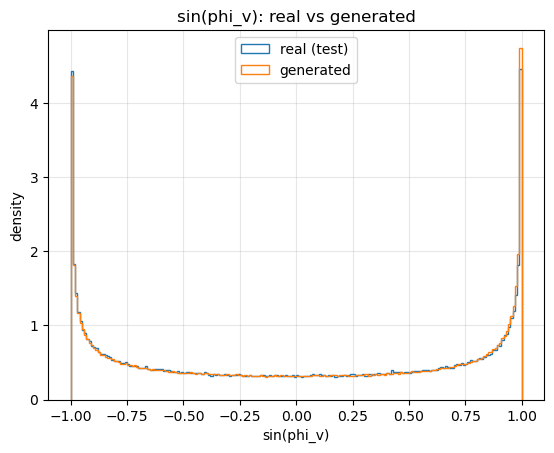

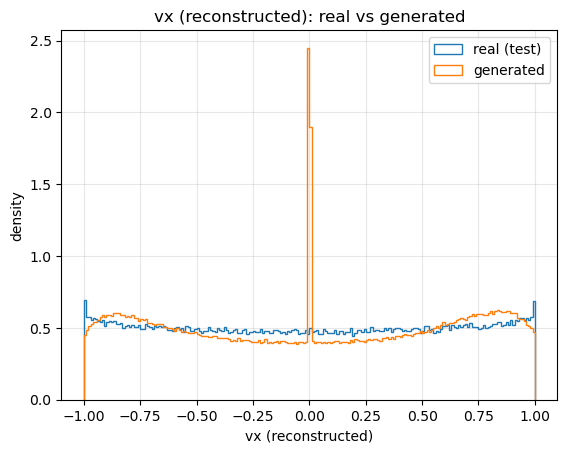

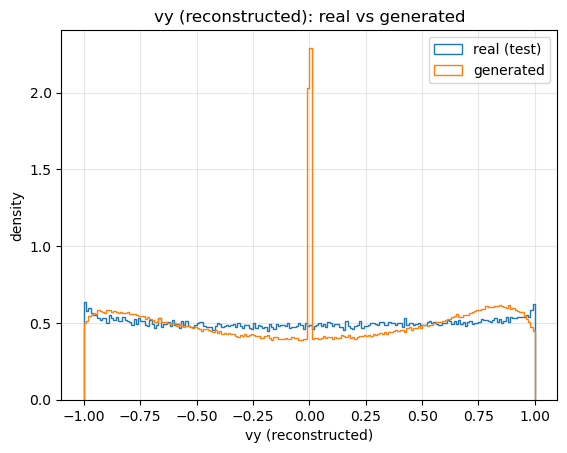

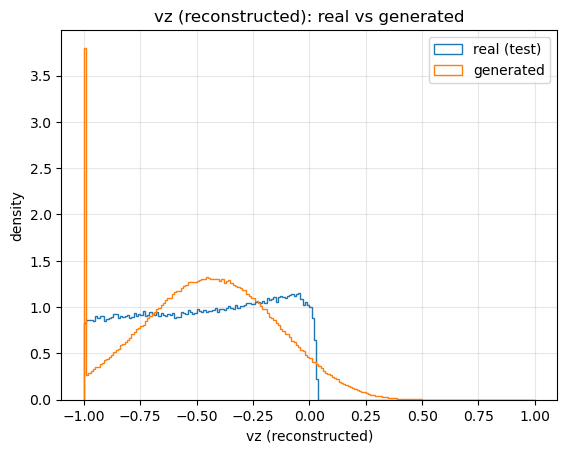


--- RANGE CHECK ---
logE real/gen: -2.833067 0.1645967 | -1.6258092 0.18362743
x real/gen: -99.99797058105469 99.99978637695312 | -99.99987030029297 99.99954223632812
y real/gen: -99.99983978271484 99.99964904785156 | -99.99976348876953 99.99976348876953
z real/gen: -607.6554223632813 -407.6603814697266 | -607.4625741577149 -407.68281188964846
u_v real/gen: -0.999999 0.039442286 | -0.999999 0.80246955
cos(phi_v) real/gen: -1.0 1.0 | -1.0 1.0
sin(phi_v) real/gen: -1.0 1.0 | -1.0 1.0
vx rec real/gen: -0.9999941 0.9999954 | -0.999998 0.99999976
vy rec real/gen: -0.9999958 0.9999981 | -0.9999967 0.9999995
vz rec real/gen: -0.999999 0.039442286 | -0.999999 0.80246955

--- COS/SIN NORM CHECK ---
phi_r real/gen: 1.0 1.0
phi_v real/gen: 1.0 1.0


In [45]:
eps = 1e-6

# ==========================================================
# DATI REALI (test) in scala fisica / feature non scalate
# layout: [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
# ==========================================================

# Usa direttamente la copia RAW costruita nella cella 5
# (se non esiste, fallback su X_test)
if "X_test_unscaled" in globals():
    X_real = X_test_unscaled.copy()
else:
    X_real = X_test.copy()

# -------------------------------
# Energia reale
# -------------------------------
logE_real_test = X_real[:, 0]

# -------------------------------
# Posizione reale
# -------------------------------
s_r_real = X_real[:, 1]
u_r_real = np.tanh(s_r_real)

cphi_r_real = X_real[:, 2].copy()
sphi_r_real = X_real[:, 3].copy()

norm_r = np.sqrt(cphi_r_real**2 + sphi_r_real**2) + 1e-12
cphi_r_real /= norm_r
sphi_r_real /= norm_r

sin_tr_real = np.sqrt(np.maximum(0.0, 1.0 - u_r_real**2))

x_real = C[0] + R * sin_tr_real * cphi_r_real
y_real = C[1] + R * sin_tr_real * sphi_r_real
z_real = C[2] + R * u_r_real

# -------------------------------
# Direzione reale
# -------------------------------
u_v_real = np.clip(X_real[:, 4].copy(), -1.0 + eps, 1.0 - eps)
cphi_v_real = X_real[:, 5].copy()
sphi_v_real = X_real[:, 6].copy()

norm_v = np.sqrt(cphi_v_real**2 + sphi_v_real**2) + 1e-12
cphi_v_real /= norm_v
sphi_v_real /= norm_v

sin_tv_real = np.sqrt(np.maximum(0.0, 1.0 - u_v_real**2))
vx_real = sin_tv_real * cphi_v_real
vy_real = sin_tv_real * sphi_v_real
vz_real = u_v_real

vnorm_real = np.sqrt(vx_real**2 + vy_real**2 + vz_real**2) + 1e-12
vx_real /= vnorm_real
vy_real /= vnorm_real
vz_real /= vnorm_real

# ==========================================================
# DATI GENERATI
# y_gen layout: [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
# ==========================================================

logE_gen = y_gen[:, 0]

# -------------------------------
# Posizione generata
# -------------------------------
s_r_gen = y_gen[:, 1]
u_r_gen = np.tanh(s_r_gen)

cphi_r_gen = y_gen[:, 2].copy()
sphi_r_gen = y_gen[:, 3].copy()

norm_rg = np.sqrt(cphi_r_gen**2 + sphi_r_gen**2) + 1e-12
cphi_r_gen /= norm_rg
sphi_r_gen /= norm_rg

sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen**2))

x_gen = C[0] + R * sin_tr_gen * cphi_r_gen
ypos_gen = C[1] + R * sin_tr_gen * sphi_r_gen
z_gen = C[2] + R * u_r_gen

# -------------------------------
# Direzione generata
# -------------------------------
u_v_gen = np.clip(y_gen[:, 4].copy(), -1.0 + eps, 1.0 - eps)
cphi_v_gen = y_gen[:, 5].copy()
sphi_v_gen = y_gen[:, 6].copy()

norm_vg = np.sqrt(cphi_v_gen**2 + sphi_v_gen**2) + 1e-12
cphi_v_gen /= norm_vg
sphi_v_gen /= norm_vg

sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen**2))
vx_gen_rec = sin_tv_gen * cphi_v_gen
vy_gen_rec = sin_tv_gen * sphi_v_gen
vz_gen = u_v_gen

vnorm_gen = np.sqrt(vx_gen_rec**2 + vy_gen_rec**2 + vz_gen**2) + 1e-12
vx_gen_rec /= vnorm_gen
vy_gen_rec /= vnorm_gen
vz_gen /= vnorm_gen

# ==========================================================
# FUNZIONE PLOT
# ==========================================================
def compare_hist(real, gen, name, bins=200, range_=None):
    plt.figure()
    plt.hist(real, bins=bins, density=True, histtype="step", label="real (test)", range=range_)
    plt.hist(gen,  bins=bins, density=True, histtype="step", label="generated",   range=range_)
    plt.xlabel(name)
    plt.ylabel("density")
    plt.title(f"{name}: real vs generated")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================================
# PLOT: Energia
# ==========================================================
compare_hist(logE_real_test, logE_gen, "log10(E)")

# ==========================================================
# PLOT: Posizione ricostruita
# ==========================================================
compare_hist(x_real, x_gen, "x")
compare_hist(y_real, ypos_gen, "y")
compare_hist(z_real, z_gen, "z")

# ==========================================================
# PLOT: Direzione - FEATURE
# ==========================================================
compare_hist(u_v_real,    u_v_gen,    "u_v = cos(theta_v)", range_=(-1, 1))
compare_hist(cphi_v_real, cphi_v_gen, "cos(phi_v)",         range_=(-1, 1))
compare_hist(sphi_v_real, sphi_v_gen, "sin(phi_v)",         range_=(-1, 1))

# ==========================================================
# PLOT: Direzione - CARTESIANA ricostruita
# ==========================================================
compare_hist(vx_real, vx_gen_rec, "vx (reconstructed)", range_=(-1, 1))
compare_hist(vy_real, vy_gen_rec, "vy (reconstructed)", range_=(-1, 1))
compare_hist(vz_real, vz_gen,     "vz (reconstructed)", range_=(-1, 1))

# ==========================================================
# RANGE CHECK
# ==========================================================
print("\n--- RANGE CHECK ---")
print("logE real/gen:", logE_real_test.min(), logE_real_test.max(), "|", logE_gen.min(), logE_gen.max())

print("x real/gen:", x_real.min(), x_real.max(), "|", x_gen.min(), x_gen.max())
print("y real/gen:", y_real.min(), y_real.max(), "|", ypos_gen.min(), ypos_gen.max())
print("z real/gen:", z_real.min(), z_real.max(), "|", z_gen.min(), z_gen.max())

print("u_v real/gen:", u_v_real.min(), u_v_real.max(), "|", u_v_gen.min(), u_v_gen.max())
print("cos(phi_v) real/gen:", cphi_v_real.min(), cphi_v_real.max(), "|", cphi_v_gen.min(), cphi_v_gen.max())
print("sin(phi_v) real/gen:", sphi_v_real.min(), sphi_v_real.max(), "|", sphi_v_gen.min(), sphi_v_gen.max())

print("vx rec real/gen:", vx_real.min(), vx_real.max(), "|", vx_gen_rec.min(), vx_gen_rec.max())
print("vy rec real/gen:", vy_real.min(), vy_real.max(), "|", vy_gen_rec.min(), vy_gen_rec.max())
print("vz rec real/gen:", vz_real.min(), vz_real.max(), "|", vz_gen.min(), vz_gen.max())

# check norme cos/sin
norm_phi_r_real = np.sqrt(cphi_r_real**2 + sphi_r_real**2)
norm_phi_r_gen  = np.sqrt(cphi_r_gen**2  + sphi_r_gen**2)
norm_phi_v_real = np.sqrt(cphi_v_real**2 + sphi_v_real**2)
norm_phi_v_gen  = np.sqrt(cphi_v_gen**2  + sphi_v_gen**2)

print("\n--- COS/SIN NORM CHECK ---")
print("phi_r real/gen:", norm_phi_r_real.mean(), norm_phi_r_gen.mean())
print("phi_v real/gen:", norm_phi_v_real.mean(), norm_phi_v_gen.mean())

#### Per il secondo modello usare queste v

In [95]:
def sample_types(n_samples, type_probs, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.choice(len(type_probs), size=n_samples, p=type_probs)
    return idx.astype(np.int32)

def one_hot_from_idx(idx, n_types):
    return tf.one_hot(idx, depth=n_types, dtype=tf.float32)

# ==========================================================
# Generazione tipi di particella
# ==========================================================
NGEN = len(X_test)   # per confronti più rapidi puoi anche usare len(X_test)

gen_type_idx = sample_types(NGEN, type_probs)
gen_cond = one_hot_from_idx(gen_type_idx, n_types)

unique, counts = np.unique(gen_type_idx, return_counts=True)

print("\nGenerated particle counts:")
for u, c in zip(unique, counts):
    print(idx_to_type[u], c)

# ==========================================================
# Generazione feature nello spazio del training
# y_gen_scaled = [logE_s, s_r_s, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
# ==========================================================
y_gen_scaled = model.generate_y(gen_cond, NGEN).numpy().astype(np.float32)

# ==========================================================
# Unscale delle feature scalate
# - col 0 = logE
# - col 1 = s_r
# ==========================================================
y_gen = y_gen_scaled.copy()

# unscale logE
y_gen[:, 0] = y_gen_scaled[:, 0] * logE_std + logE_mean

# unscale s_r
y_gen[:, 1] = y_gen_scaled[:, 1] * s_r_std + s_r_mean

# ==========================================================
# Energia fisica
# ==========================================================
E_gen = np.power(10.0, y_gen[:, 0], dtype=np.float32)

# ==========================================================
# Check rapidi
# ==========================================================
print("\n--- Generated feature ranges ---")
print("logE_gen min/max:", y_gen[:, 0].min(), y_gen[:, 0].max())
print("s_r_gen  min/max:", y_gen[:, 1].min(), y_gen[:, 1].max())
print("u_v_gen  min/max:", y_gen[:, 4].min(), y_gen[:, 4].max())
print("E_gen    min/max:", E_gen.min(), E_gen.max())

print("\nGenerated fractions by type:")
for u, c in zip(unique, counts):
    print(f"{idx_to_type[u]:>8s}: {c / NGEN:.6f}")


Generated particle counts:
gamma 278942
e- 2098

--- Generated feature ranges ---
logE_gen min/max: -2.9565485 0.082037866
s_r_gen  min/max: -3.2166796 3.9643037
u_v_gen  min/max: -0.999999 0.35264742
E_gen    min/max: 0.0011052272 1.2079191

Generated fractions by type:
   gamma: 0.992535
      e-: 0.007465


In [96]:
# Ricostruzione posizione e direzione da feature generate
C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-6

def renorm_cos_sin(c, s, eps=1e-12):
    r = np.sqrt(c*c + s*s) + eps
    return c/r, s/r

def u_from_sr(s):
    # u_r in (-1,1)
    return np.tanh(s)

# ==========================================================
# Estrai feature generate
# y = [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
# ==========================================================

s_r_gen = y_gen[:, 1]
u_r_gen = u_from_sr(s_r_gen)

# ==========================================================
# POSIZIONE su sfera
# ==========================================================

cpr_gen, spr_gen = renorm_cos_sin(y_gen[:, 2], y_gen[:, 3])
sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen * u_r_gen))

x_gen = C[0] + R * sin_tr_gen * cpr_gen
ypos_gen = C[1] + R * sin_tr_gen * spr_gen
z_gen = C[2] + R * u_r_gen

# ==========================================================
# DIREZIONE: (u_v, phi_v) -> (vx, vy, vz)
# ==========================================================

u_v_gen = y_gen[:, 4].copy()
u_v_gen = np.clip(u_v_gen, -1.0 + eps, 1.0 - eps)

cpv_gen, spv_gen = renorm_cos_sin(y_gen[:, 5], y_gen[:, 6])
sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen * u_v_gen))

vx_gen = sin_tv_gen * cpv_gen
vy_gen = sin_tv_gen * spv_gen
vz_gen = u_v_gen

# ==========================================================
# Sanity check vincoli
# ==========================================================

rvec_gen = np.vstack([x_gen, ypos_gen, z_gen]).T - C[None, :]
r_gen = np.linalg.norm(rvec_gen, axis=1)

vnorm_gen_check = np.sqrt(vx_gen * vx_gen + vy_gen * vy_gen + vz_gen * vz_gen)

phi_r_norm = np.sqrt(cpr_gen * cpr_gen + spr_gen * spr_gen)
phi_v_norm = np.sqrt(cpv_gen * cpv_gen + spv_gen * spv_gen)

print("--- VINCOLI ---")
print("r_gen: mean", r_gen.mean(), "std", r_gen.std(), "min", r_gen.min(), "max", r_gen.max())
print("mean |r-R| =", np.mean(np.abs(r_gen - R)))

print("||v||: mean", vnorm_gen_check.mean(), "std", vnorm_gen_check.std(),
      "min", vnorm_gen_check.min(), "max", vnorm_gen_check.max())
print("mean ||v||-1| =", np.mean(np.abs(vnorm_gen_check - 1.0)))

print("phi_r norm: mean", phi_r_norm.mean(), "std", phi_r_norm.std(),
      "min", phi_r_norm.min(), "max", phi_r_norm.max())
print("phi_v norm: mean", phi_v_norm.mean(), "std", phi_v_norm.std(),
      "min", phi_v_norm.min(), "max", phi_v_norm.max())

print("E_gen: min", E_gen.min(), "max", E_gen.max())
print("u_r_gen min/max:", u_r_gen.min(), u_r_gen.max())
print("u_v_gen min/max:", u_v_gen.min(), u_v_gen.max())
print("fraction u_v_gen > 0:", np.mean(u_v_gen > 0))

--- VINCOLI ---
r_gen: mean 99.99999998241886 std 4.148066935852716e-06 min 99.99997926208862 max 100.00001954833115
mean |r-R| = 3.2531375725786096e-06
||v||: mean 1.0 std 3.5554976e-08 min 0.9999998 max 1.0000001
mean ||v||-1| = 1.7587867e-08
phi_r norm: mean 1.0 std 3.777082e-08 min 0.9999998 max 1.0000001
phi_v norm: mean 1.0 std 3.680238e-08 min 0.9999998 max 1.0000001
E_gen: min 0.0011052272 max 1.2079191
u_r_gen min/max: -0.99679106 0.9992797
u_v_gen min/max: -0.999999 0.35264742
fraction u_v_gen > 0: 0.04765157984628523


In [65]:
# ==========================================================
# Metriche di validazione su logE
# ==========================================================
from scipy.stats import ks_2samp, wasserstein_distance
import numpy as np

# Reale (test set) in scala fisica
logE_real_test = X_test_s[:, 0] * logE_std + logE_mean

# Generato (già riportato in scala fisica nella cella di generazione)
logE_gen = y_gen[:, 0]

# ----------------------------------------------------------
# Metriche globali
# ----------------------------------------------------------
ks_global = ks_2samp(logE_real_test, logE_gen).statistic
wd_global = wasserstein_distance(logE_real_test, logE_gen)

print("\n--- METRICHE logE globale ---")
print("KS(logE) =", ks_global)
print("Wasserstein(logE) =", wd_global)
print("logE real min/max:", logE_real_test.min(), logE_real_test.max())
print("logE gen  min/max:", logE_gen.min(), logE_gen.max())

# ----------------------------------------------------------
# Metriche per tipo
# ----------------------------------------------------------
def metrics_per_type(type_name):
    if type_name not in type_to_idx:
        return None

    t = type_to_idx[type_name]

    ref = logE_real_test[y_test == t]
    gen = logE_gen[gen_type_idx == t]

    if len(ref) < 50 or len(gen) < 50:
        return None

    ks = ks_2samp(ref, gen).statistic
    wd = wasserstein_distance(ref, gen)

    return {
        "type": type_name,
        "n_ref": len(ref),
        "n_gen": len(gen),
        "frac_ref": len(ref) / len(logE_real_test),
        "frac_gen": len(gen) / len(logE_gen),
        "ks": ks,
        "wd": wd,
    }

for tname in type_names:
    out = metrics_per_type(tname)

    if out is None:
        print(f"\nTipo {tname}: pochi eventi per metriche stabili.")
    else:
        print(f"\n--- {out['type']} ---")
        print("N_ref", out["n_ref"], "N_gen", out["n_gen"])
        print("frac_ref", out["frac_ref"], "frac_gen", out["frac_gen"])
        print("KS(logE)", out["ks"], "Wasserstein(logE)", out["wd"])


--- METRICHE logE globale ---
KS(logE) = 0.0062517791061770245
Wasserstein(logE) = 0.0018593268170464976
logE real min/max: -2.833067 0.16459668
logE gen  min/max: -2.8379934 0.06651974

--- gamma ---
N_ref 278984 N_gen 278995
frac_ref 0.9926843153999431 frac_gen 0.9927234557358383
KS(logE) 0.006335431582158546 Wasserstein(logE) 0.0018556263368255882

--- e- ---
N_ref 2056 N_gen 2045
frac_ref 0.0073156846000569315 frac_gen 0.007276544264161685
KS(logE) 0.03406928733838821 Wasserstein(logE) 0.02006586251988375


##### Plots di confronto

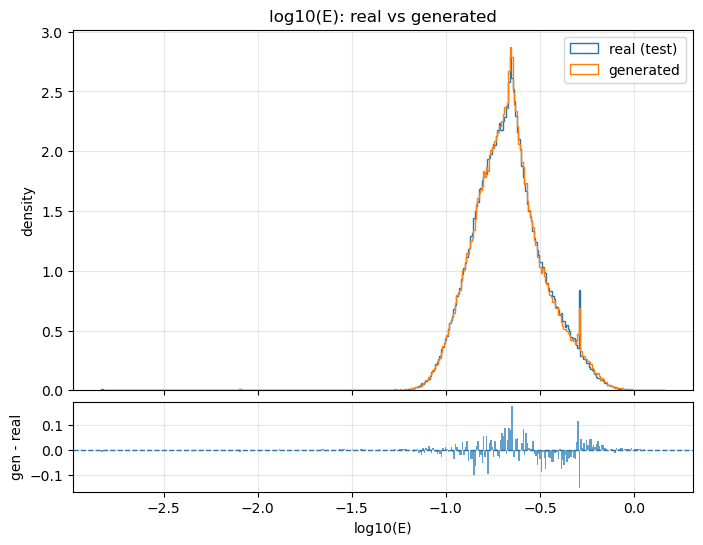

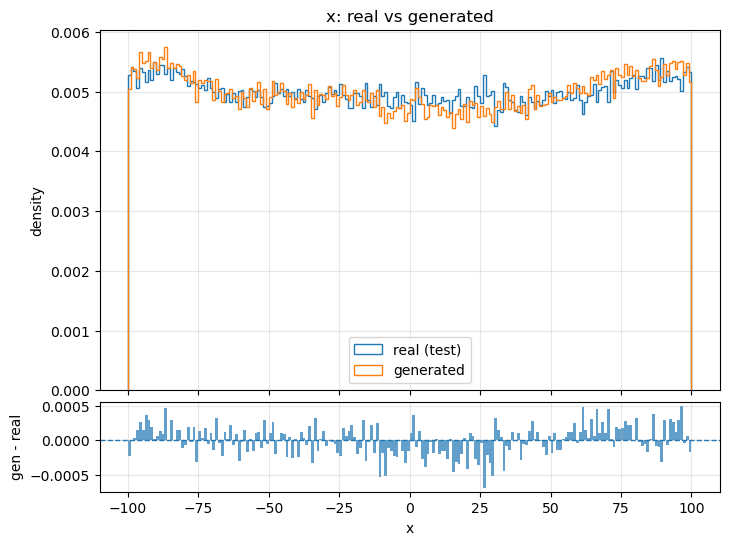

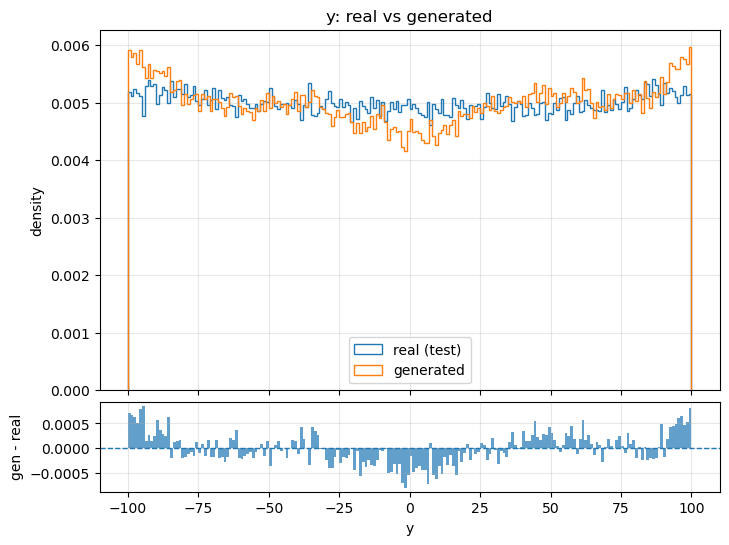

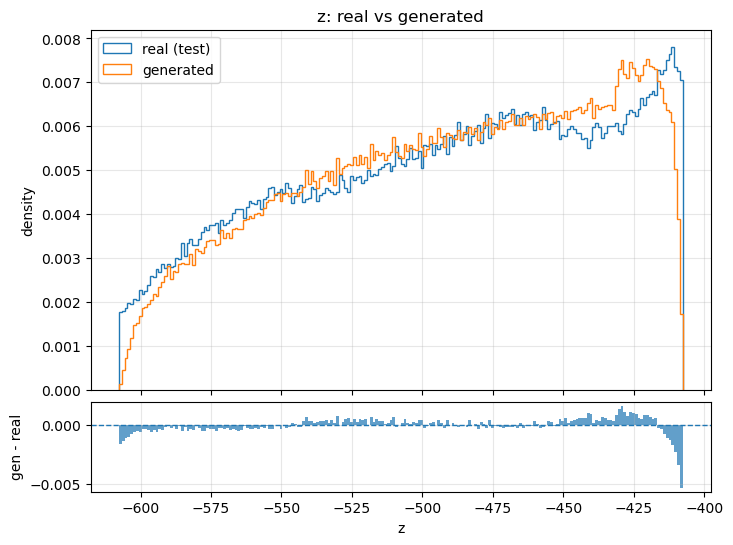

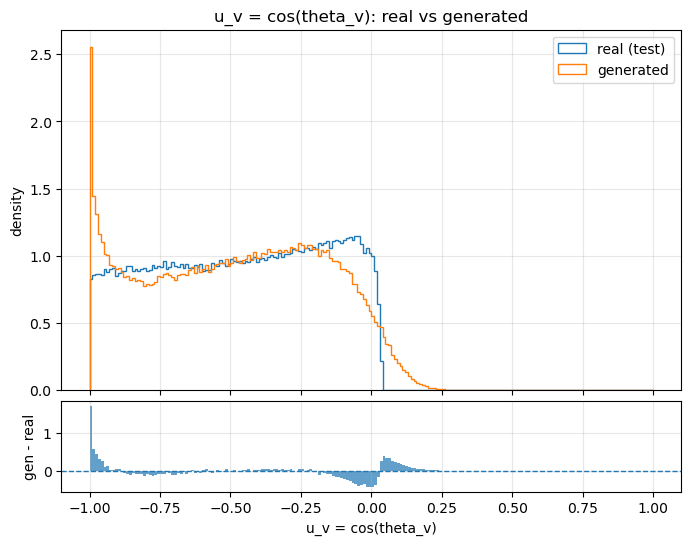

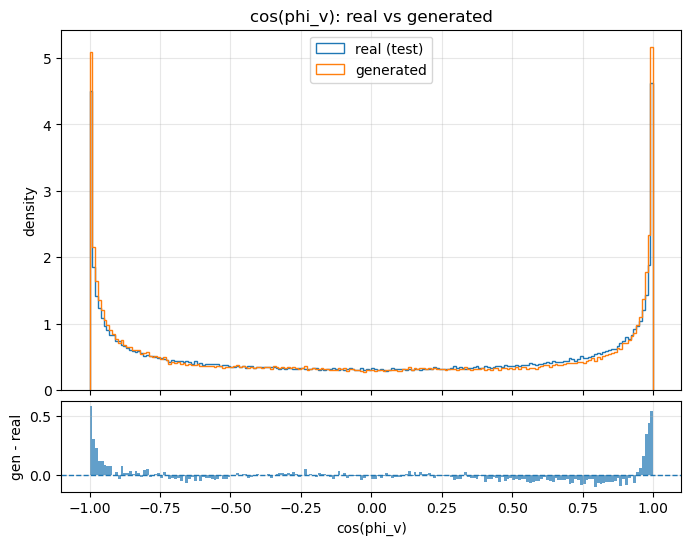

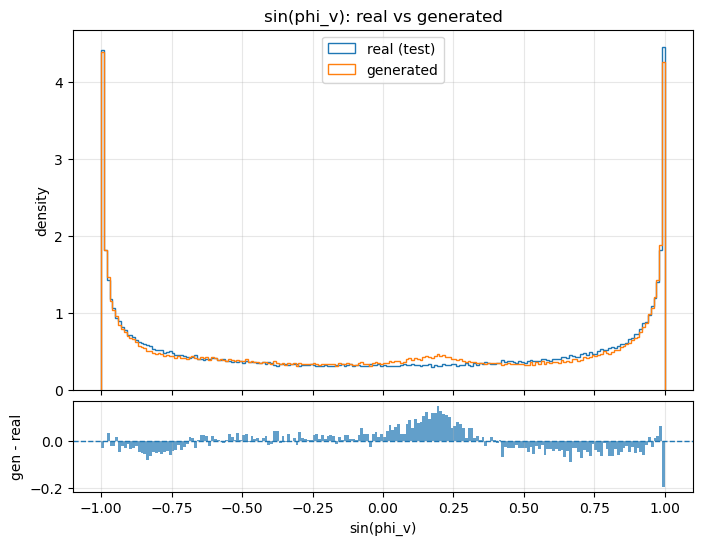

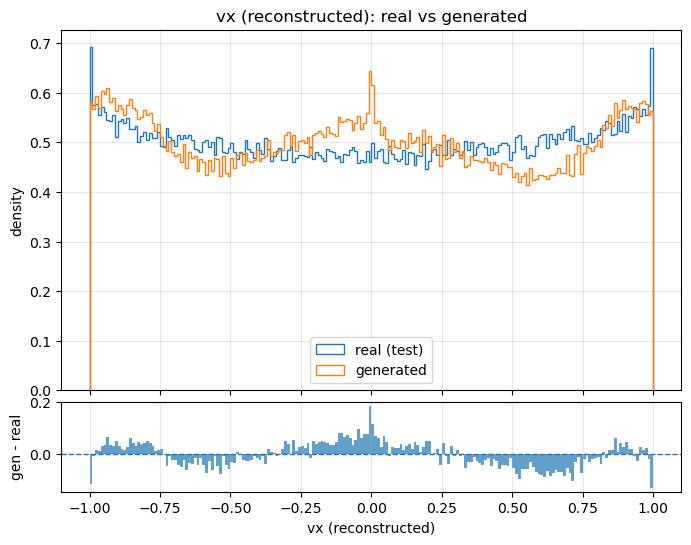

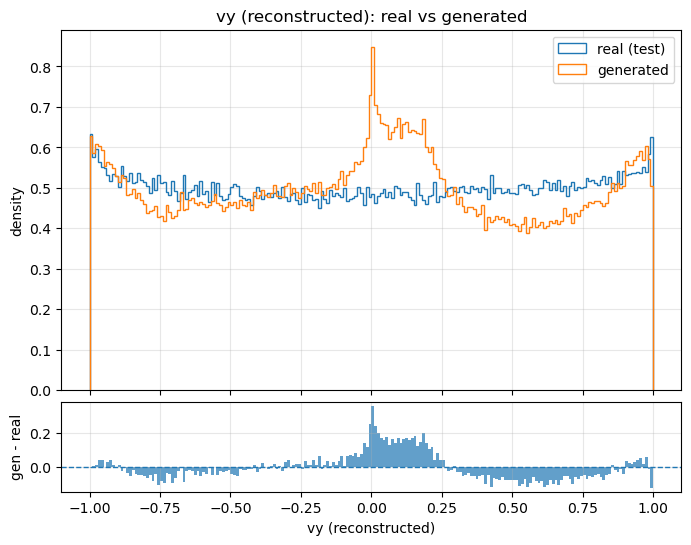

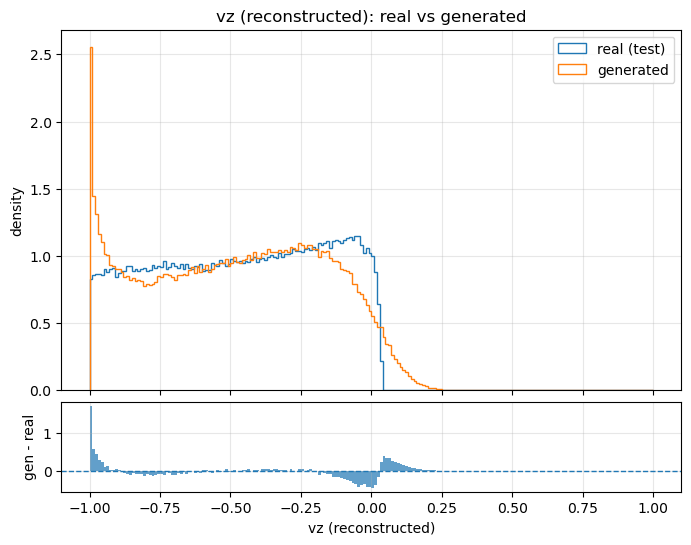


--- RANGE CHECK ---
logE real/gen: -2.833067 0.1645967 | -2.9565485 0.082037866
x real/gen: -99.99797058105469 99.99978637695312 | -99.9999008178711 99.99969482421875
y real/gen: -99.99983978271484 99.99964904785156 | -99.99925994873047 99.99801635742188
z real/gen: -607.6554223632813 -407.6603814697266 | -607.3391076660157 -407.73202911376956
u_v real/gen: -0.999999 0.039442286 | -0.999999 0.35264745
cos(phi_v) real/gen: -1.0 1.0 | -1.0 1.0
sin(phi_v) real/gen: -1.0 1.0 | -1.0 1.0
vx rec real/gen: -0.9999941 0.9999954 | -0.99999887 0.9999933
vy rec real/gen: -0.9999958 0.9999981 | -0.9999996 0.9999839
vz rec real/gen: -0.999999 0.039442286 | -0.999999 0.35264745

--- COS/SIN NORM CHECK ---
phi_r real/gen: 1.0 1.0
phi_v real/gen: 1.0 1.0


In [97]:
eps = 1e-6

# ==========================================================
# DATI REALI (test) in scala fisica / feature non scalate
# layout: [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
# ==========================================================

# Usa direttamente la copia RAW costruita nella cella 5
# (se non esiste, fallback su X_test)
if "X_test_unscaled" in globals():
    X_real = X_test_unscaled.copy()
else:
    X_real = X_test.copy()

# -------------------------------
# Energia reale
# -------------------------------
logE_real_test = X_real[:, 0]

# -------------------------------
# Posizione reale
# -------------------------------
s_r_real = X_real[:, 1]
u_r_real = np.tanh(s_r_real)

cphi_r_real = X_real[:, 2].copy()
sphi_r_real = X_real[:, 3].copy()

norm_r = np.sqrt(cphi_r_real**2 + sphi_r_real**2) + 1e-12
cphi_r_real /= norm_r
sphi_r_real /= norm_r

sin_tr_real = np.sqrt(np.maximum(0.0, 1.0 - u_r_real**2))

x_real = C[0] + R * sin_tr_real * cphi_r_real
y_real = C[1] + R * sin_tr_real * sphi_r_real
z_real = C[2] + R * u_r_real

# -------------------------------
# Direzione reale
# -------------------------------
u_v_real = np.clip(X_real[:, 4].copy(), -1.0 + eps, 1.0 - eps)
cphi_v_real = X_real[:, 5].copy()
sphi_v_real = X_real[:, 6].copy()

norm_v = np.sqrt(cphi_v_real**2 + sphi_v_real**2) + 1e-12
cphi_v_real /= norm_v
sphi_v_real /= norm_v

sin_tv_real = np.sqrt(np.maximum(0.0, 1.0 - u_v_real**2))
vx_real = sin_tv_real * cphi_v_real
vy_real = sin_tv_real * sphi_v_real
vz_real = u_v_real

vnorm_real = np.sqrt(vx_real**2 + vy_real**2 + vz_real**2) + 1e-12
vx_real /= vnorm_real
vy_real /= vnorm_real
vz_real /= vnorm_real

# ==========================================================
# DATI GENERATI
# y_gen layout: [logE, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
# ==========================================================

logE_gen = y_gen[:, 0]

# -------------------------------
# Posizione generata
# -------------------------------
s_r_gen = y_gen[:, 1]
u_r_gen = np.tanh(s_r_gen)

cphi_r_gen = y_gen[:, 2].copy()
sphi_r_gen = y_gen[:, 3].copy()

norm_rg = np.sqrt(cphi_r_gen**2 + sphi_r_gen**2) + 1e-12
cphi_r_gen /= norm_rg
sphi_r_gen /= norm_rg

sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen**2))

x_gen = C[0] + R * sin_tr_gen * cphi_r_gen
ypos_gen = C[1] + R * sin_tr_gen * sphi_r_gen
z_gen = C[2] + R * u_r_gen

# -------------------------------
# Direzione generata
# -------------------------------
u_v_gen = np.clip(y_gen[:, 4].copy(), -1.0 + eps, 1.0 - eps)
cphi_v_gen = y_gen[:, 5].copy()
sphi_v_gen = y_gen[:, 6].copy()

norm_vg = np.sqrt(cphi_v_gen**2 + sphi_v_gen**2) + 1e-12
cphi_v_gen /= norm_vg
sphi_v_gen /= norm_vg

sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen**2))
vx_gen_rec = sin_tv_gen * cphi_v_gen
vy_gen_rec = sin_tv_gen * sphi_v_gen
vz_gen = u_v_gen

vnorm_gen = np.sqrt(vx_gen_rec**2 + vy_gen_rec**2 + vz_gen**2) + 1e-12
vx_gen_rec /= vnorm_gen
vy_gen_rec /= vnorm_gen
vz_gen /= vnorm_gen

# ==========================================================
# FUNZIONE PLOT CON PANNELLO RESIDUI
# ==========================================================
def compare_hist_with_residuals(real, gen, name, bins=200, range_=None,
                                residual_mode="diff", eps_res=1e-12):
    """
    residual_mode:
      - "diff"    -> gen_density - real_density
      - "ratio-1" -> gen_density / real_density - 1
    """
    real = np.asarray(real)
    gen = np.asarray(gen)

    # istogrammi con stessi bin
    real_hist, bin_edges = np.histogram(real, bins=bins, range=range_, density=True)
    gen_hist, _          = np.histogram(gen,  bins=bin_edges, density=True)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)

    if residual_mode == "ratio-1":
        residuals = gen_hist / np.maximum(real_hist, eps_res) - 1.0
        resid_ylabel = "(gen/real) - 1"
    else:
        residuals = gen_hist - real_hist
        resid_ylabel = "gen - real"

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(8, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05}
    )

    # pannello superiore
    ax_top.hist(real, bins=bin_edges, density=True, histtype="step", label="real (test)")
    ax_top.hist(gen,  bins=bin_edges, density=True, histtype="step", label="generated")
    ax_top.set_ylabel("density")
    ax_top.set_title(f"{name}: real vs generated")
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)

    # pannello residui
    ax_bot.axhline(0.0, linestyle="--", linewidth=1)
    ax_bot.bar(bin_centers, residuals, width=bin_widths, align="center", alpha=0.7)
    ax_bot.set_xlabel(name)
    ax_bot.set_ylabel(resid_ylabel)
    ax_bot.grid(True, alpha=0.3)

    plt.show()

# ==========================================================
# PLOT: Energia
# ==========================================================
compare_hist_with_residuals(logE_real_test, logE_gen, "log10(E)", bins=400)

# ==========================================================
# PLOT: Posizione ricostruita
# ==========================================================
compare_hist_with_residuals(x_real, x_gen, "x")
compare_hist_with_residuals(y_real, ypos_gen, "y")
compare_hist_with_residuals(z_real, z_gen, "z")

# ==========================================================
# PLOT: Direzione - FEATURE
# ==========================================================
compare_hist_with_residuals(u_v_real,    u_v_gen,    "u_v = cos(theta_v)", range_=(-1, 1))
compare_hist_with_residuals(cphi_v_real, cphi_v_gen, "cos(phi_v)",         range_=(-1, 1))
compare_hist_with_residuals(sphi_v_real, sphi_v_gen, "sin(phi_v)",         range_=(-1, 1))

# ==========================================================
# PLOT: Direzione - CARTESIANA ricostruita
# ==========================================================
compare_hist_with_residuals(vx_real, vx_gen_rec, "vx (reconstructed)", range_=(-1, 1))
compare_hist_with_residuals(vy_real, vy_gen_rec, "vy (reconstructed)", range_=(-1, 1))
compare_hist_with_residuals(vz_real, vz_gen,     "vz (reconstructed)", range_=(-1, 1))

# ==========================================================
# RANGE CHECK
# ==========================================================
print("\n--- RANGE CHECK ---")
print("logE real/gen:", logE_real_test.min(), logE_real_test.max(), "|", logE_gen.min(), logE_gen.max())

print("x real/gen:", x_real.min(), x_real.max(), "|", x_gen.min(), x_gen.max())
print("y real/gen:", y_real.min(), y_real.max(), "|", ypos_gen.min(), ypos_gen.max())
print("z real/gen:", z_real.min(), z_real.max(), "|", z_gen.min(), z_gen.max())

print("u_v real/gen:", u_v_real.min(), u_v_real.max(), "|", u_v_gen.min(), u_v_gen.max())
print("cos(phi_v) real/gen:", cphi_v_real.min(), cphi_v_real.max(), "|", cphi_v_gen.min(), cphi_v_gen.max())
print("sin(phi_v) real/gen:", sphi_v_real.min(), sphi_v_real.max(), "|", sphi_v_gen.min(), sphi_v_gen.max())

print("vx rec real/gen:", vx_real.min(), vx_real.max(), "|", vx_gen_rec.min(), vx_gen_rec.max())
print("vy rec real/gen:", vy_real.min(), vy_real.max(), "|", vy_gen_rec.min(), vy_gen_rec.max())
print("vz rec real/gen:", vz_real.min(), vz_real.max(), "|", vz_gen.min(), vz_gen.max())

# check norme cos/sin
norm_phi_r_real = np.sqrt(cphi_r_real**2 + sphi_r_real**2)
norm_phi_r_gen  = np.sqrt(cphi_r_gen**2  + sphi_r_gen**2)
norm_phi_v_real = np.sqrt(cphi_v_real**2 + sphi_v_real**2)
norm_phi_v_gen  = np.sqrt(cphi_v_gen**2  + sphi_v_gen**2)

print("\n--- COS/SIN NORM CHECK ---")
print("phi_r real/gen:", norm_phi_r_real.mean(), norm_phi_r_gen.mean())
print("phi_v real/gen:", norm_phi_v_real.mean(), norm_phi_v_gen.mean())

#### Altre celle

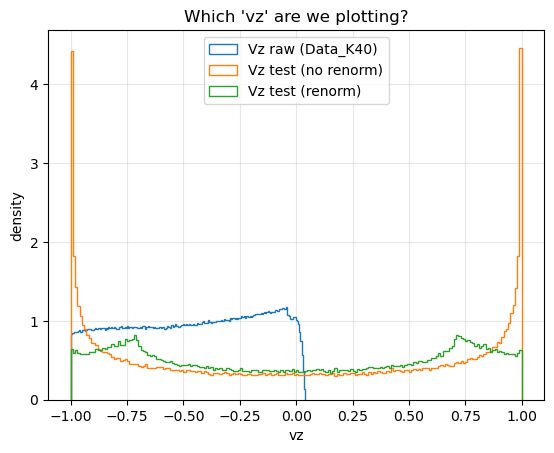

||v|| raw: mean 0.9999999998903653
||v|| test: mean 1.13493


In [78]:
import matplotlib.pyplot as plt
import numpy as np

vz_raw = Data_K40["Vz"].to_numpy()

# vz dal test set (come nel confronto)
vz_test = X_test_s[:,6].copy()
vnorm_test = np.sqrt(X_test_s[:,4]**2 + X_test_s[:,5]**2 + X_test_s[:,6]**2) + 1e-12
vz_test_norm = vz_test / vnorm_test

plt.figure()
plt.hist(vz_raw, bins=200, density=True, histtype="step", label="Vz raw (Data_K40)")
plt.hist(vz_test, bins=200, density=True, histtype="step", label="Vz test (no renorm)")
plt.hist(vz_test_norm, bins=200, density=True, histtype="step", label="Vz test (renorm)")
plt.xlabel("vz")
plt.ylabel("density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Which 'vz' are we plotting?")
plt.show()

print("||v|| raw: mean", np.linalg.norm(Data_K40[["Vx","Vy","Vz"]].to_numpy(), axis=1).mean())
print("||v|| test: mean", np.mean(vnorm_test))

In [30]:
print("fraction u_v > -1e-3:", np.mean(u_v > -1e-3))
print("fraction u_v > -1e-4:", np.mean(u_v > -1e-4))
print("fraction u_v > -1e-5:", np.mean(u_v > -1e-5))

fraction u_v > -1e-3: 0.028140876778452707
fraction u_v > -1e-4: 0.027254352428921935
fraction u_v > -1e-5: 0.027159348615426165


In [24]:
t = type_to_idx["gamma"]

# REAL (test)
u_v_real = X_test_s[y_test==t, 4]  # u_v non scalato
phi_v_real = np.arctan2(X_test_s[y_test==t, 6], X_test_s[y_test==t, 5])

# GEN
u_v_gen = u_v[gen_type_idx==t]
phi_v_gen = np.arctan2(spv[gen_type_idx==t], cpv[gen_type_idx==t])

plt.figure()
plt.hist(u_v_real, bins=200, density=True, histtype="step", label="real")
plt.hist(u_v_gen,  bins=200, density=True, histtype="step", label="gen")
plt.legend(); plt.title("u_v (gamma)")
plt.show()

plt.figure()
plt.hist(phi_v_real, bins=200, density=True, histtype="step", label="real")
plt.hist(phi_v_gen,  bins=200, density=True, histtype="step", label="gen")
plt.legend(); plt.title("phi_v (gamma)")
plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 41361730 but size of corresponding boolean axis is 1000000

In [79]:
# Prendi un batch dalla val
for (y_b, cond_b), _ in val_ds.take(1):
    # Encoder->z->decoder (come nel test_step)
    x_in = tf.concat([y_b, cond_b], axis=1)
    z_mean, z_logvar = model.encoder(x_in, training=False)
    z = model.sample_z(z_mean, z_logvar)
    dec_in = tf.concat([z, cond_b], axis=1)
    dec_out = model.decoder(dec_in, training=False)

    log_sigma = tf.clip_by_value(dec_out[:, 1], model.min_log_sigma, model.max_log_sigma).numpy()
    break

sigma = np.exp(log_sigma)

import matplotlib.pyplot as plt
plt.figure()
plt.hist(log_sigma, bins=200, histtype="step", density=True)
plt.xlabel("log_sigma(logE)")
plt.ylabel("density")
plt.title("Predicted log_sigma for logE (val batch)")
plt.grid(True, alpha=0.3)
plt.show()

print("log_sigma: mean", log_sigma.mean(), "std", log_sigma.std(), "min", log_sigma.min(), "max", log_sigma.max())
print("sigma: mean", sigma.mean(), "min", sigma.min(), "max", sigma.max())

AttributeError: 'CVAE_CatLogE_BetaUV' object has no attribute 'decoder'

### Salvataggio delle nuove distribuzioni generate

In [ ]:
# Costruisci DataFrame in formato originale
gen_df = pd.DataFrame({
    "ParticleName": [idx_to_type[i] for i in gen_type_idx],
    "Energy": E_gen.astype(np.float64),
    "X": x_gen.astype(np.float64),
    "Y": ypos_gen.astype(np.float64),
    "Z": z_gen.astype(np.float64),
    "Vx": vx_gen.astype(np.float64),
    "Vy": vy_gen.astype(np.float64),
    "Vz": vz_gen.astype(np.float64),
})

out_path = "/Users/francesco/Desktop/generated_particles.dat"
gen_df.to_csv(out_path, sep="\t", header=False, index=False)
print("Salvato:", out_path)

## Versione 1.3 
Modifica del modello con categorical discretized head per log(E) e $s_v=atanh(u_v)$ per le direzioni, in modo da scartare i limiti che la beta head per $u_v$ ha dimostrato di avere.

Si procede dunque alla riscrittura delle celle da Preprocessing, al Modello, al Training e alla Validazione

### Controllo parametri 


--- Controllo sfera RAW (r = ||x-C||) ---
r: mean = 99.23411918434232  std = 0.40461867908293037  min = 98.93981564523723  max = 100.06006989051981
Deviazione media da R: 0.7682885734999307

--- Controllo norma direzione RAW (||v||) ---
||v||: mean = 0.9999999998903653  std = 2.88613664129066e-07  min = 0.9999991604741476  max = 1.0000008313726545
Deviazione media da 1: 2.402573376849245e-07

--- Controllo energia ---
E: min = 0.0011044  max = 1.46082  #E<=0 = 0

--- Controllo sfera PROIETTATA ---
r_proj: mean = 99.99999999999902  std = 2.2897201782837348e-14  min = 99.99999999999896  max = 99.99999999999903
Deviazione media da R: 1.0007113932897926e-12

--- Controllo direzione RINORMALIZZATA ---
||vhat||: mean = 0.9999999999990034  std = 3.408393483818028e-15  min = 0.9999999999989996  max = 0.9999999999990002
Deviazione media da 1: 1.0000542428995967e-12


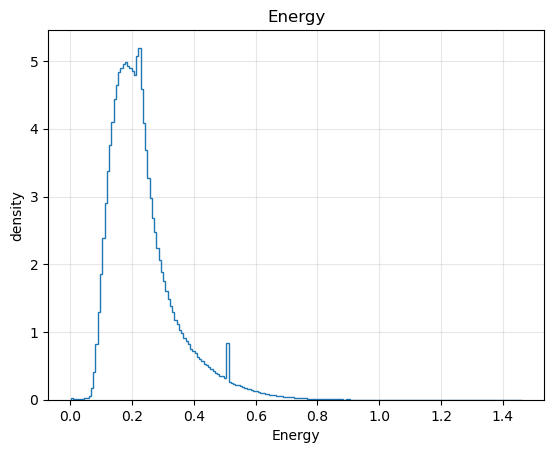

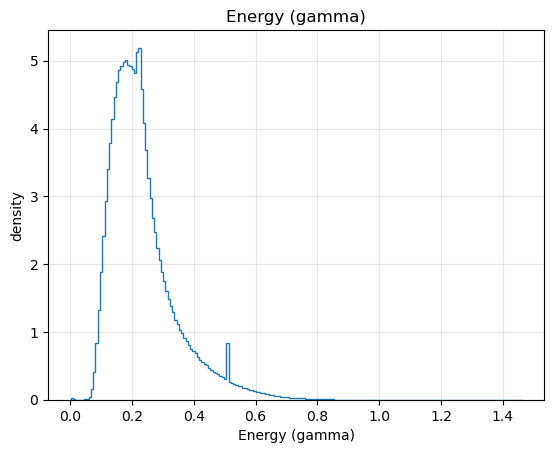

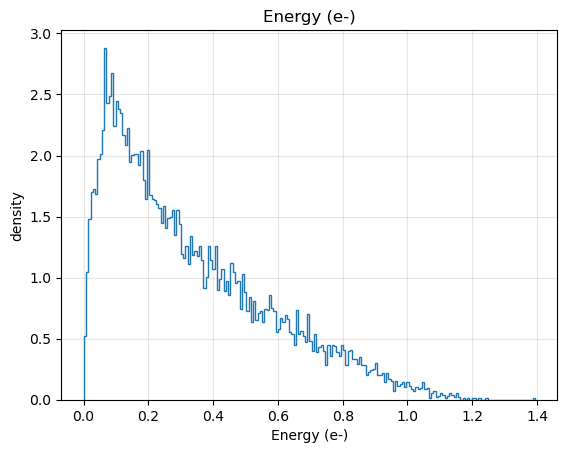

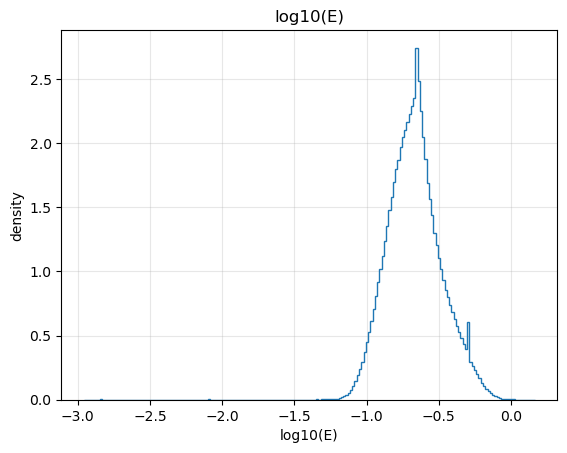

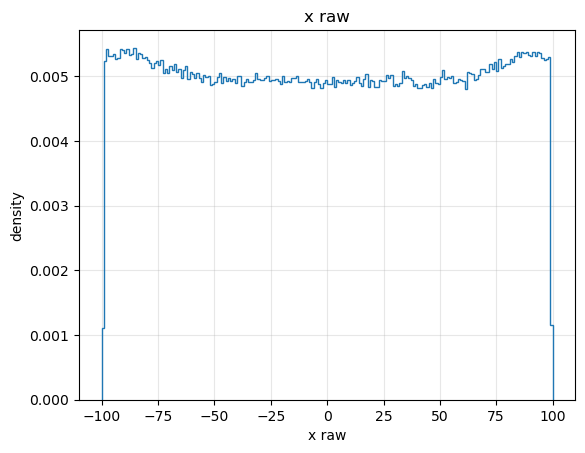

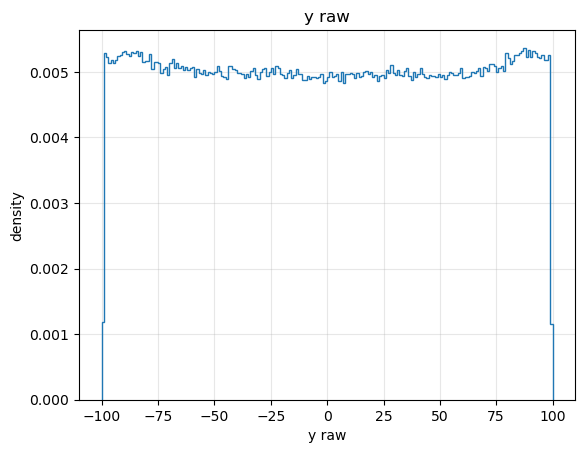

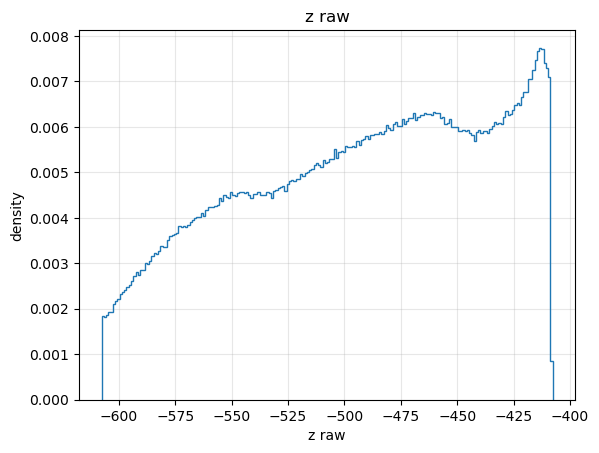

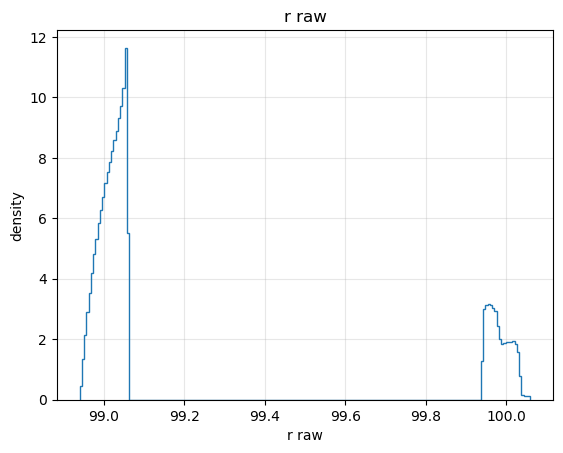

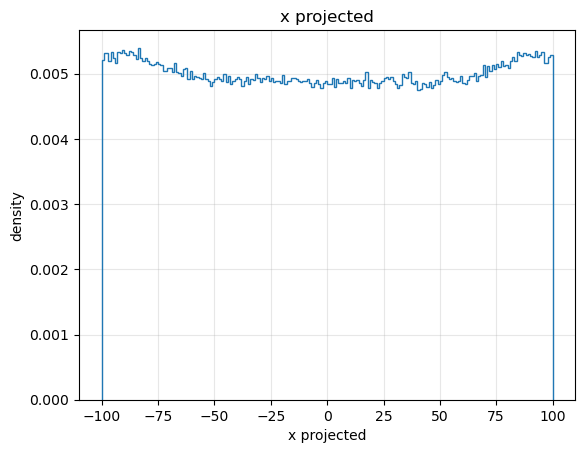

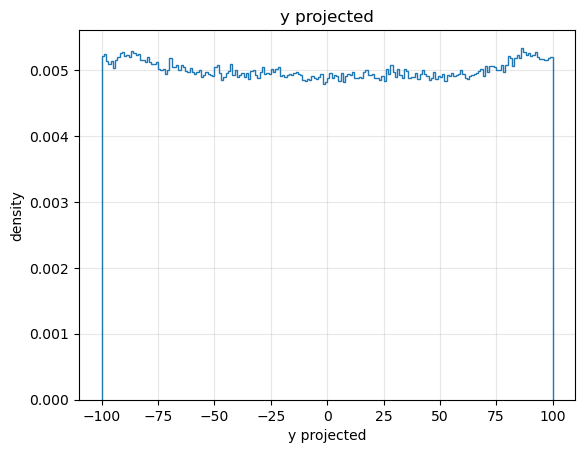

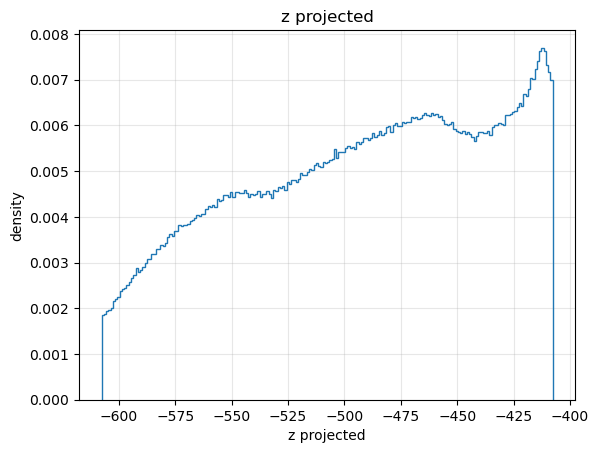

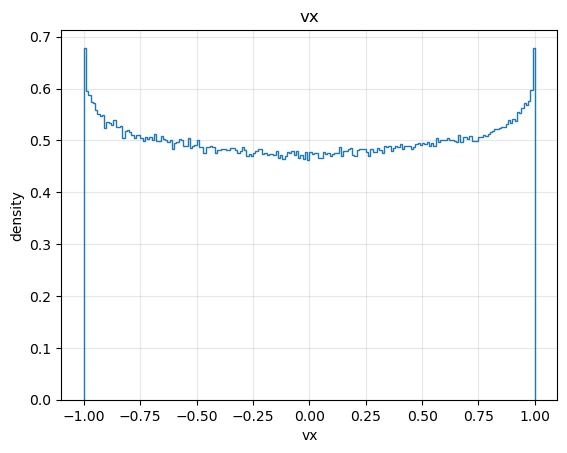

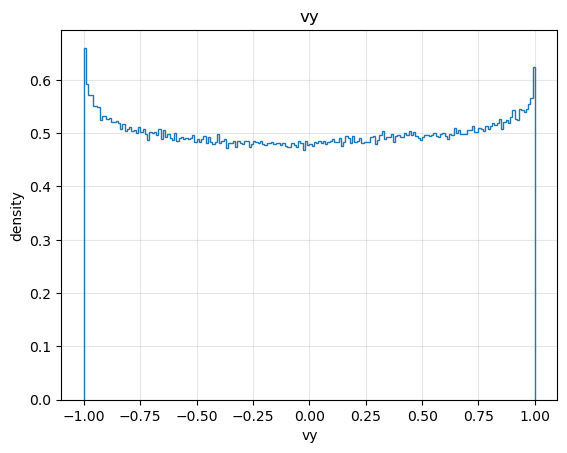

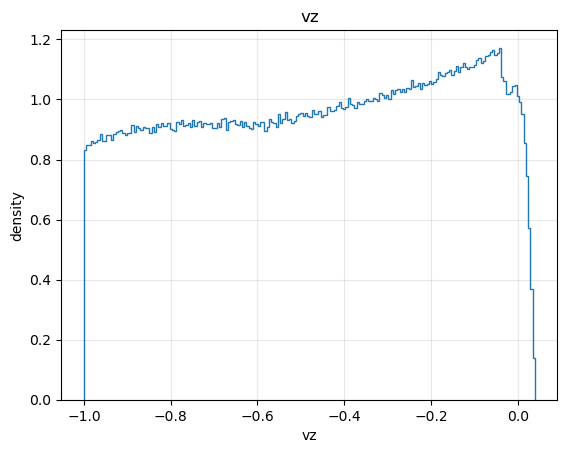

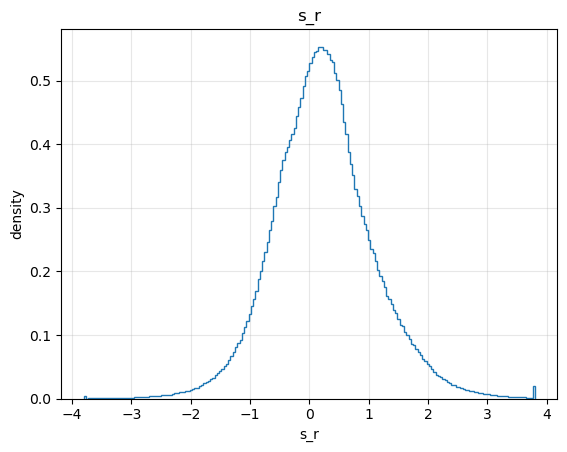

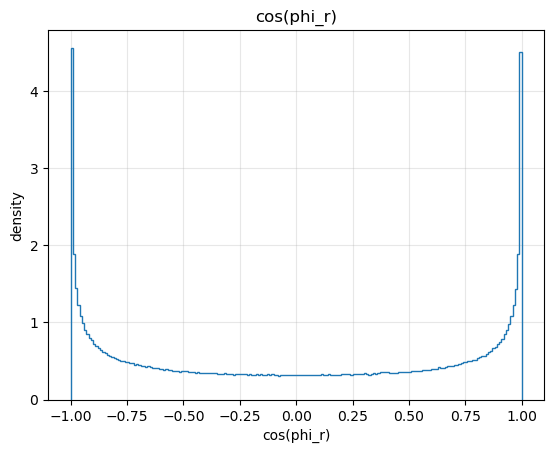

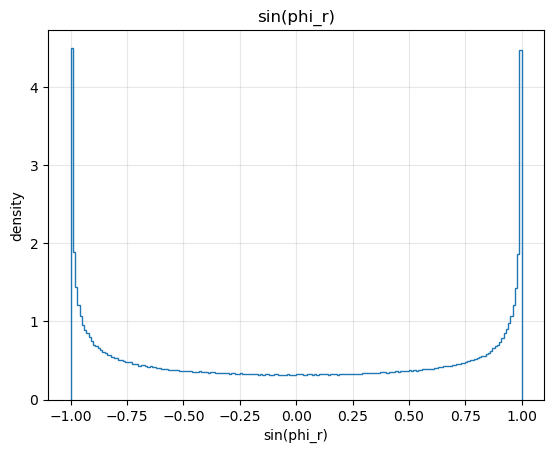

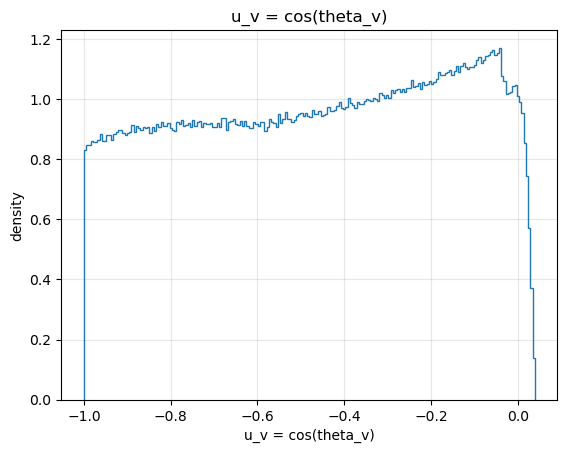

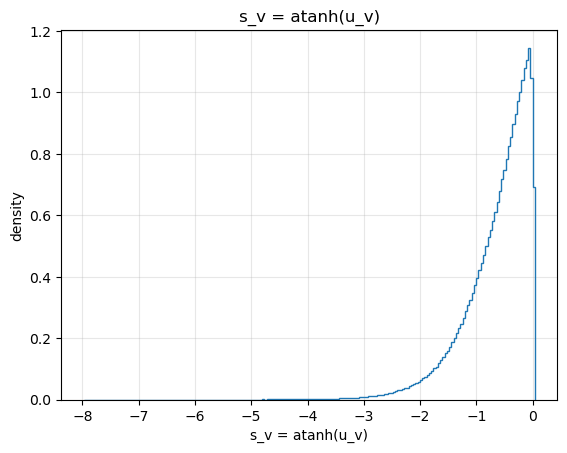

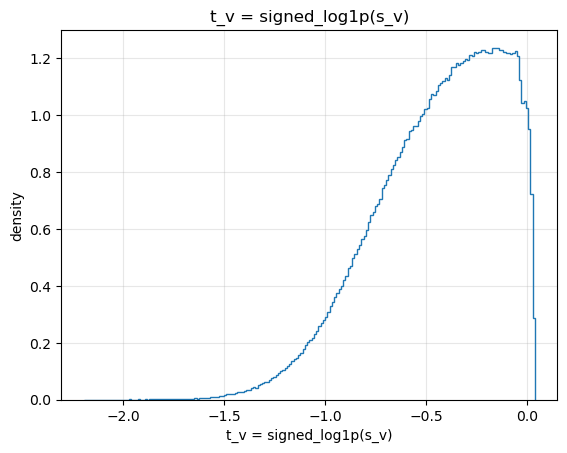

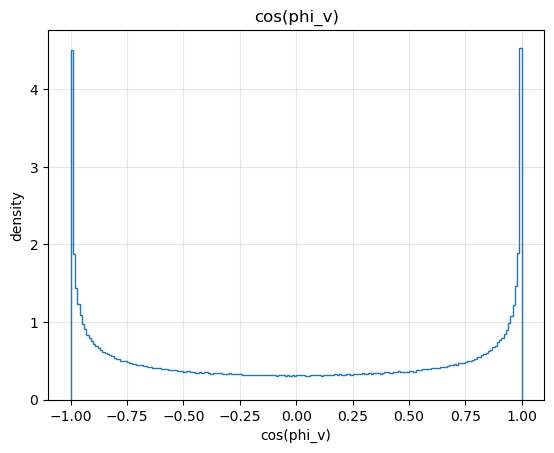

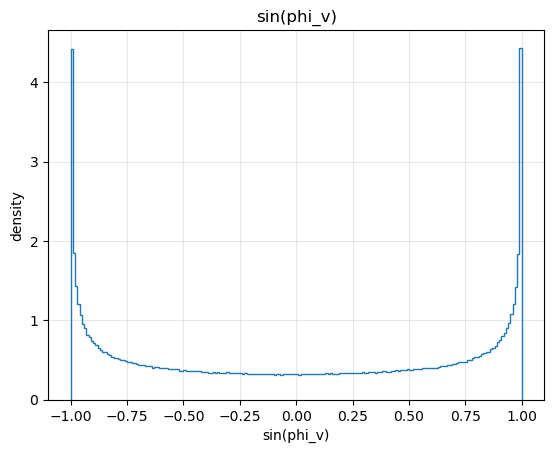


--- Check u_v / s_v / t_v ---
u_v: min = -0.9999997623463023 max = 0.039454388658001965 fraction u_v > 0 = 0.027152410134665236
s_v: min = -7.972799168107784 max = 0.03947488000882558 mean = -0.6359654243625891 std = 0.5727420147771567
t_v: min = -2.1941976862653534 max = 0.03871566256826599 mean = -0.44048208480719686 std = 0.3114601964350427

--- Check inversione signed-log ---
max |s_v_back - s_v| = 1.7763568394002505e-15
max |u_v_back - u_v| = 1.1102230246251565e-16


In [42]:
C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-3   # robusto vicino ai bordi per atanh

xyz = Data_K40[["X", "Y", "Z"]].to_numpy(dtype=np.float64)
v   = Data_K40[["Vx", "Vy", "Vz"]].to_numpy(dtype=np.float64)
E   = Data_K40["Energy"].to_numpy(dtype=np.float64)

x = xyz[:, 0]
y = xyz[:, 1]
z = xyz[:, 2]

vx = v[:, 0]
vy = v[:, 1]
vz = v[:, 2]

# =========================
# Trasformazioni signed-log per s_v
# =========================

def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

# =========================
# Controlli fisici iniziali
# =========================

rvec = xyz - C[None, :]
r = np.linalg.norm(rvec, axis=1)
vnorm = np.linalg.norm(v, axis=1)

print("\n--- Controllo sfera RAW (r = ||x-C||) ---")
print("r: mean =", r.mean(), " std =", r.std(), " min =", r.min(), " max =", r.max())
print("Deviazione media da R:", np.mean(np.abs(r - R)))

print("\n--- Controllo norma direzione RAW (||v||) ---")
print("||v||: mean =", vnorm.mean(), " std =", vnorm.std(), " min =", vnorm.min(), " max =", vnorm.max())
print("Deviazione media da 1:", np.mean(np.abs(vnorm - 1.0)))

print("\n--- Controllo energia ---")
print("E: min =", E.min(), " max =", E.max(), " #E<=0 =", np.sum(E <= 0))

# =========================
# Filtro su energia valida
# =========================

mask_posE = (E > 0) & np.isfinite(E)
if not mask_posE.all():
    print(f"\nRimuovo {np.sum(~mask_posE)} righe con E<=0 o non finita.")
    Data_K40 = Data_K40.loc[mask_posE].reset_index(drop=True)

    xyz = Data_K40[["X", "Y", "Z"]].to_numpy(dtype=np.float64)
    v   = Data_K40[["Vx", "Vy", "Vz"]].to_numpy(dtype=np.float64)
    E   = Data_K40["Energy"].to_numpy(dtype=np.float64)

    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    vx = v[:, 0]
    vy = v[:, 1]
    vz = v[:, 2]

    rvec = xyz - C[None, :]
    r = np.linalg.norm(rvec, axis=1)
    vnorm = np.linalg.norm(v, axis=1)

# =========================
# REGOLARIZZAZIONE POSIZIONE:
# proiezione di tutti i punti sulla sfera di raggio R
# =========================

rhat = rvec / (r[:, None] + 1e-12)
rvec_proj = R * rhat
xyz_proj = C[None, :] + rvec_proj

x_proj = xyz_proj[:, 0]
y_proj = xyz_proj[:, 1]
z_proj = xyz_proj[:, 2]

# check dopo proiezione
r_proj = np.linalg.norm(rvec_proj, axis=1)
print("\n--- Controllo sfera PROIETTATA ---")
print("r_proj: mean =", r_proj.mean(), " std =", r_proj.std(), " min =", r_proj.min(), " max =", r_proj.max())
print("Deviazione media da R:", np.mean(np.abs(r_proj - R)))

# =========================
# REGOLARIZZAZIONE DIREZIONE:
# rinormalizzo per sicurezza numerica
# =========================

vhat = v / (vnorm[:, None] + 1e-12)

vx_hat = vhat[:, 0]
vy_hat = vhat[:, 1]
vz_hat = vhat[:, 2]

vnorm_hat = np.linalg.norm(vhat, axis=1)
print("\n--- Controllo direzione RINORMALIZZATA ---")
print("||vhat||: mean =", vnorm_hat.mean(), " std =", vnorm_hat.std(), " min =", vnorm_hat.min(), " max =", vnorm_hat.max())
print("Deviazione media da 1:", np.mean(np.abs(vnorm_hat - 1.0)))

# =========================
# COSTRUZIONE FEATURE
# x = [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# dove:
#   u_v = cos(theta_v)
#   s_v = atanh(u_v)
#   t_v = sign(s_v) * log(1 + |s_v|)
# =========================

# -------------------------
# posizione dalla sfera proiettata
# -------------------------
u_r = np.clip(rhat[:, 2], -1.0 + eps, 1.0 - eps)
s_r = np.arctanh(u_r)

phi_r = np.arctan2(rhat[:, 1], rhat[:, 0])
cphi_r = np.cos(phi_r)
sphi_r = np.sin(phi_r)

# -------------------------
# direzione dal vettore rinormalizzato
# -------------------------
u_v = vz_hat #np.clip(vz_hat, -1.0 + eps, 1.0 - eps)
s_v = np.arctanh(u_v)

# nuova trasformazione smooth/compressa
t_v = signed_log1p(s_v)

phi_v = np.arctan2(vy_hat, vx_hat)
cphi_v = np.cos(phi_v)
sphi_v = np.sin(phi_v)

# energia
logE = np.log10(E)

# =========================
# Funzione per plot
# =========================

def plot_dist(data, name, bins=200):
    plt.figure()
    plt.hist(data, bins=bins, density=True, histtype="step")
    plt.xlabel(name)
    plt.ylabel("density")
    plt.title(name)
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================================
# Plot Energia
# ==========================================================
plot_dist(E, "Energy")
plot_dist(E[Data_K40["ParticleName"] == "gamma"], "Energy (gamma)")
plot_dist(E[Data_K40["ParticleName"] == "e-"], "Energy (e-)")
plot_dist(logE, "log10(E)")


# =========================
# Plot posizione RAW
# =========================

plot_dist(x, "x raw")
plot_dist(y, "y raw")
plot_dist(z, "z raw")
plot_dist(r, "r raw")

# =========================
# Plot posizione PROIETTATA
# =========================

plot_dist(x_proj, "x projected")
plot_dist(y_proj, "y projected")
plot_dist(z_proj, "z projected")
# plot_dist(r_proj, "r projected")

# =========================
# Plot direzioni
# =========================

plot_dist(vx_hat, "vx")
plot_dist(vy_hat, "vy")
plot_dist(vz_hat, "vz")

# =========================
# Plot feature posizione
# =========================

plot_dist(s_r, "s_r")
plot_dist(cphi_r, "cos(phi_r)")
plot_dist(sphi_r, "sin(phi_r)")

# =========================
# Plot feature direzione
# =========================

plot_dist(u_v, "u_v = cos(theta_v)")
plot_dist(s_v, "s_v = atanh(u_v)")
plot_dist(t_v, "t_v = signed_log1p(s_v)")
plot_dist(cphi_v, "cos(phi_v)")
plot_dist(sphi_v, "sin(phi_v)")

# =========================
# Check utili su u_v / s_v / t_v
# =========================

# inversione per controllo numerico
s_v_back = signed_expm1(t_v)
u_v_back = np.tanh(s_v_back)

print("\n--- Check u_v / s_v / t_v ---")
print("u_v: min =", u_v.min(), "max =", u_v.max(), "fraction u_v > 0 =", np.mean(u_v > 0))
print("s_v: min =", s_v.min(), "max =", s_v.max(), "mean =", s_v.mean(), "std =", s_v.std())
print("t_v: min =", t_v.min(), "max =", t_v.max(), "mean =", t_v.mean(), "std =", t_v.std())

print("\n--- Check inversione signed-log ---")
print("max |s_v_back - s_v| =", np.max(np.abs(s_v_back - s_v)))
print("max |u_v_back - u_v| =", np.max(np.abs(u_v_back - u_v)))

In [8]:
print("r mean =", r.mean())
print("r median =", np.median(r))
print("r std =", r.std())
print("r min/max =", r.min(), r.max())

# Centro geometrico approssimato dei punti
print("mean x,y,z =", xyz.mean(axis=0))

# range coordinate
print("x min/max =", x.min(), x.max())
print("y min/max =", y.min(), y.max())
print("z min/max =", z.min(), z.max())

type_counts = Data_K40["ParticleName"].value_counts()
type_probs = type_counts / type_counts.sum()

print("\n--- Distribuzione ParticleName ---")
print(type_counts)
print("\nProbabilità empiriche:")
print(type_probs)

r mean = 99.15754149119842
r median = 99.03359914985924
r std = 0.33527555200808173
r min/max = 98.93973163615608 100.06004379411394
mean x,y,z = [-1.47665719e-01  6.44356659e-02 -4.80935780e+02]
x min/max = -99.9992 100.0
y min/max = -99.9993 99.9995
z min/max = -607.599 -407.819

--- Distribuzione ParticleName ---
ParticleName
gamma    1962275
e-         37488
e+           199
mu-           38
Name: count, dtype: int64

Probabilità empiriche:
ParticleName
gamma    0.981137
e-       0.018744
e+       0.000100
mu-      0.000019
Name: count, dtype: float64


In [9]:
# ==========================================================
# Costruzione dataframe finale delle feature
# Ora usiamo s_v = atanh(u_v) invece di u_v
# Feature finali:
# [logE, s_r, cphi_r, sphi_r, s_v, cphi_v, sphi_v]
# ==========================================================

# log energia
logE = np.log10(E)

# dataframe finale
feat = pd.DataFrame({
    "ParticleName": Data_K40["ParticleName"].astype(str).to_numpy(),
    "logE":   logE.astype(np.float32),
    "s_r":    s_r.astype(np.float32),
    "cphi_r": cphi_r.astype(np.float32),
    "sphi_r": sphi_r.astype(np.float32),
    "s_v":    s_v.astype(np.float32),
    "cphi_v": cphi_v.astype(np.float32),
    "sphi_v": sphi_v.astype(np.float32),
})

print("feat shape:", feat.shape)

print("\nPrime righe:")
display(feat.head())

# ==========================================================
# Check finitezza
# ==========================================================

print("\n--- Check finitezza ---")

arr = feat[["logE","s_r","cphi_r","sphi_r","s_v","cphi_v","sphi_v"]].to_numpy()
bad = ~np.isfinite(arr).all(axis=1)

print("Righe con NaN/Inf:", np.sum(bad))

# ==========================================================
# Range feature
# ==========================================================

print("\n--- Range feature ---")

for c in ["logE","s_r","cphi_r","sphi_r","s_v","cphi_v","sphi_v"]:
    print(f"{c:>8s} : {feat[c].min()}  {feat[c].max()}")

# ==========================================================
# Check cerchi unitari
# ==========================================================

print("\n--- Check cerchi unitari ---")

cr = np.sqrt(feat["cphi_r"].to_numpy()**2 + feat["sphi_r"].to_numpy()**2)
cv = np.sqrt(feat["cphi_v"].to_numpy()**2 + feat["sphi_v"].to_numpy()**2)

print("pos: mean =", cr.mean(), "std =", cr.std(), "min =", cr.min(), "max =", cr.max())
print("dir: mean =", cv.mean(), "std =", cv.std(), "min =", cv.min(), "max =", cv.max())

# ==========================================================
# Check direzione fisica ricostruita
# ==========================================================

print("\n--- Check u_v ricostruito ---")

u_v_check = np.tanh(feat["s_v"].to_numpy())

print("u_v: min =", u_v_check.min(), "max =", u_v_check.max())
print("fraction u_v > 0 =", np.mean(u_v_check > 0))

# ==========================================================
# Check distribuzione s_v
# ==========================================================

print("\n--- Check s_v ---")

print("s_v mean =", feat["s_v"].mean())
print("s_v std  =", feat["s_v"].std())
print("s_v min/max =", feat["s_v"].min(), feat["s_v"].max())

feat shape: (2000000, 8)

Prime righe:


,ParticleName,logE,s_r,cphi_r,sphi_r,s_v,cphi_v,sphi_v
0,gamma,-0.680020,0.507803,-0.984977,-0.172687,-1.229419,0.352515,0.935806
1,gamma,-0.657866,-0.643019,-0.322391,-0.946607,-0.825649,-0.442524,-0.896757
2,gamma,-0.663476,0.273822,0.920395,0.390991,-1.525347,0.947804,-0.318852
3,gamma,-0.635548,1.485895,0.762855,-0.646570,-0.628524,-0.178448,0.983949
4,gamma,-0.638287,0.201488,-0.798718,0.601706,-0.659038,-0.046631,-0.998912



--- Check finitezza ---
Righe con NaN/Inf: 0

--- Range feature ---
    logE : -0.6989700198173523  -0.6020600199699402
     s_r : -3.800201177597046  3.800201177597046
  cphi_r : -1.0  1.0
  sphi_r : -1.0  1.0
     s_v : -3.800201177597046  0.03956722840666771
  cphi_v : -1.0  1.0
  sphi_v : -1.0  1.0

--- Check cerchi unitari ---
pos: mean = 1.0 std = 2.5727086e-08 min = 0.99999994 max = 1.0
dir: mean = 1.0 std = 2.5722391e-08 min = 0.99999994 max = 1.0

--- Check u_v ricostruito ---
u_v: min = -0.999 max = 0.039546594
fraction u_v > 0 = 0.017329

--- Check s_v ---
s_v mean = -0.75583285
s_v std  = 0.60449654
s_v min/max = -3.8002012 0.03956723


### Standardizzazione

In [10]:
# ==========================================================
# Filter rare particle types + build RAW feature matrix
# Features:
# [logE, s_r, cphi_r, sphi_r, s_v, cphi_v, sphi_v]
# ==========================================================

prob_threshold = 1e-5

# ----------------------------------------------------------
# 1) Filter rare particle types
# ----------------------------------------------------------
type_counts_full = feat["ParticleName"].value_counts()
type_probs_full = type_counts_full / type_counts_full.sum()

valid_types = type_probs_full[type_probs_full >= prob_threshold].index

print("Original particle types:", len(type_counts_full))
print("Keeping particle types:", len(valid_types))
print("Dropping rare types:", len(type_counts_full) - len(valid_types))

feat = feat[feat["ParticleName"].isin(valid_types)].reset_index(drop=True)

# Recompute counts after filtering
type_counts = feat["ParticleName"].value_counts()
type_names = type_counts.index.to_list()
n_types = len(type_names)

type_to_idx = {t: i for i, t in enumerate(type_names)}
idx_to_type = {i: t for t, i in type_to_idx.items()}

type_probs = (type_counts / type_counts.sum()).to_numpy(dtype=np.float64)

print("\nNumero tipi:", n_types)
print("Tipi:", type_names)

print("\nProbabilità empiriche:")
for t, p in zip(type_names, type_probs):
    print(f"{t:>12s}  p={p:.6e}")

# ----------------------------------------------------------
# 2) Build RAW feature matrix
# ----------------------------------------------------------
cont_cols = ["logE", "s_r", "cphi_r", "sphi_r", "s_v", "cphi_v", "sphi_v"]

X_raw = feat[cont_cols].to_numpy(dtype=np.float32)

# Labels as integer indices
y_type = feat["ParticleName"].map(type_to_idx).to_numpy(dtype=np.int32)

print("\nX_raw shape:", X_raw.shape)
print("y_type shape:", y_type.shape)

# ----------------------------------------------------------
# 3) Sanity checks on RAW features
# ----------------------------------------------------------
print("\n--- Feature ranges (RAW) ---")
for c in cont_cols:
    print(f"{c:>8s} : {feat[c].min()}  {feat[c].max()}")

print("\n--- Means/std (RAW) ---")
for j, c in enumerate(cont_cols):
    print(f"{c:>8s} : mean={X_raw[:, j].mean(): .6f}  std={X_raw[:, j].std(): .6f}")

# ----------------------------------------------------------
# 4) Check fisico aggiuntivo: u_v ricostruito da s_v
# ----------------------------------------------------------
u_v_from_sv = np.tanh(X_raw[:, 4])

print("\n--- u_v reconstructed from s_v ---")
print("u_v: min =", u_v_from_sv.min(), "max =", u_v_from_sv.max())
print("fraction u_v > 0 =", np.mean(u_v_from_sv > 0))

Original particle types: 4
Keeping particle types: 4
Dropping rare types: 0

Numero tipi: 4
Tipi: ['gamma', 'e-', 'e+', 'mu-']

Probabilità empiriche:
       gamma  p=9.811375e-01
          e-  p=1.874400e-02
          e+  p=9.950000e-05
         mu-  p=1.900000e-05

X_raw shape: (2000000, 7)
y_type shape: (2000000,)

--- Feature ranges (RAW) ---
    logE : -0.6989700198173523  -0.6020600199699402
     s_r : -3.800201177597046  3.800201177597046
  cphi_r : -1.0  1.0
  sphi_r : -1.0  1.0
     s_v : -3.800201177597046  0.03956722840666771
  cphi_v : -1.0  1.0
  sphi_v : -1.0  1.0

--- Means/std (RAW) ---
    logE : mean=-0.650783  std= 0.027934
     s_r : mean= 0.406223  std= 0.830114
  cphi_r : mean=-0.002000  std= 0.706634
  sphi_r : mean= 0.000871  std= 0.707576
     s_v : mean=-0.755833  std= 0.604496
  cphi_v : mean= 0.002622  std= 0.706794
  sphi_v : mean=-0.000338  std= 0.707415

--- u_v reconstructed from s_v ---
u_v: min = -0.999 max = 0.039546594
fraction u_v > 0 = 0.017329


In [11]:
# ==========================================================
# Train / Validation / Test split
# 70% train, 15% val, 15% test
# SPLIT SU DATI RAW
#
# Feature layout:
# [logE, s_r, cphi_r, sphi_r, s_v, cphi_v, sphi_v]
# ==========================================================

test_size_total = 0.30
val_size_from_temp = 0.50   # metà del 30% -> 15% val, 15% test

idx_all = np.arange(len(X_raw))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all,
    y_type,
    test_size=test_size_total,
    random_state=42,
    stratify=y_type
)

idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp,
    y_temp,
    test_size=val_size_from_temp,
    random_state=42,
    stratify=y_temp
)

# ----------------------------------------------------------
# RAW splits
# ----------------------------------------------------------
X_train = X_raw[idx_train]
X_val   = X_raw[idx_val]
X_test  = X_raw[idx_test]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# ----------------------------------------------------------
# Utility: frazioni per tipo
# ----------------------------------------------------------
def frac_per_type(y_idx, n_types):
    c = np.bincount(y_idx, minlength=n_types).astype(np.float64)
    return c / c.sum()

print("\nCheck distribuzione tipi:")
print("All  :", frac_per_type(y_type,  n_types))
print("Train:", frac_per_type(y_train, n_types))
print("Val  :", frac_per_type(y_val,   n_types))
print("Test :", frac_per_type(y_test,  n_types))

# ----------------------------------------------------------
# Copie RAW esplicite per confronti fisici
# ----------------------------------------------------------
X_train_unscaled = X_train.copy()
X_val_unscaled   = X_val.copy()
X_test_unscaled  = X_test.copy()

print("\nRAW copies ready:")
print("X_train_unscaled:", X_train_unscaled.shape)
print("X_val_unscaled  :", X_val_unscaled.shape)
print("X_test_unscaled :", X_test_unscaled.shape)

# ----------------------------------------------------------
# Check fisico aggiuntivo: u_v ricostruito da s_v nei vari split
# ----------------------------------------------------------
u_v_train = np.tanh(X_train[:, 4])
u_v_val   = np.tanh(X_val[:, 4])
u_v_test  = np.tanh(X_test[:, 4])

print("\n--- Check u_v reconstructed from s_v ---")
print("Train u_v min/max:", u_v_train.min(), u_v_train.max(), " frac > 0 =", np.mean(u_v_train > 0))
print("Val   u_v min/max:", u_v_val.min(),   u_v_val.max(),   " frac > 0 =", np.mean(u_v_val > 0))
print("Test  u_v min/max:", u_v_test.min(),  u_v_test.max(),  " frac > 0 =", np.mean(u_v_test > 0))

Train: (1400000, 7) Val: (300000, 7) Test: (300000, 7)

Check distribuzione tipi:
All  : [9.811375e-01 1.874400e-02 9.950000e-05 1.900000e-05]
Train: [9.81137143e-01 1.87442857e-02 9.92857143e-05 1.92857143e-05]
Val  : [9.81136667e-01 1.87433333e-02 1.00000000e-04 2.00000000e-05]
Test : [9.81140000e-01 1.87433333e-02 1.00000000e-04 1.66666667e-05]

RAW copies ready:
X_train_unscaled: (1400000, 7)
X_val_unscaled  : (300000, 7)
X_test_unscaled : (300000, 7)

--- Check u_v reconstructed from s_v ---
Train u_v min/max: -0.999 0.039459076  frac > 0 = 0.017435714285714287
Val   u_v min/max: -0.999 0.039546594  frac > 0 = 0.017273333333333335
Test  u_v min/max: -0.999 0.03942319  frac > 0 = 0.016886666666666668


In [12]:
# ==========================================================
# Scaling SOLO su train
# Standardizziamo:
#   col 0 -> logE
#   col 1 -> s_r
#   col 4 -> s_v
# Lasciamo invariati:
#   cphi_r, sphi_r, cphi_v, sphi_v
#
# Feature layout:
# [logE, s_r, cphi_r, sphi_r, s_v, cphi_v, sphi_v]
# ==========================================================

scaler_cont = StandardScaler()

# fit solo su train RAW, sulle colonne continue non limitate
scale_cols = [0, 1, 4]   # logE, s_r, s_v
scaler_cont.fit(X_train[:, scale_cols])

def apply_selected_scaler(X_in, scaler, scale_cols):
    X_out = X_in.copy()
    X_out[:, scale_cols] = scaler.transform(X_in[:, scale_cols]).astype(np.float32)
    return X_out

X_train_s = apply_selected_scaler(X_train, scaler_cont, scale_cols)
X_val_s   = apply_selected_scaler(X_val,   scaler_cont, scale_cols)
X_test_s  = apply_selected_scaler(X_test,  scaler_cont, scale_cols)

print("Scaler means  :", scaler_cont.mean_)
print("Scaler std dev:", np.sqrt(scaler_cont.var_))

# ==========================================================
# Salvo per uso futuro
# ==========================================================

logE_mean = float(scaler_cont.mean_[0])
logE_std  = float(np.sqrt(scaler_cont.var_[0]))

s_r_mean  = float(scaler_cont.mean_[1])
s_r_std   = float(np.sqrt(scaler_cont.var_[1]))

s_v_mean  = float(scaler_cont.mean_[2])
s_v_std   = float(np.sqrt(scaler_cont.var_[2]))

print("\nSaved parameters:")
print("logE_mean =", logE_mean, " logE_std =", logE_std)
print("s_r_mean  =", s_r_mean,  " s_r_std  =", s_r_std)
print("s_v_mean  =", s_v_mean,  " s_v_std  =", s_v_std)

# ==========================================================
# Check rapidi
# ==========================================================

print("\n--- RAW ranges ---")
print("logE RAW train:", X_train[:, 0].min(), X_train[:, 0].max())
print("s_r  RAW train:", X_train[:, 1].min(), X_train[:, 1].max())
print("s_v  RAW train:", X_train[:, 4].min(), X_train[:, 4].max())

print("\n--- SCALED ranges ---")
print("logE scaled train:", X_train_s[:, 0].min(), X_train_s[:, 0].max())
print("s_r  scaled train:", X_train_s[:, 1].min(), X_train_s[:, 1].max())
print("s_v  scaled train:", X_train_s[:, 4].min(), X_train_s[:, 4].max())

print("\n--- Means/std AFTER scaling (train only) ---")
print("logE: mean =", X_train_s[:, 0].mean(), "std =", X_train_s[:, 0].std())
print("s_r : mean =", X_train_s[:, 1].mean(), "std =", X_train_s[:, 1].std())
print("s_v : mean =", X_train_s[:, 4].mean(), "std =", X_train_s[:, 4].std())

# check fisico utile: u_v ricostruito da s_v scalato -> unscaled -> tanh
s_v_train_unscaled = X_train_s[:, 4] * s_v_std + s_v_mean
u_v_train_check = np.tanh(s_v_train_unscaled)

print("\n--- Check u_v reconstructed from scaled s_v ---")
print("u_v train min/max:", u_v_train_check.min(), u_v_train_check.max())
print("fraction u_v > 0 :", np.mean(u_v_train_check > 0))

# ==========================================================
# One-hot encoding dei tipi di particella
# ==========================================================

def to_one_hot(y_idx, n_types):
    y_idx = np.asarray(y_idx, dtype=np.int32)
    return tf.one_hot(y_idx, depth=n_types, dtype=tf.float32)

cond_train = to_one_hot(y_train, n_types)
cond_val   = to_one_hot(y_val,   n_types)
cond_test  = to_one_hot(y_test,  n_types)

print("\ncond_train shape:", cond_train.shape)
print("cond_val shape  :", cond_val.shape)
print("cond_test shape :", cond_test.shape)

print("\nExample one-hot rows:")
print(cond_train[:5])

if n_types >= 1:
    print("\nClass fractions in train:")
    for i in range(n_types):
        print(f"{idx_to_type[i]}:", cond_train[:, i].numpy().mean())

# ==========================================================
# Compute class weights from train set
# ==========================================================

counts_train = np.bincount(y_train, minlength=n_types).astype(np.float64)
freq_train = counts_train / counts_train.sum()

alpha = 0.5   # soft balancing

# inverse frequency weighting
w = (1.0 / np.maximum(freq_train, 1e-12)) ** alpha

# normalize so mean weight = 1
w = w / np.mean(w)

type_weights = tf.constant(w.astype(np.float32))

print("\nClass counts:", counts_train)
print("Class frequencies:", freq_train)
print("Class weights:", w)

# ==========================================================
# tf.data datasets
# ==========================================================

BATCH = 4096
SHUFFLE_BUFFER = min(len(X_train_s), 200_000)

def make_dummy_targets(n):
    return tf.zeros((n, 1), dtype=tf.float32)

# ----------------------------------------------------------
# Train dataset
# ----------------------------------------------------------
train_ds = tf.data.Dataset.from_tensor_slices(
    ((X_train_s.astype(np.float32), cond_train),
     make_dummy_targets(len(X_train_s)))
)

train_ds = (
    train_ds
    .shuffle(SHUFFLE_BUFFER, reshuffle_each_iteration=True)
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# ----------------------------------------------------------
# Validation dataset
# ----------------------------------------------------------
val_ds = tf.data.Dataset.from_tensor_slices(
    ((X_val_s.astype(np.float32), cond_val),
     make_dummy_targets(len(X_val_s)))
)

val_ds = (
    val_ds
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# ----------------------------------------------------------
# Test dataset
# ----------------------------------------------------------
test_ds = tf.data.Dataset.from_tensor_slices(
    ((X_test_s.astype(np.float32), cond_test),
     make_dummy_targets(len(X_test_s)))
)

test_ds = (
    test_ds
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

print("\nDataset pronti.")
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches :", tf.data.experimental.cardinality(test_ds).numpy())

# check rapido shapes
for (xb, cb), _ in train_ds.take(1):
    print("\nBatch check:")
    print("X batch shape   :", xb.shape)
    print("cond batch shape:", cb.shape)

Scaler means  : [-0.65079124  0.40646343 -0.75529969]
Scaler std dev: [0.02793533 0.83018582 0.60397677]

Saved parameters:
logE_mean = -0.6507912369226132  logE_std = 0.027935331140210726
s_r_mean  = 0.4064634273351376  s_r_std  = 0.8301858222826403
s_v_mean  = -0.7552996946436483  s_v_std  = 0.6039767652146747

--- RAW ranges ---
logE RAW train: -0.69897 -0.60206
s_r  RAW train: -3.8002012 3.8002012
s_v  RAW train: -3.8002012 0.039479576

--- SCALED ranges ---
logE scaled train: -1.7246542 1.7444295
s_r  scaled train: -5.0671363 4.0879254
s_v  scaled train: -5.0414214 1.3159103

--- Means/std AFTER scaling (train only) ---
logE: mean = -1.6735623e-08 std = 0.9999999
s_r : mean = 5.9509278e-09 std = 1.0000001
s_v : mean = -5.8555605e-09 std = 1.0

--- Check u_v reconstructed from scaled s_v ---
u_v train min/max: -0.999 0.039459113
fraction u_v > 0 : 0.017435714285714287

cond_train shape: (1400000, 4)
cond_val shape  : (300000, 4)
cond_test shape : (300000, 4)

Example one-hot rows:


2026-03-13 10:38:46.712682: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
# ==========================================================
# Binning di logE (in spazio scalato)
# Serve per la categorical head dell'energia
# ==========================================================

n_logE_bins = 512   # prova 256 / 512 / 1024

logE_train_scaled = X_train_s[:, 0].astype(np.float32)

# ----------------------------------------------------------
# Costruzione edges dei bin
# ----------------------------------------------------------
logE_bin_edges = np.linspace(
    logE_train_scaled.min(),
    logE_train_scaled.max(),
    n_logE_bins + 1,
    dtype=np.float32
)

# centri dei bin (molto utili per la generazione)
logE_bin_centers = 0.5 * (logE_bin_edges[:-1] + logE_bin_edges[1:])

# larghezza dei bin
logE_bin_width = logE_bin_edges[1] - logE_bin_edges[0]

print("n_logE_bins:", n_logE_bins)

print("\nlogE scaled min/max:")
print(logE_train_scaled.min(), logE_train_scaled.max())

print("\nbin width:", logE_bin_width)

print("\nFirst bin:", logE_bin_edges[0], logE_bin_edges[1])
print("Last bin :", logE_bin_edges[-2], logE_bin_edges[-1])

# ----------------------------------------------------------
# Check distribuzione occupazione bin
# ----------------------------------------------------------
logE_train_bins = np.digitize(logE_train_scaled, logE_bin_edges) - 1
logE_train_bins = np.clip(logE_train_bins, 0, n_logE_bins - 1)

counts = np.bincount(logE_train_bins, minlength=n_logE_bins)

print("\n--- Bin occupancy check ---")
print("min counts:", counts.min())
print("max counts:", counts.max())
print("empty bins:", np.sum(counts == 0))

n_logE_bins: 512

logE scaled min/max:
-1.7246542 1.7444295

bin width: 0.0067754984

First bin: -1.7246542 -1.7178787
Last bin : 1.737654 1.7444295

--- Bin occupancy check ---
min counts: 2524
max counts: 2897
empty bins: 0


### Costruzione Modello e Training

In [15]:
# ==========================================================
# CVAE_CatLogE_GaussSV
# ==========================================================
#
# Conditional Variational Autoencoder con heads separate per
# modellare in modo più adatto:
#   - logE con righe strette  -> categorical discretized head
#   - s_r                     -> Gaussian head
#   - s_v = atanh(u_v)        -> Gaussian head
#   - (cphi_r, sphi_r)        -> head 2D con regolarizzazione su cerchio
#   - (cphi_v, sphi_v)        -> head 2D con regolarizzazione su cerchio
#
# INPUT / OUTPUT FEATURES
#   y = [logE_s, s_r_s, cphi_r, sphi_r, s_v_s, cphi_v, sphi_v]
#
# dove:
#   - logE_s, s_r_s, s_v_s sono le versioni scalate usate nel training
#   - cphi_*, sphi_* restano non scalate
#   - u_v = cos(theta_v) non viene appresa direttamente
#   - il modello apprende invece s_v = atanh(u_v), e in generazione:
#         u_v = tanh(s_v)
#
# ----------------------------------------------------------
# PERCHÉ USARE s_v INVECE DI u_v DIRETTA
# ----------------------------------------------------------
#
# u_v è limitata in [-1,1] e nel dataset presenta molta massa vicino a -1.
# Questo rende difficile modellarla bene con:
#   - una Gaussiana diretta su u_v (supporto sbagliato)
#   - una Beta semplice su x_v=(u_v+1)/2 (può creare spike al bordo)
#
# La trasformazione:
#     s_v = atanh(u_v)
#
# porta u_v in una variabile non limitata su R, più adatta a una Gaussian head.
# Questo in genere:
#   - elimina gli spike artificiali a u_v = -1
#   - migliora la stabilità del training
#   - riduce il collasso spurio di vx, vy verso 0
#
# ----------------------------------------------------------
# NOTA SULLE HEADS PIÙ ESPRESSIVE
# ----------------------------------------------------------
#
# In questa versione:
#   - la head di s_v non è più solo lineare, ma passa attraverso una piccola
#     sottorete dedicata. Questo aiuta a modellare distribuzioni con picchi
#     leggermente multipli, asimmetrie o forme non ben descritte da una sola
#     mappa lineare dal backbone.
#
#   - anche la head di phi_v è resa più espressiva. Questo aiuta quando
#     cphi_v/sphi_v e quindi vx, vy risultano ancora troppo rumorosi o caotici.
#
# ----------------------------------------------------------
# PARAMETRI PRINCIPALI
# ----------------------------------------------------------
#
# n_types
#   Numero di classi/particelle condizionanti.
#
# logE_bin_edges
#   Bordi dei bin per la head categorica di logE.
#
# latent_dim
#   Dimensione del collo di bottiglia latente.
#
# hidden
#   Struttura dei layer Dense del backbone encoder/decoder.
#
# beta
#   Peso del termine KL nella loss VAE.
#
# type_weights
#   Pesi di classe per compensare lo sbilanciamento tra tipi di particella.
#
# min_log_sigma, max_log_sigma
#   Range consentito alle sigma delle heads gaussiane.
#
# lambda_sigma
#   Penalità sulle sigma troppo grandi.
#
# sigma_target
#   Soglia sopra cui log_sigma viene penalizzato.
#
# lambda_phi
#   Regolarizzazione della norma di (cphi_v, sphi_v).
#
# lambda_phi_r
#   Regolarizzazione analoga per (cphi_r, sphi_r).
#
# w_logE
#   Peso della loss energia.
#
# w_sr
#   Peso della loss su s_r.
#
# w_sv
#   Peso della loss su s_v.
#
# w_phi_r
#   Peso della loss su (cphi_r, sphi_r).
#
# w_phi_v
#   Peso della loss su (cphi_v, sphi_v).
#
# w_xy
#   Peso della loss geometrica diretta su x,y ricostruiti da (s_r, phi_r).
#
# sphere_R
#   Raggio della sfera usato nella xy-loss geometrica.
# ==========================================================

class CVAE_CatLogE_GaussSV(keras.Model):
    """
    Conditional VAE con heads separate.

    Input/output features:
      y = [logE_s, s_r_s, cphi_r, sphi_r, s_v_s, cphi_v, sphi_v]
      cond = one-hot particle type

    Decoder heads:
      1) logE_s  -> categorical discretized head
      2) s_r_s   -> Gaussian head
      3) s_v_s   -> Gaussian head con head dedicata più espressiva
      4) phi_r   -> 2D head for (cphi_r, sphi_r)
      5) phi_v   -> 2D head for (cphi_v, sphi_v) con head dedicata più espressiva
    """

    def __init__(
        self,
        n_types,
        logE_bin_edges,
        latent_dim=8,
        hidden=(128, 128, 64),
        beta=0.1,
        type_weights=None,

        # Gaussian heads
        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        # regularization
        lambda_sigma=1e-3,
        sigma_target=-2.0,
        lambda_phi=1e-2,
        lambda_phi_r=1e-2,

        # reconstruction weights
        w_logE=1.0,
        w_sr=1.0,
        w_sv=1.0,
        w_phi_r=1.0,
        w_phi_v=1.0,

        # geometric xy-loss from position head
        w_xy=0.0,
        sphere_R=100.0,
    ):
        super().__init__()

        self.n_types = n_types
        self.latent_dim = latent_dim
        self.beta = beta
        self.type_weights = type_weights

        self.min_log_sigma = min_log_sigma
        self.max_log_sigma = max_log_sigma

        self.lambda_sigma = lambda_sigma
        self.sigma_target = sigma_target
        self.lambda_phi = lambda_phi
        self.lambda_phi_r = lambda_phi_r

        self.w_logE = w_logE
        self.w_sr = w_sr
        self.w_sv = w_sv
        self.w_phi_r = w_phi_r
        self.w_phi_v = w_phi_v

        self.w_xy = w_xy
        self.sphere_R = sphere_R

        # ------------------------------------------------------
        # logE bins
        # ------------------------------------------------------
        logE_bin_edges = tf.convert_to_tensor(logE_bin_edges, dtype=tf.float32)
        self.logE_bin_edges = logE_bin_edges
        self.n_logE_bins = int(logE_bin_edges.shape[0] - 1)
        self.logE_bin_centers = 0.5 * (logE_bin_edges[:-1] + logE_bin_edges[1:])

        # ======================================================
        # Encoder
        # Input: y (7) + cond (n_types)
        # ======================================================
        enc_in = layers.Input(shape=(7 + n_types,))
        x = enc_in
        for h in hidden:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.05)(x)

        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_logvar = layers.Dense(latent_dim, name="z_logvar")(x)

        self.encoder = keras.Model(enc_in, [z_mean, z_logvar], name="encoder")

        # ======================================================
        # Decoder backbone
        # Input: z + cond
        # ======================================================
        dec_in = layers.Input(shape=(latent_dim + n_types,))
        x = dec_in
        for h in hidden[::-1]:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.01)(x)

        self.decoder_backbone = keras.Model(dec_in, x, name="decoder_backbone")

        # ======================================================
        # Decoder heads
        # ======================================================

        # 1) logE categorical head
        self.logE_logits_head = layers.Dense(self.n_logE_bins, name="logE_logits")

        # 2) s_r Gaussian head
        self.sr_mu_head = layers.Dense(1, name="sr_mu")
        self.sr_logsigma_head = layers.Dense(1, name="sr_logsigma")

        # 3) s_v Gaussian head - più espressiva
        self.sv_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
        ], name="sv_head")

        self.sv_mu_head = layers.Dense(1, name="sv_mu")
        self.sv_logsigma_head = layers.Dense(1, name="sv_logsigma")

        # 4) phi_r head
        self.phi_r_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.01),
            layers.Dense(2)
        ], name="phi_r_head")

        # 5) phi_v head - più espressiva
        self.phi_v_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.01),
            layers.Dense(2)
        ], name="phi_v_head")

        # ======================================================
        # Metrics
        # ======================================================
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec")
        self.kl_tracker = keras.metrics.Mean(name="kl")
        self.nll_tracker = keras.metrics.Mean(name="nll")

        self.sigma_reg_tracker = keras.metrics.Mean(name="sigma_reg")
        self.phi_reg_tracker = keras.metrics.Mean(name="phi_reg")
        self.phi_r_reg_tracker = keras.metrics.Mean(name="phi_r_reg")

        self.logE_ce_tracker = keras.metrics.Mean(name="logE_ce")
        self.sr_nll_tracker = keras.metrics.Mean(name="sr_nll")
        self.sv_nll_tracker = keras.metrics.Mean(name="sv_nll")
        self.phi_r_mse_tracker = keras.metrics.Mean(name="phi_r_mse")
        self.phi_v_mse_tracker = keras.metrics.Mean(name="phi_v_mse")
        self.xy_mse_tracker = keras.metrics.Mean(name="xy_mse")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.rec_tracker,
            self.kl_tracker,
            self.nll_tracker,
            self.sigma_reg_tracker,
            self.phi_reg_tracker,
            self.phi_r_reg_tracker,
            self.logE_ce_tracker,
            self.sr_nll_tracker,
            self.sv_nll_tracker,
            self.phi_r_mse_tracker,
            self.phi_v_mse_tracker,
            self.xy_mse_tracker,
        ]

    # ==========================================================
    # Utilities
    # ==========================================================
    def sample_z(self, z_mean, z_logvar):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * eps

    def _decode_params(self, z, cond, training=False):
        """
        Decodifica i parametri delle varie heads a partire da z e cond.
        """
        x = self.decoder_backbone(tf.concat([z, cond], axis=1), training=training)

        # 1) logE categorical head
        logE_logits = self.logE_logits_head(x)

        # 2) s_r Gaussian head
        sr_mu = self.sr_mu_head(x)
        sr_logsigma = tf.clip_by_value(
            self.sr_logsigma_head(x),
            self.min_log_sigma,
            self.max_log_sigma
        )

        # 3) s_v Gaussian head con sottorete dedicata
        sv_feat = self.sv_head(x)
        sv_mu = self.sv_mu_head(sv_feat)
        sv_logsigma = tf.clip_by_value(
            self.sv_logsigma_head(sv_feat),
            self.min_log_sigma,
            self.max_log_sigma
        )

        # 4-5) angular heads
        phi_r = self.phi_r_head(x)
        phi_v = self.phi_v_head(x)

        return {
            "logE_logits": logE_logits,
            "sr_mu": sr_mu,
            "sr_logsigma": sr_logsigma,
            "sv_mu": sv_mu,
            "sv_logsigma": sv_logsigma,
            "phi_r": phi_r,
            "phi_v": phi_v,
        }

    def _gaussian_nll(self, x, mu, log_sigma):
        """
        Negative log-likelihood gaussiana (a costanti additive irrilevanti).
        """
        sigma2 = tf.exp(2.0 * log_sigma)
        return 0.5 * ((tf.square(x - mu) / sigma2) + 2.0 * log_sigma)

    def _logE_to_bin_index(self, logE_scaled):
        """
        logE_scaled: (B,1) or (B,)
        returns int indices in [0, n_bins-1]
        """
        x = tf.reshape(logE_scaled, [-1])
        boundaries = self.logE_bin_edges[1:-1]
        idx = tf.searchsorted(boundaries, x, side="right")
        idx = tf.cast(idx, tf.int32)
        return idx

    def _categorical_logE_nll(self, logE_scaled, logits):
        """
        Sparse cross-entropy on discretized logE.
        """
        idx = self._logE_to_bin_index(logE_scaled)
        ce = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=idx,
            logits=logits
        )
        return ce

    def _sigma_regularizer(self, params):
        """
        Penalizza sigma troppo grandi nelle heads gaussiane.
        Agisce su s_r e s_v.
        """
        if self.lambda_sigma <= 0:
            return tf.constant(0.0, dtype=tf.float32)

        logsigmas = tf.concat([
            params["sr_logsigma"],
            params["sv_logsigma"],
        ], axis=1)

        return self.lambda_sigma * tf.reduce_mean(
            tf.square(tf.nn.relu(logsigmas - self.sigma_target))
        )

    def _phi_regularizers(self, params):
        """
        Regolarizzazione sulla norma delle coppie angolari:
        spinge c^2 + s^2 verso 1.
        """
        phi_r_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi_r > 0:
            c = params["phi_r"][:, 0]
            s = params["phi_r"][:, 1]
            r2 = c*c + s*s
            phi_r_reg = self.lambda_phi_r * tf.reduce_mean(tf.square(r2 - 1.0))

        phi_v_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi > 0:
            c = params["phi_v"][:, 0]
            s = params["phi_v"][:, 1]
            r2 = c*c + s*s
            phi_v_reg = self.lambda_phi * tf.reduce_mean(tf.square(r2 - 1.0))

        return phi_v_reg, phi_r_reg

    def _xy_from_sr_phi(self, s_r, phi_pair):
        """
        Ricostruisce x e y da s_r e dalla coppia (cphi_r, sphi_r).
        """
        u_r = tf.tanh(tf.squeeze(s_r, axis=1))  # (B,)

        c = phi_pair[:, 0]
        s = phi_pair[:, 1]

        norm = tf.sqrt(c*c + s*s + 1e-12)
        c = c / norm
        s = s / norm

        sin_theta = tf.sqrt(tf.maximum(0.0, 1.0 - u_r*u_r))

        x = self.sphere_R * sin_theta * c
        y = self.sphere_R * sin_theta * s
        return x, y

    def _reconstruction_terms(self, y_true, params):
        """
        y_true = [logE_s, s_r_s, cphi_r, sphi_r, s_v_s, cphi_v, sphi_v]
        """
        logE_true = y_true[:, 0:1]
        sr_true   = y_true[:, 1:2]
        phi_r_true = y_true[:, 2:4]
        sv_true   = y_true[:, 4:5]
        phi_v_true = y_true[:, 5:7]

        # 1) logE categorical CE
        logE_ce = self._categorical_logE_nll(logE_true, params["logE_logits"])

        # 2) s_r Gaussian NLL
        sr_nll = tf.squeeze(
            self._gaussian_nll(sr_true, params["sr_mu"], params["sr_logsigma"]),
            axis=1
        )

        # 3) s_v Gaussian NLL
        sv_nll = tf.squeeze(
            self._gaussian_nll(sv_true, params["sv_mu"], params["sv_logsigma"]),
            axis=1
        )

        # 4) angular heads
        phi_r_mse = tf.reduce_sum(tf.square(phi_r_true - params["phi_r"]), axis=1)
        phi_v_mse = tf.reduce_sum(tf.square(phi_v_true - params["phi_v"]), axis=1)

        # 5) geometric xy-loss derived from sr + phi_r
        x_true, y_true_xy = self._xy_from_sr_phi(sr_true, phi_r_true)
        x_pred, y_pred_xy = self._xy_from_sr_phi(params["sr_mu"], params["phi_r"])

        xy_mse = tf.square(x_true - x_pred) + tf.square(y_true_xy - y_pred_xy)

        rec_per = (
            self.w_logE  * logE_ce +
            self.w_sr    * sr_nll +
            self.w_sv    * sv_nll +
            self.w_phi_r * phi_r_mse +
            self.w_phi_v * phi_v_mse +
            self.w_xy    * xy_mse
        )

        pieces = {
            "logE_ce": logE_ce,
            "sr_nll": sr_nll,
            "sv_nll": sv_nll,
            "phi_r_mse": phi_r_mse,
            "phi_v_mse": phi_v_mse,
            "xy_mse": xy_mse,
        }
        return rec_per, pieces

    # ==========================================================
    # Keras train/test
    # ==========================================================
    def train_step(self, data):
        (y, cond), _ = data
        x_in = tf.concat([y, cond], axis=1)

        with tf.GradientTape() as tape:
            z_mean, z_logvar = self.encoder(x_in, training=True)
            z = self.sample_z(z_mean, z_logvar)

            params = self._decode_params(z, cond, training=True)
            rec_per, pieces = self._reconstruction_terms(y, params)

            if self.type_weights is not None:
                t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
                w = tf.gather(self.type_weights, t_idx)
                rec_per_weighted = rec_per * w
            else:
                rec_per_weighted = rec_per

            rec = tf.reduce_mean(rec_per_weighted)
            nll = tf.reduce_mean(rec_per)

            kl_per = -0.5 * tf.reduce_sum(
                1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
                axis=1
            )
            kl = tf.reduce_mean(kl_per)

            sigma_reg = self._sigma_regularizer(params)
            phi_reg, phi_r_reg = self._phi_regularizers(params)

            loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.logE_ce_tracker.update_state(tf.reduce_mean(pieces["logE_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.sv_nll_tracker.update_state(tf.reduce_mean(pieces["sv_nll"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (y, cond), _ = data
        x_in = tf.concat([y, cond], axis=1)

        z_mean, z_logvar = self.encoder(x_in, training=False)
        z = self.sample_z(z_mean, z_logvar)

        params = self._decode_params(z, cond, training=False)
        rec_per, pieces = self._reconstruction_terms(y, params)

        if self.type_weights is not None:
            t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
            w = tf.gather(self.type_weights, t_idx)
            rec_per_weighted = rec_per * w
        else:
            rec_per_weighted = rec_per

        rec = tf.reduce_mean(rec_per_weighted)
        nll = tf.reduce_mean(rec_per)

        kl_per = -0.5 * tf.reduce_sum(
            1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
            axis=1
        )
        kl = tf.reduce_mean(kl_per)

        sigma_reg = self._sigma_regularizer(params)
        phi_reg, phi_r_reg = self._phi_regularizers(params)

        loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.logE_ce_tracker.update_state(tf.reduce_mean(pieces["logE_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.sv_nll_tracker.update_state(tf.reduce_mean(pieces["sv_nll"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))

        return {m.name: m.result() for m in self.metrics}

    # ==========================================================
    # Sampling / generation
    # ==========================================================
    @tf.function
    def decode(self, z, cond):
        return self._decode_params(z, cond, training=False)

    def _sample_logE_from_logits(self, logits):
        """
        Sample logE_s from categorical bins with uniform jitter inside the bin.
        logits: (B, n_bins)
        returns: (B,1)
        """
        bin_idx = tf.random.categorical(logits, num_samples=1)
        bin_idx = tf.squeeze(bin_idx, axis=1)

        edges_left = tf.gather(self.logE_bin_edges[:-1], bin_idx)
        edges_right = tf.gather(self.logE_bin_edges[1:], bin_idx)

        u = tf.random.uniform(tf.shape(edges_left), 0.0, 1.0)
        sample = edges_left + u * (edges_right - edges_left)

        return tf.expand_dims(sample, axis=1)

    def generate_y(self, cond, n_samples):
        """
        Restituisce y = [logE_s, s_r_s, cphi_r, sphi_r, s_v_s, cphi_v, sphi_v]
        nel feature space del training.
        """
        z = tf.random.normal((n_samples, self.latent_dim))
        params = self.decode(z, cond)

        # 1) logE categorical
        logE_s = self._sample_logE_from_logits(params["logE_logits"])

        # 2) s_r Gaussian
        sr_eps = tf.random.normal(tf.shape(params["sr_mu"]))
        s_r_s = params["sr_mu"] + tf.exp(params["sr_logsigma"]) * sr_eps

        # 3) s_v Gaussian
        sv_eps = tf.random.normal(tf.shape(params["sv_mu"]))
        #s_v_s = params["sv_mu"] + tf.exp(params["sv_logsigma"]) * sv_eps
        # Cambio con un temperature scaling della sigma 
        temperature = 0.8
        sigma = tf.exp(params["sv_logsigma"]) * temperature
        s_v_s = params["sv_mu"] + sigma * sv_eps

        # 4) angular heads
        phi_r = params["phi_r"]
        phi_v = params["phi_v"]

        y = tf.concat([logE_s, s_r_s, phi_r, s_v_s, phi_v], axis=1)
        return y

In [16]:
# Instanzia il nuovo modello e fai il fit
n_types = int(cond_train.shape[1])

model = CVAE_CatLogE_GaussSV(
    n_types=n_types,
    logE_bin_edges=logE_bin_edges,   # bin di logE in spazio scalato
    latent_dim=8,
    hidden=(128, 128, 64, 64),
    beta=0.1,
    type_weights=type_weights,

    # Gaussian heads
    min_log_sigma=-6.0,
    max_log_sigma=1.5,

    # Regularization
    lambda_sigma=1e-3,
    sigma_target=-2.0,
    lambda_phi=2e-2,
    lambda_phi_r=2e-2,

    # Reconstruction weights
    w_logE=1.0,
    w_sr=1.0,
    w_sv=1.2,      # nuova loss su s_v al posto di w_uv # Modifica peso per migliorare u_v (da 1.0 a 1.1)
    w_phi_r=1.3, 
    w_phi_v=1.1,

    # Geometric xy-loss
    w_xy=0.01, 

    # Geometria della sfera per la xy-loss
    sphere_R=R,
)

model.compile(
    optimizer=keras.optimizers.Adam(5e-4)
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - kl: 1.9142 - logE_ce: 6.2404 - loss: 0.6998 - nll: 36.2544 - phi_r_mse: 0.3542 - phi_r_reg: 0.0091 - phi_reg: 0.0057 - phi_v_mse: 1.1945 - rec: 0.4891 - sigma_reg: 0.0045 - sr_nll: 0.7954 - sv_nll: 0.5040 - xy_mse: 2683.9253 - val_kl: 1.9164 - val_logE_ce: 6.2404 - val_loss: 0.4810 - val_nll: 20.6941 - val_phi_r_mse: 0.1397 - val_phi_r_reg: 0.0028 - val_phi_reg: 0.0031 - val_phi_v_mse: 1.0576 - val_rec: 0.2790 - val_sigma_reg: 0.0044 - val_sr_nll: 0.7574 - val_sv_nll: 0.5095 - val_xy_mse: 1173.9983 - learning_rate: 5.0000e-04
Epoch 2/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - kl: 1.9598 - logE_ce: 6.2404 - loss: 0.4630 - nll: 19.4866 - phi_r_mse: 0.1462 - phi_r_reg: 0.0024 - phi_reg: 0.0025 - phi_v_mse: 1.0554 - rec: 0.2579 - sigma_reg: 0.0042 - sr_nll: 0.7029 - sv_nll: 0.4964 - xy_mse: 1059.6633 - val_kl: 2.0016 - val_logE_ce: 6.2408 - val_loss: 0.4501 - val_nll: 18.5404 - val_phi_r_mse: 0.1456 - val_phi_r_reg: 0.0020 - val_


Available history keys:
['kl', 'logE_ce', 'loss', 'nll', 'phi_r_mse', 'phi_r_reg', 'phi_reg', 'phi_v_mse', 'rec', 'sigma_reg', 'sr_nll', 'sv_nll', 'val_kl', 'val_logE_ce', 'val_loss', 'val_nll', 'val_phi_r_mse', 'val_phi_r_reg', 'val_phi_reg', 'val_phi_v_mse', 'val_rec', 'val_sigma_reg', 'val_sr_nll', 'val_sv_nll', 'val_xy_mse', 'xy_mse', 'learning_rate']


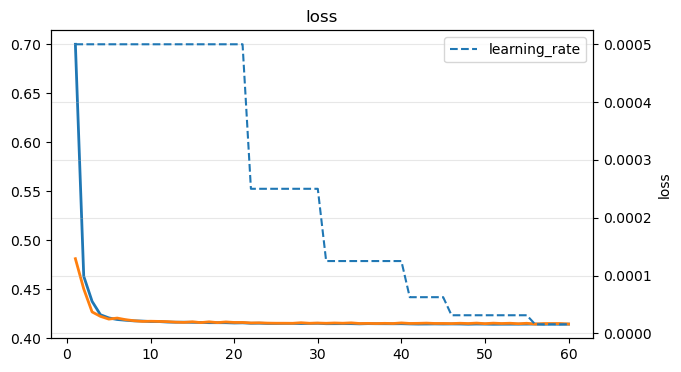

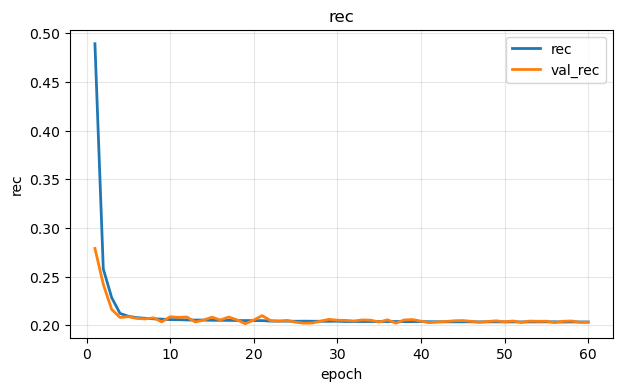

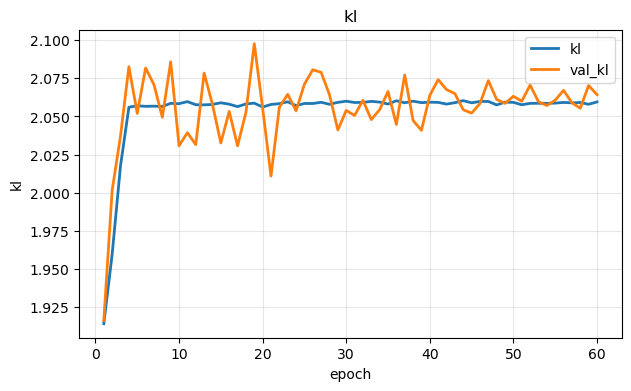

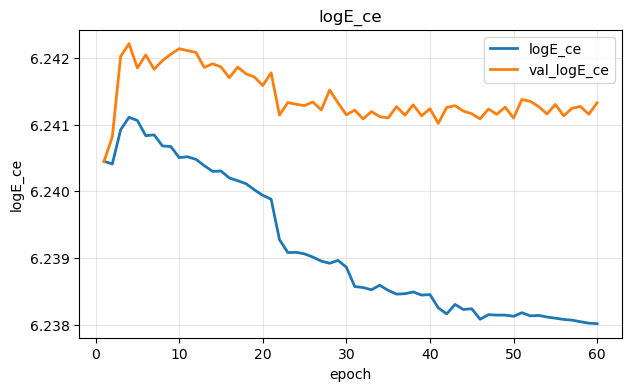

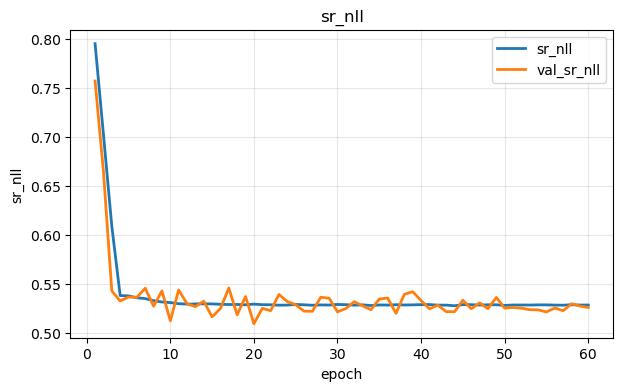

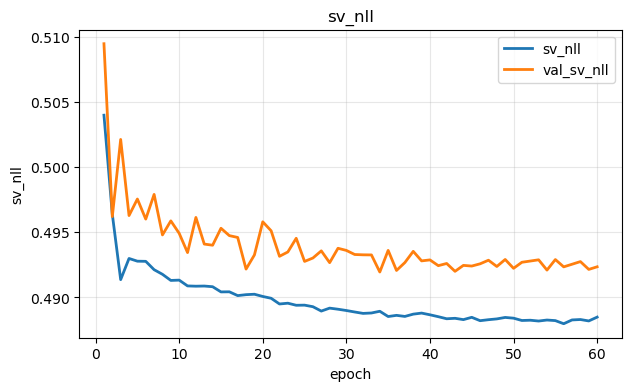

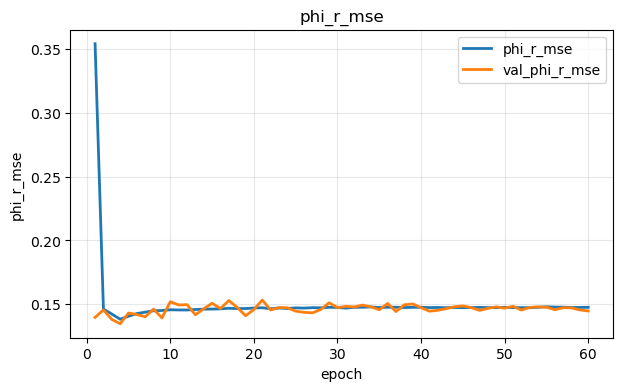

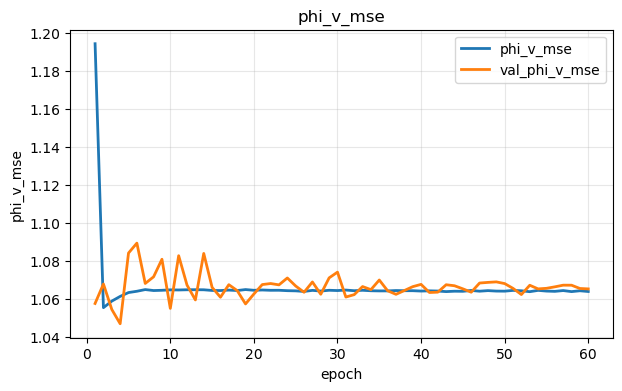

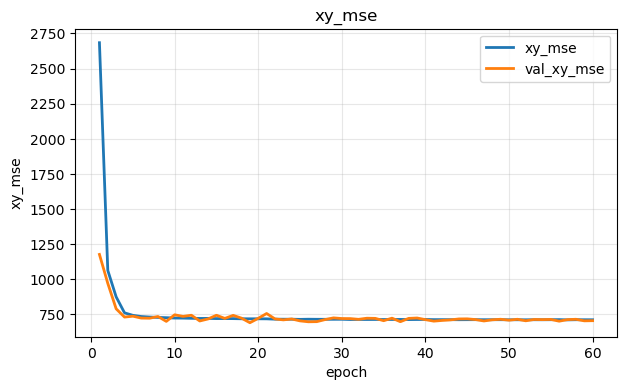

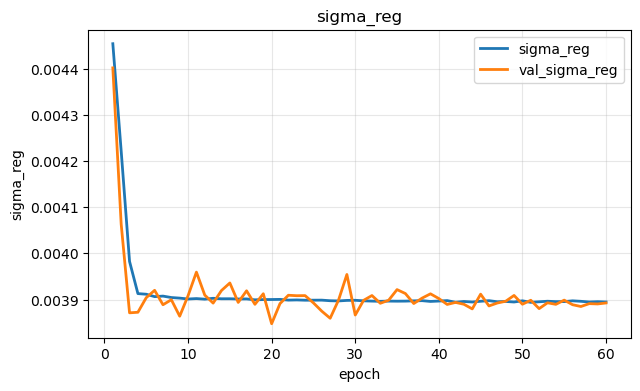

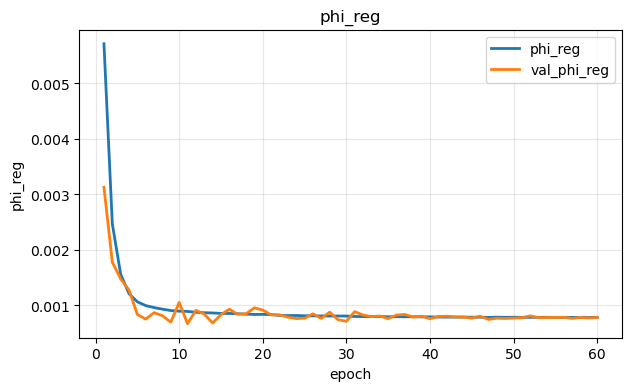

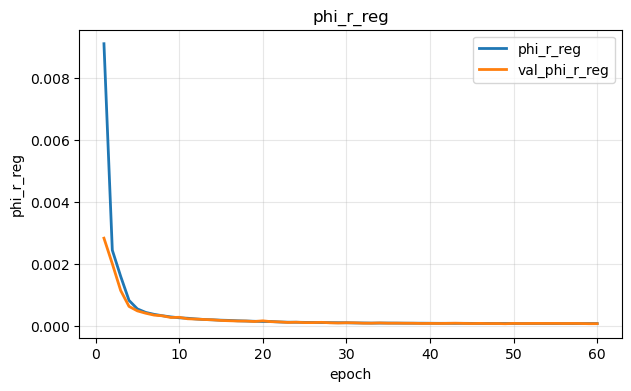

In [17]:
def plot_history(history, keys=None, show_available=True):
    h = history.history

    if show_available:
        print("\nAvailable history keys:")
        print(list(h.keys()))

    # ==========================================================
    # Metriche default per CVAE_CatLogE_GaussSV
    # ==========================================================
    if keys is None:
        keys = [
            "loss",
            "rec",
            "kl",

            # energia
            "logE_ce",

            # posizione polare
            "sr_nll",

            # direzione polare (ora su s_v)
            "sv_nll",

            # direzioni azimutali
            "phi_r_mse",
            "phi_v_mse",

            # loss geometrica
            "xy_mse",

            # regularizers
            "sigma_reg",
            "phi_reg",
            "phi_r_reg",
        ]

    # ==========================================================
    # numero epoche
    # ==========================================================
    if "loss" in h:
        n_ep = len(h["loss"])
    else:
        n_ep = len(next(iter(h.values())))

    epochs = np.arange(1, n_ep + 1)

    has_lr = ("learning_rate" in h)

    # ==========================================================
    # plotting
    # ==========================================================
    for k in keys:

        if k not in h:
            print("Metric not present:", k)
            continue

        plt.figure(figsize=(7, 4))

        plt.plot(
            epochs,
            h[k],
            label=k,
            linewidth=2
        )

        val_k = "val_" + k

        if val_k in h:
            plt.plot(
                epochs,
                h[val_k],
                label=val_k,
                linewidth=2
            )

        # learning rate solo sul grafico della loss
        if k == "loss" and has_lr:
            ax1 = plt.gca()
            ax2 = ax1.twinx()

            ax2.plot(
                epochs,
                h["learning_rate"],
                linestyle="--",
                label="learning_rate"
            )

            ax2.set_ylabel("learning_rate")
            ax2.legend(loc="upper right")

        plt.xlabel("epoch")
        plt.ylabel(k)
        plt.title(k)

        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.show()

# ==========================================================
# uso standard
# ==========================================================
plot_history(history)

### Confronto e Validazione

In [18]:
import numpy as np
import tensorflow as tf

def sample_types(n_samples, type_probs, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.choice(len(type_probs), size=n_samples, p=type_probs)
    return idx.astype(np.int32)

def one_hot_from_idx(idx, n_types):
    return tf.one_hot(idx, depth=n_types, dtype=tf.float32)

# ==========================================================
# Generazione tipi di particella
# ==========================================================
NGEN = len(X_test)   # confronto 1:1 col test set

gen_type_idx = sample_types(NGEN, type_probs)
gen_cond = one_hot_from_idx(gen_type_idx, n_types)

unique, counts = np.unique(gen_type_idx, return_counts=True)

print("\nGenerated particle counts:")
for u, c in zip(unique, counts):
    print(idx_to_type[u], c)

# ==========================================================
# Generazione feature nello spazio del training
# y_gen_scaled = [logE_s, s_r_s, cphi_r, sphi_r, s_v_s, cphi_v, sphi_v]
# ==========================================================
y_gen_scaled = model.generate_y(gen_cond, NGEN).numpy().astype(np.float32)

# ==========================================================
# Unscale delle feature scalate
# - col 0 = logE
# - col 1 = s_r
# - col 4 = s_v
# ==========================================================
y_gen = y_gen_scaled.copy()

# unscale logE
y_gen[:, 0] = y_gen_scaled[:, 0] * logE_std + logE_mean

# unscale s_r
y_gen[:, 1] = y_gen_scaled[:, 1] * s_r_std + s_r_mean

# unscale s_v
y_gen[:, 4] = y_gen_scaled[:, 4] * s_v_std + s_v_mean

# ==========================================================
# Energia fisica
# ==========================================================
E_gen = np.power(10.0, y_gen[:, 0], dtype=np.float32)

# ==========================================================
# Check fisico su u_v ricostruito da s_v
# ==========================================================
u_v_gen = np.tanh(y_gen[:, 4])

# ==========================================================
# Check rapidi
# ==========================================================
print("\n--- Generated feature ranges ---")
print("logE_gen min/max:", y_gen[:, 0].min(), y_gen[:, 0].max())
print("s_r_gen  min/max:", y_gen[:, 1].min(), y_gen[:, 1].max())
print("s_v_gen  min/max:", y_gen[:, 4].min(), y_gen[:, 4].max())
print("u_v_gen  min/max:", u_v_gen.min(), u_v_gen.max())
print("E_gen    min/max:", E_gen.min(), E_gen.max())

print("\nGenerated fractions by type:")
for u, c in zip(unique, counts):
    print(f"{idx_to_type[u]:>8s}: {c / NGEN:.6f}")


Generated particle counts:
gamma 294373
e- 5584
e+ 38
mu- 5

--- Generated feature ranges ---
logE_gen min/max: -0.6989699 -0.60206
s_r_gen  min/max: -7.7506475 15.566642
s_v_gen  min/max: -3.4655528 1.2701491
u_v_gen  min/max: -0.99804807 0.8538381
E_gen    min/max: 0.20000005 0.24999999

Generated fractions by type:
   gamma: 0.981243
      e-: 0.018613
      e+: 0.000127
     mu-: 0.000017


In [19]:
# Ricostruzione posizione e direzione da feature generate
C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-6

def renorm_cos_sin(c, s, eps=1e-12):
    r = np.sqrt(c*c + s*s) + eps
    return c/r, s/r

def u_from_s(s):
    # trasforma una variabile non limitata s in u in (-1, 1)
    return np.tanh(s)

# ==========================================================
# Estrai feature generate
# y = [logE, s_r, cphi_r, sphi_r, s_v, cphi_v, sphi_v]
# ==========================================================

s_r_gen = y_gen[:, 1]
u_r_gen = u_from_s(s_r_gen)

s_v_gen = y_gen[:, 4]
u_v_gen = u_from_s(s_v_gen)

# ==========================================================
# POSIZIONE su sfera
# ==========================================================

cpr_gen, spr_gen = renorm_cos_sin(y_gen[:, 2], y_gen[:, 3])
sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen * u_r_gen))

x_gen = C[0] + R * sin_tr_gen * cpr_gen
ypos_gen = C[1] + R * sin_tr_gen * spr_gen
z_gen = C[2] + R * u_r_gen

# ==========================================================
# DIREZIONE: (s_v, phi_v) -> u_v -> (vx, vy, vz)
# ==========================================================

# clip solo per sicurezza numerica dopo tanh
u_v_gen = np.clip(u_v_gen, -1.0 + eps, 1.0 - eps)

cpv_gen, spv_gen = renorm_cos_sin(y_gen[:, 5], y_gen[:, 6])
sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen * u_v_gen))

vx_gen = sin_tv_gen * cpv_gen
vy_gen = sin_tv_gen * spv_gen
vz_gen = u_v_gen

# ==========================================================
# Sanity check vincoli
# ==========================================================

rvec_gen = np.vstack([x_gen, ypos_gen, z_gen]).T - C[None, :]
r_gen = np.linalg.norm(rvec_gen, axis=1)

vnorm_gen_check = np.sqrt(vx_gen * vx_gen + vy_gen * vy_gen + vz_gen * vz_gen)

phi_r_norm = np.sqrt(cpr_gen * cpr_gen + spr_gen * spr_gen)
phi_v_norm = np.sqrt(cpv_gen * cpv_gen + spv_gen * spv_gen)

print("--- VINCOLI ---")
print("r_gen: mean", r_gen.mean(), "std", r_gen.std(), "min", r_gen.min(), "max", r_gen.max())
print("mean |r-R| =", np.mean(np.abs(r_gen - R)))

print("||v||: mean", vnorm_gen_check.mean(), "std", vnorm_gen_check.std(),
      "min", vnorm_gen_check.min(), "max", vnorm_gen_check.max())
print("mean ||v||-1| =", np.mean(np.abs(vnorm_gen_check - 1.0)))

print("phi_r norm: mean", phi_r_norm.mean(), "std", phi_r_norm.std(),
      "min", phi_r_norm.min(), "max", phi_r_norm.max())
print("phi_v norm: mean", phi_v_norm.mean(), "std", phi_v_norm.std(),
      "min", phi_v_norm.min(), "max", phi_v_norm.max())

print("E_gen: min", E_gen.min(), "max", E_gen.max())
print("u_r_gen min/max:", u_r_gen.min(), u_r_gen.max())
print("s_v_gen min/max:", s_v_gen.min(), s_v_gen.max())
print("u_v_gen min/max:", u_v_gen.min(), u_v_gen.max())
print("fraction u_v_gen > 0:", np.mean(u_v_gen > 0))

--- VINCOLI ---
r_gen: mean 99.99999999996336 std 3.3722804084360402e-06 min 99.99997809129859 max 100.00001712725486
mean |r-R| = 2.6447577505502312e-06
||v||: mean 1.0 std 2.9505202e-08 min 0.9999998 max 1.0000001
mean ||v||-1| = 1.3321638e-08
phi_r norm: mean 1.0 std 3.3864847e-08 min 0.9999998 max 1.0000001
phi_v norm: mean 1.0 std 3.266331e-08 min 0.9999999 max 1.0000001
E_gen: min 0.20000005 max 0.24999999
u_r_gen min/max: -0.99999964 1.0
s_v_gen min/max: -3.4655528 1.2701491
u_v_gen min/max: -0.99804807 0.8538381
fraction u_v_gen > 0: 0.04636


In [20]:
# ==========================================================
# Metriche di validazione su logE
# ==========================================================
from scipy.stats import ks_2samp, wasserstein_distance
import numpy as np

# ----------------------------------------------------------
# logE reale (test set) in scala fisica
# ----------------------------------------------------------
if "X_test_unscaled" in globals():
    logE_real_test = X_test_unscaled[:, 0].copy()
else:
    # fallback: ricostruzione da X_test_s
    logE_real_test = X_test_s[:, 0] * logE_std + logE_mean

# ----------------------------------------------------------
# logE generata (già riportata in scala fisica nella generazione)
# ----------------------------------------------------------
logE_gen = y_gen[:, 0]

# ----------------------------------------------------------
# Metriche globali
# ----------------------------------------------------------
ks_global = ks_2samp(logE_real_test, logE_gen).statistic
wd_global = wasserstein_distance(logE_real_test, logE_gen)

print("\n--- METRICHE logE globale ---")
print("KS(logE) =", ks_global)
print("Wasserstein(logE) =", wd_global)
print("logE real min/max:", logE_real_test.min(), logE_real_test.max())
print("logE gen  min/max:", logE_gen.min(), logE_gen.max())

# ----------------------------------------------------------
# Metriche per tipo
# ----------------------------------------------------------
def metrics_per_type(type_name):
    if type_name not in type_to_idx:
        return None

    t = type_to_idx[type_name]

    ref = logE_real_test[y_test == t]
    gen = logE_gen[gen_type_idx == t]

    if len(ref) < 50 or len(gen) < 50:
        return None

    ks = ks_2samp(ref, gen).statistic
    wd = wasserstein_distance(ref, gen)

    return {
        "type": type_name,
        "n_ref": len(ref),
        "n_gen": len(gen),
        "frac_ref": len(ref) / len(logE_real_test),
        "frac_gen": len(gen) / len(logE_gen),
        "ks": ks,
        "wd": wd,
    }

for tname in type_names:
    out = metrics_per_type(tname)

    if out is None:
        print(f"\nTipo {tname}: pochi eventi per metriche stabili.")
    else:
        print(f"\n--- {out['type']} ---")
        print("N_ref", out["n_ref"], "N_gen", out["n_gen"])
        print("frac_ref", out["frac_ref"], "frac_gen", out["frac_gen"])
        print("KS(logE)", out["ks"], "Wasserstein(logE)", out["wd"])


--- METRICHE logE globale ---
KS(logE) = 0.002106666666666701
Wasserstein(logE) = 6.49004962046941e-05
logE real min/max: -0.69897 -0.60206
logE gen  min/max: -0.6989699 -0.60206

--- gamma ---
N_ref 294342 N_gen 294373
frac_ref 0.98114 frac_gen 0.9812433333333334
KS(logE) 0.0021090422530646302 Wasserstein(logE) 6.384828989638899e-05

--- e- ---
N_ref 5623 N_gen 5584
frac_ref 0.018743333333333334 frac_gen 0.018613333333333332
KS(logE) 0.010436025136221628 Wasserstein(logE) 0.0002531302153629664

Tipo e+: pochi eventi per metriche stabili.

Tipo mu-: pochi eventi per metriche stabili.


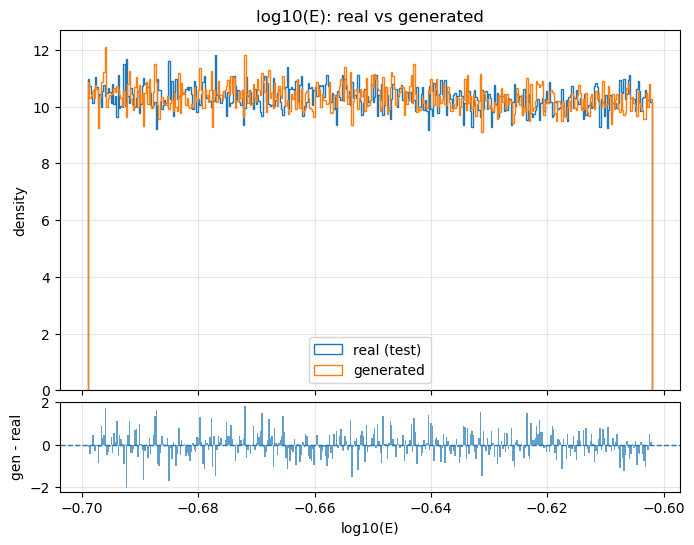

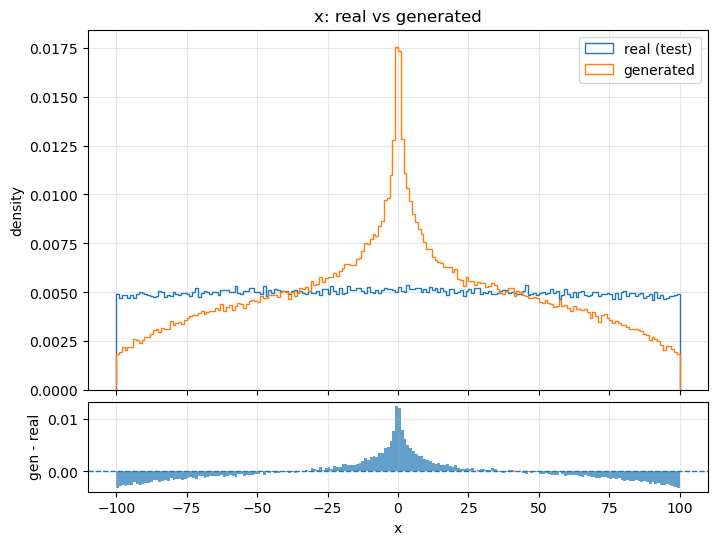

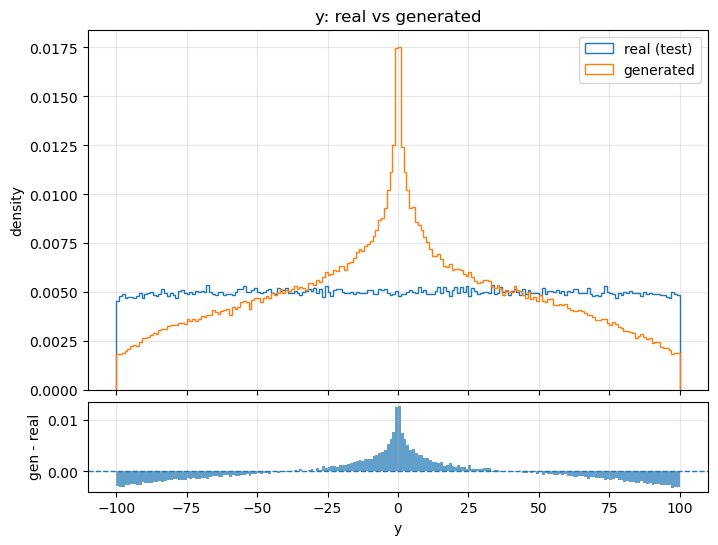

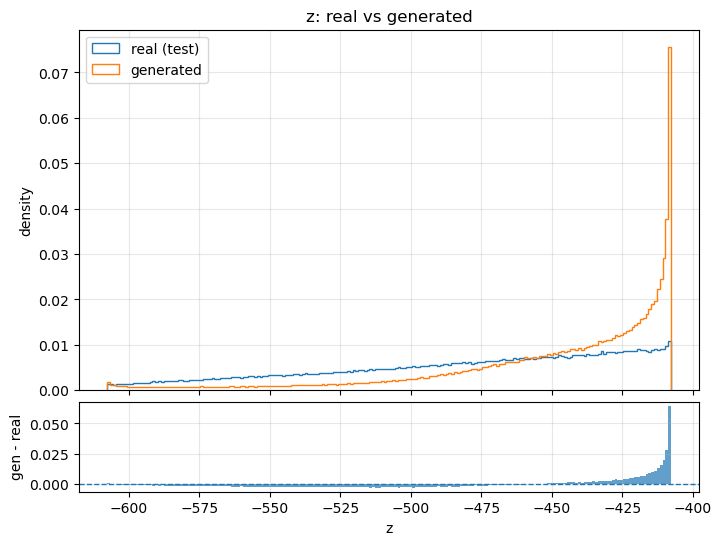

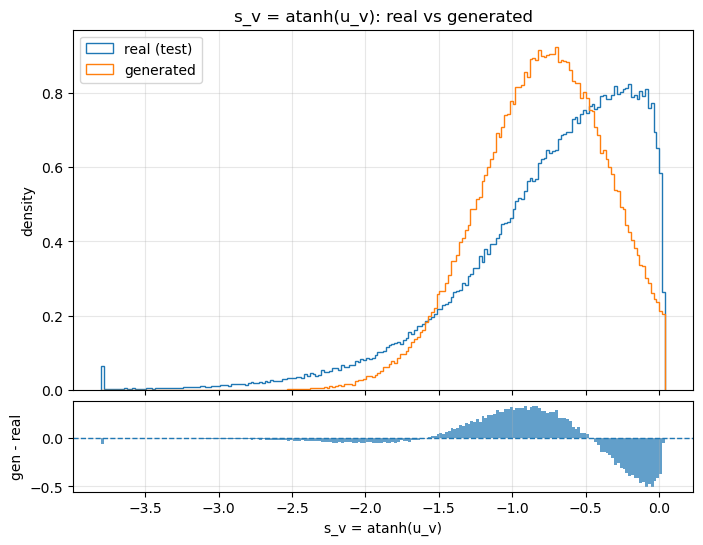

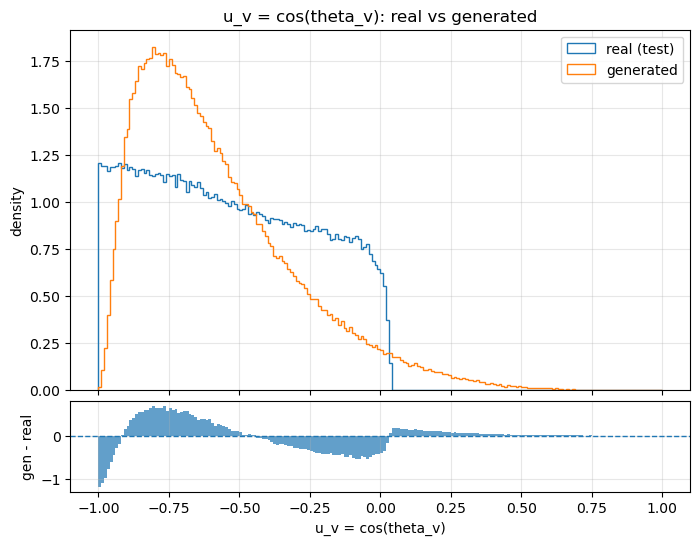

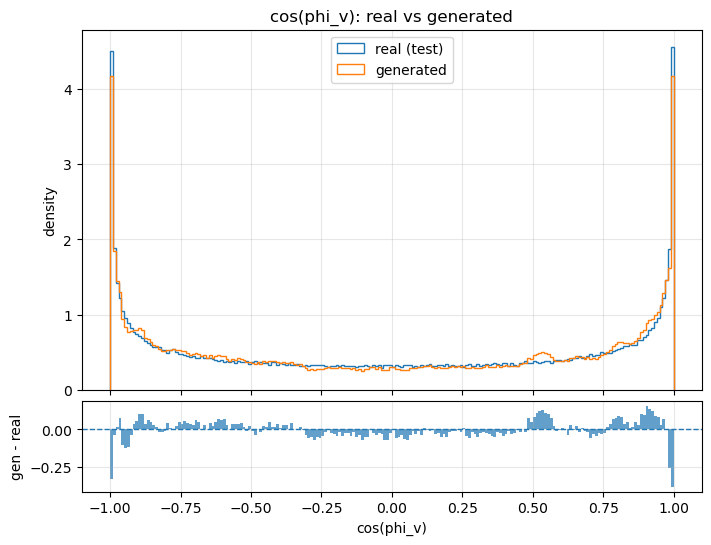

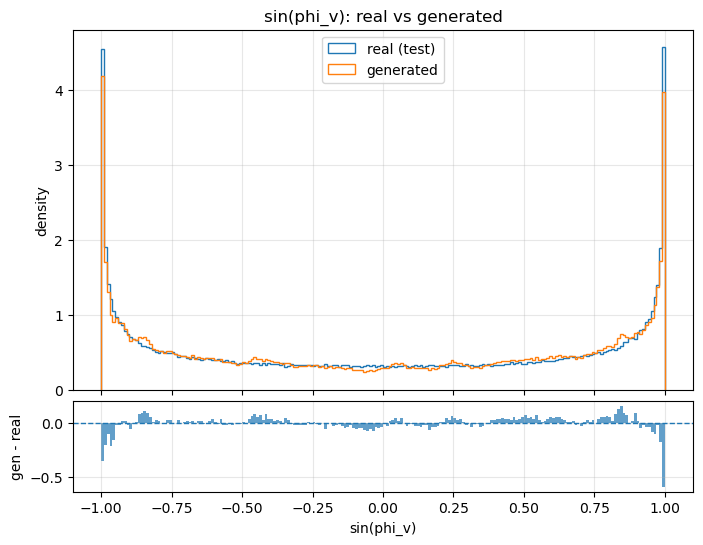

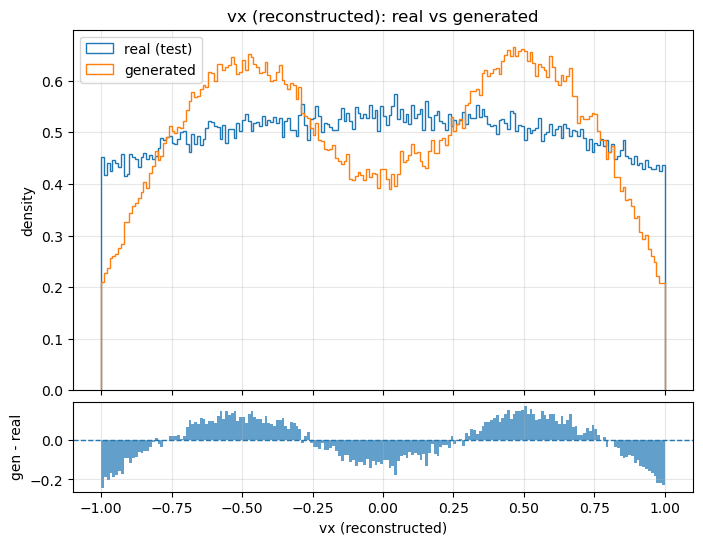

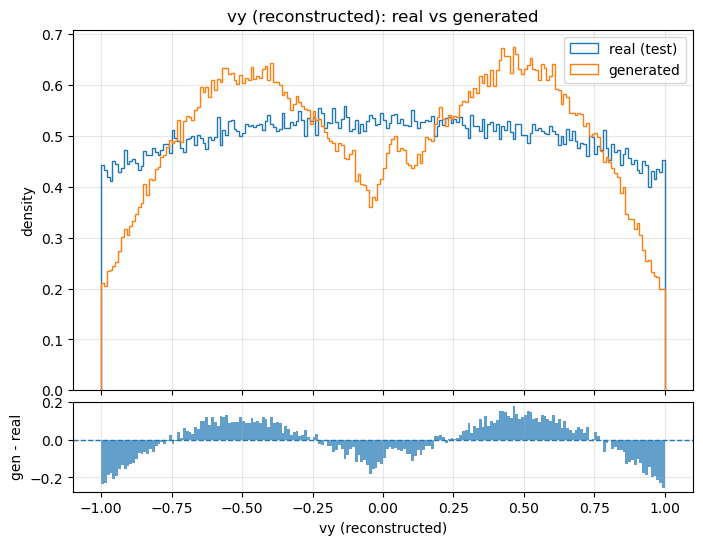

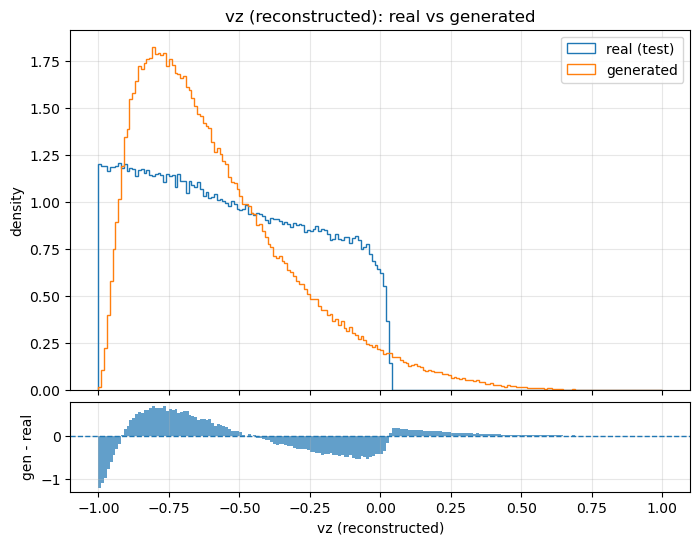


--- RANGE CHECK ---
logE real/gen: -0.69897 -0.60206 | -0.6989699 -0.60206
x real/gen: -99.99906158447266 99.99867248535156 | -99.99867248535156 99.99983215332031
y real/gen: -99.99974822998047 99.99991607666016 | -99.99908447265625 99.99651336669922
z real/gen: -607.560001525879 -407.7599984741211 | -607.6599618530274 -407.66
s_v real/gen: -3.8002012 0.03944363 | -3.4655528 1.2701491
u_v real/gen: -0.999 0.039423194 | -0.99804807 0.8538381
cos(phi_v) real/gen: -1.0 1.0 | -1.0 1.0
sin(phi_v) real/gen: -1.0 1.0 | -1.0 1.0
vx rec real/gen: -0.99999624 0.9999992 | -0.99997276 0.99998575
vy rec real/gen: -0.9999909 0.9999952 | -0.999997 0.99996245
vz rec real/gen: -0.999 0.039423194 | -0.99804807 0.8538381

--- COS/SIN NORM CHECK ---
phi_r real/gen: 1.0 1.0
phi_v real/gen: 1.0 1.0


In [21]:
eps = 1e-6

# ==========================================================
# DATI REALI (test) in scala fisica / feature non scalate
# layout: [logE, s_r, cphi_r, sphi_r, s_v, cphi_v, sphi_v]
# ==========================================================

# Usa direttamente la copia RAW costruita nella cella di split
# (se non esiste, fallback su X_test)
if "X_test_unscaled" in globals():
    X_real = X_test_unscaled.copy()
else:
    X_real = X_test.copy()

# -------------------------------
# Energia reale
# -------------------------------
logE_real_test = X_real[:, 0]

# -------------------------------
# Posizione reale
# -------------------------------
s_r_real = X_real[:, 1]
u_r_real = np.tanh(s_r_real)

cphi_r_real = X_real[:, 2].copy()
sphi_r_real = X_real[:, 3].copy()

norm_r = np.sqrt(cphi_r_real**2 + sphi_r_real**2) + 1e-12
cphi_r_real /= norm_r
sphi_r_real /= norm_r

sin_tr_real = np.sqrt(np.maximum(0.0, 1.0 - u_r_real**2))

x_real = C[0] + R * sin_tr_real * cphi_r_real
y_real = C[1] + R * sin_tr_real * sphi_r_real
z_real = C[2] + R * u_r_real

# -------------------------------
# Direzione reale
# -------------------------------
s_v_real = X_real[:, 4].copy()
u_v_real = np.tanh(s_v_real)
u_v_real = np.clip(u_v_real, -1.0 + eps, 1.0 - eps)

cphi_v_real = X_real[:, 5].copy()
sphi_v_real = X_real[:, 6].copy()

norm_v = np.sqrt(cphi_v_real**2 + sphi_v_real**2) + 1e-12
cphi_v_real /= norm_v
sphi_v_real /= norm_v

sin_tv_real = np.sqrt(np.maximum(0.0, 1.0 - u_v_real**2))
vx_real = sin_tv_real * cphi_v_real
vy_real = sin_tv_real * sphi_v_real
vz_real = u_v_real

vnorm_real = np.sqrt(vx_real**2 + vy_real**2 + vz_real**2) + 1e-12
vx_real /= vnorm_real
vy_real /= vnorm_real
vz_real /= vnorm_real

# ==========================================================
# DATI GENERATI
# y_gen layout: [logE, s_r, cphi_r, sphi_r, s_v, cphi_v, sphi_v]
# ==========================================================

logE_gen = y_gen[:, 0]

# -------------------------------
# Posizione generata
# -------------------------------
s_r_gen = y_gen[:, 1]
u_r_gen = np.tanh(s_r_gen)

cphi_r_gen = y_gen[:, 2].copy()
sphi_r_gen = y_gen[:, 3].copy()

norm_rg = np.sqrt(cphi_r_gen**2 + sphi_r_gen**2) + 1e-12
cphi_r_gen /= norm_rg
sphi_r_gen /= norm_rg

sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen**2))

x_gen = C[0] + R * sin_tr_gen * cphi_r_gen
ypos_gen = C[1] + R * sin_tr_gen * sphi_r_gen
z_gen = C[2] + R * u_r_gen

# -------------------------------
# Direzione generata
# -------------------------------
s_v_gen = y_gen[:, 4].copy()
u_v_gen = np.tanh(s_v_gen)
u_v_gen = np.clip(u_v_gen, -1.0 + eps, 1.0 - eps)

cphi_v_gen = y_gen[:, 5].copy()
sphi_v_gen = y_gen[:, 6].copy()

norm_vg = np.sqrt(cphi_v_gen**2 + sphi_v_gen**2) + 1e-12
cphi_v_gen /= norm_vg
sphi_v_gen /= norm_vg

sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen**2))
vx_gen_rec = sin_tv_gen * cphi_v_gen
vy_gen_rec = sin_tv_gen * sphi_v_gen
vz_gen = u_v_gen

vnorm_gen = np.sqrt(vx_gen_rec**2 + vy_gen_rec**2 + vz_gen**2) + 1e-12
vx_gen_rec /= vnorm_gen
vy_gen_rec /= vnorm_gen
vz_gen /= vnorm_gen

# ==========================================================
# FUNZIONE PLOT CON PANNELLO RESIDUI
# ==========================================================
def compare_hist_with_residuals(real, gen, name, bins=200, range_=None,
                                residual_mode="diff", eps_res=1e-12):
    """
    residual_mode:
      - "diff"    -> gen_density - real_density
      - "ratio-1" -> gen_density / real_density - 1
    """
    real = np.asarray(real)
    gen = np.asarray(gen)

    # istogrammi con stessi bin
    real_hist, bin_edges = np.histogram(real, bins=bins, range=range_, density=True)
    gen_hist, _          = np.histogram(gen,  bins=bin_edges, density=True)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)

    if residual_mode == "ratio-1":
        residuals = gen_hist / np.maximum(real_hist, eps_res) - 1.0
        resid_ylabel = "(gen/real) - 1"
    else:
        residuals = gen_hist - real_hist
        resid_ylabel = "gen - real"

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(8, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05}
    )

    # pannello superiore
    ax_top.hist(real, bins=bin_edges, density=True, histtype="step", label="real (test)")
    ax_top.hist(gen,  bins=bin_edges, density=True, histtype="step", label="generated")
    ax_top.set_ylabel("density")
    ax_top.set_title(f"{name}: real vs generated")
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)

    # pannello residui
    ax_bot.axhline(0.0, linestyle="--", linewidth=1)
    ax_bot.bar(bin_centers, residuals, width=bin_widths, align="center", alpha=0.7)
    ax_bot.set_xlabel(name)
    ax_bot.set_ylabel(resid_ylabel)
    ax_bot.grid(True, alpha=0.3)

    plt.show()

# ==========================================================
# PLOT: Energia
# ==========================================================
compare_hist_with_residuals(logE_real_test, logE_gen, "log10(E)", bins=400)

# ==========================================================
# PLOT: Posizione ricostruita
# ==========================================================
compare_hist_with_residuals(x_real, x_gen, "x")
compare_hist_with_residuals(y_real, ypos_gen, "y")
compare_hist_with_residuals(z_real, z_gen, "z")

# ==========================================================
# PLOT: Direzione - FEATURE
# ==========================================================
compare_hist_with_residuals(s_v_real,    s_v_gen,    "s_v = atanh(u_v)")
compare_hist_with_residuals(u_v_real,    u_v_gen,    "u_v = cos(theta_v)", range_=(-1, 1))
compare_hist_with_residuals(cphi_v_real, cphi_v_gen, "cos(phi_v)",         range_=(-1, 1))
compare_hist_with_residuals(sphi_v_real, sphi_v_gen, "sin(phi_v)",         range_=(-1, 1))

# ==========================================================
# PLOT: Direzione - CARTESIANA ricostruita
# ==========================================================
compare_hist_with_residuals(vx_real, vx_gen_rec, "vx (reconstructed)", range_=(-1, 1))
compare_hist_with_residuals(vy_real, vy_gen_rec, "vy (reconstructed)", range_=(-1, 1))
compare_hist_with_residuals(vz_real, vz_gen,     "vz (reconstructed)", range_=(-1, 1))

# ==========================================================
# RANGE CHECK
# ==========================================================
print("\n--- RANGE CHECK ---")
print("logE real/gen:", logE_real_test.min(), logE_real_test.max(), "|", logE_gen.min(), logE_gen.max())

print("x real/gen:", x_real.min(), x_real.max(), "|", x_gen.min(), x_gen.max())
print("y real/gen:", y_real.min(), y_real.max(), "|", ypos_gen.min(), ypos_gen.max())
print("z real/gen:", z_real.min(), z_real.max(), "|", z_gen.min(), z_gen.max())

print("s_v real/gen:", s_v_real.min(), s_v_real.max(), "|", s_v_gen.min(), s_v_gen.max())
print("u_v real/gen:", u_v_real.min(), u_v_real.max(), "|", u_v_gen.min(), u_v_gen.max())

print("cos(phi_v) real/gen:", cphi_v_real.min(), cphi_v_real.max(), "|", cphi_v_gen.min(), cphi_v_gen.max())
print("sin(phi_v) real/gen:", sphi_v_real.min(), sphi_v_real.max(), "|", sphi_v_gen.min(), sphi_v_gen.max())

print("vx rec real/gen:", vx_real.min(), vx_real.max(), "|", vx_gen_rec.min(), vx_gen_rec.max())
print("vy rec real/gen:", vy_real.min(), vy_real.max(), "|", vy_gen_rec.min(), vy_gen_rec.max())
print("vz rec real/gen:", vz_real.min(), vz_real.max(), "|", vz_gen.min(), vz_gen.max())

# check norme cos/sin
norm_phi_r_real = np.sqrt(cphi_r_real**2 + sphi_r_real**2)
norm_phi_r_gen  = np.sqrt(cphi_r_gen**2  + sphi_r_gen**2)
norm_phi_v_real = np.sqrt(cphi_v_real**2 + sphi_v_real**2)
norm_phi_v_gen  = np.sqrt(cphi_v_gen**2  + sphi_v_gen**2)

print("\n--- COS/SIN NORM CHECK ---")
print("phi_r real/gen:", norm_phi_r_real.mean(), norm_phi_r_gen.mean())
print("phi_v real/gen:", norm_phi_v_real.mean(), norm_phi_v_gen.mean())

## Versione 1.3.tv
Introduco il parametro $t_v$ per smussare l'andamento brutto di $s_v$.

$t_v = sign(s_v)\log(1+|s_v|)$

$s_v = sign(t_v)e^{|t_v|-1}$

### Preprocessing


--- Controllo sfera RAW (r = ||x-C||) ---
r: mean = 99.23411918434232  std = 0.40461867908293037  min = 98.93981564523723  max = 100.06006989051981
Deviazione media da R: 0.7682885734999307

--- Controllo norma direzione RAW (||v||) ---
||v||: mean = 0.9999999998903653  std = 2.88613664129066e-07  min = 0.9999991604741476  max = 1.0000008313726545
Deviazione media da 1: 2.402573376849245e-07

--- Controllo energia ---
E: min = 0.0011044  max = 1.46082  #E<=0 = 0

--- Controllo sfera PROIETTATA ---
r_proj: mean = 99.99999999999902  std = 2.2897201782837348e-14  min = 99.99999999999896  max = 99.99999999999903
Deviazione media da R: 1.0007113932897926e-12

--- Controllo direzione RINORMALIZZATA ---
||vhat||: mean = 0.9999999999990034  std = 3.408393483818028e-15  min = 0.9999999999989996  max = 0.9999999999990002
Deviazione media da 1: 1.0000542428995967e-12


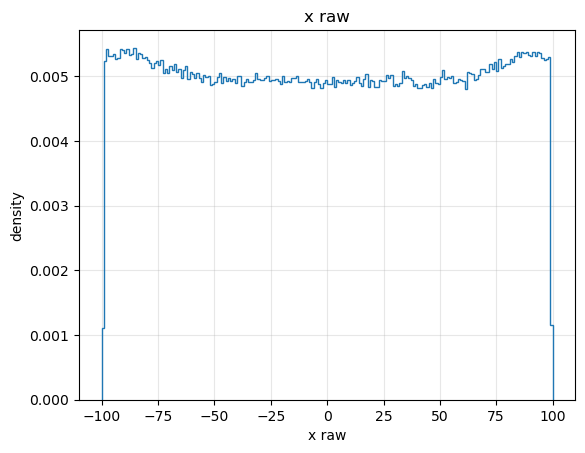

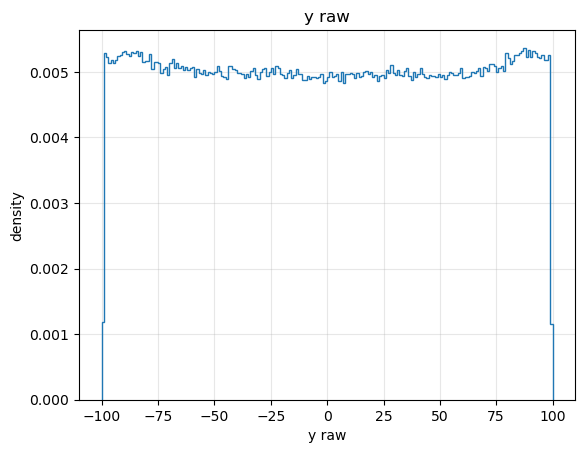

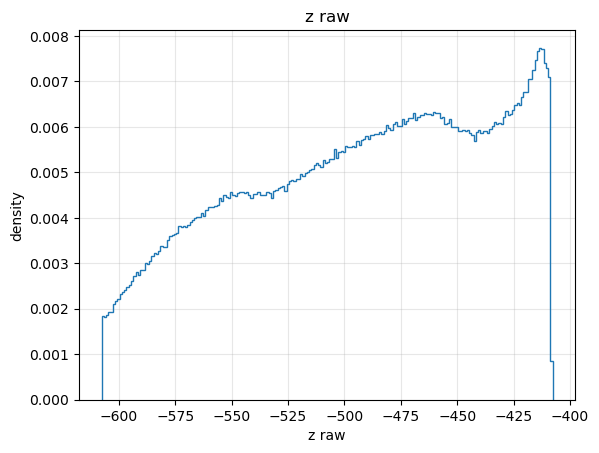

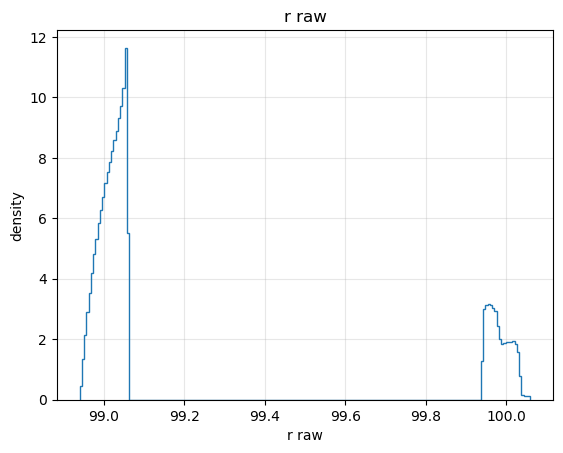

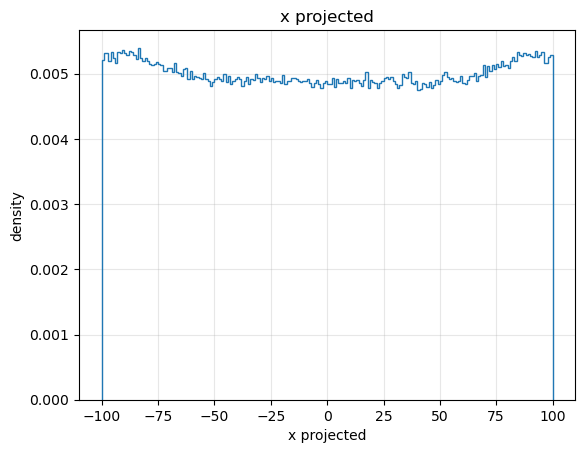

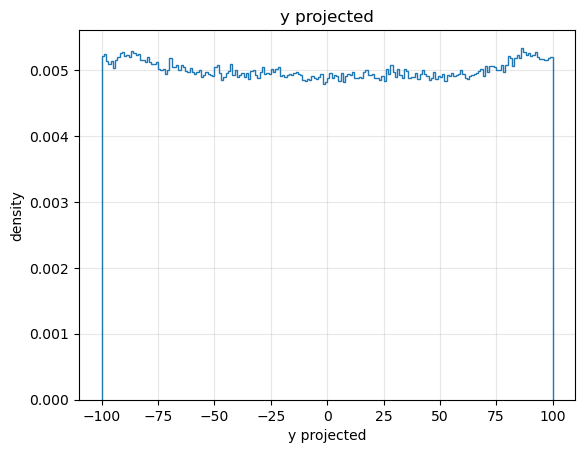

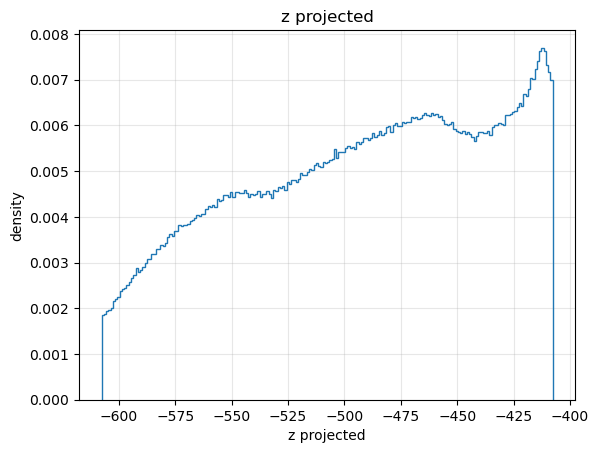

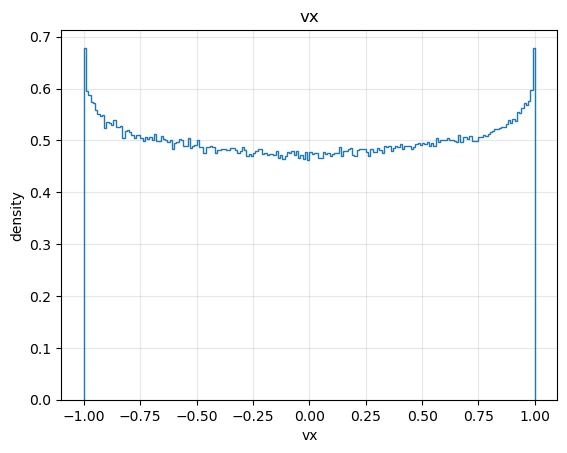

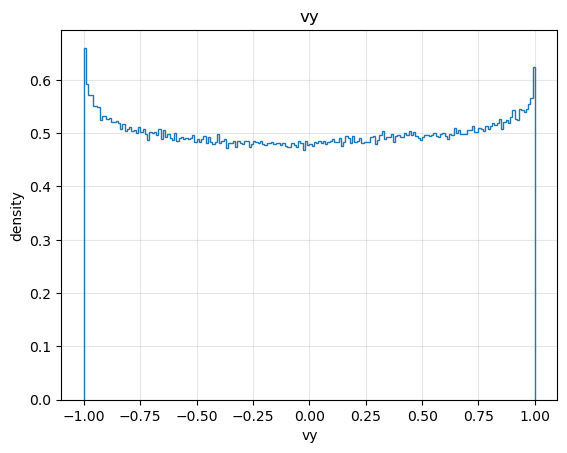

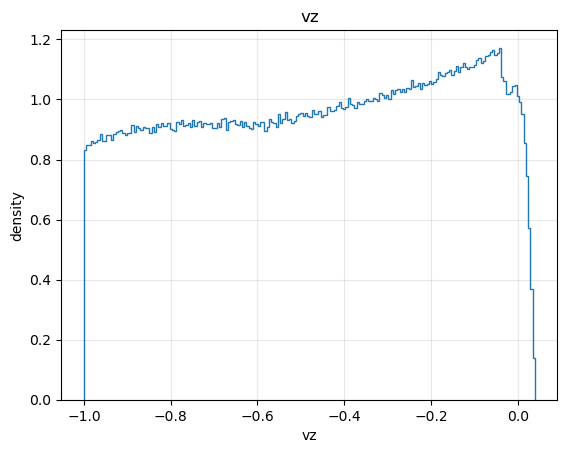

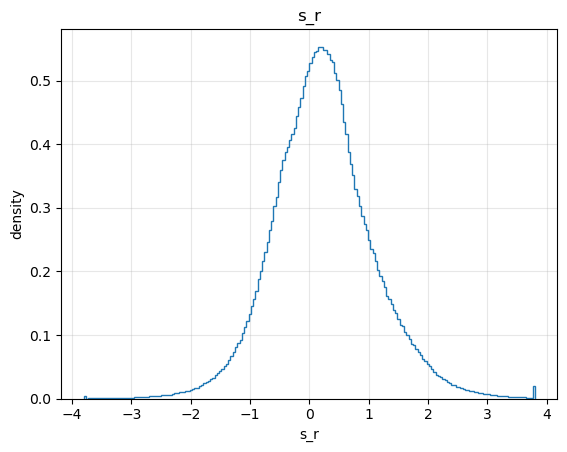

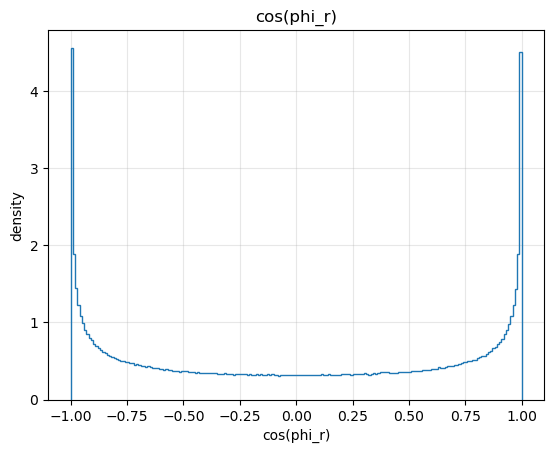

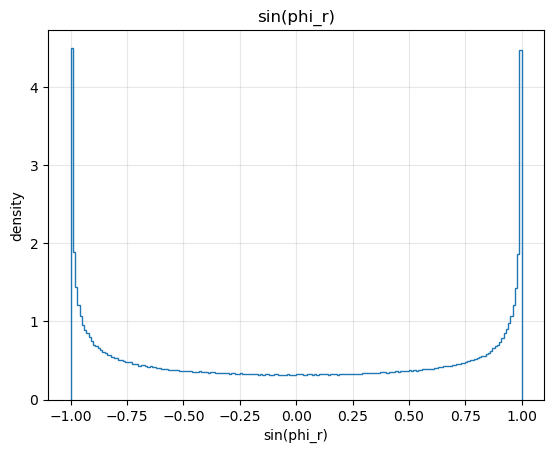

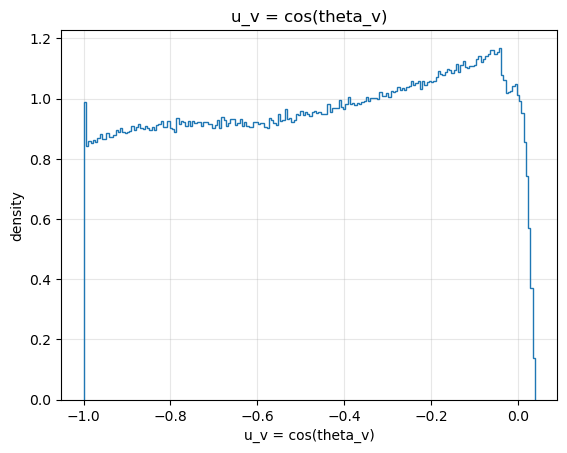

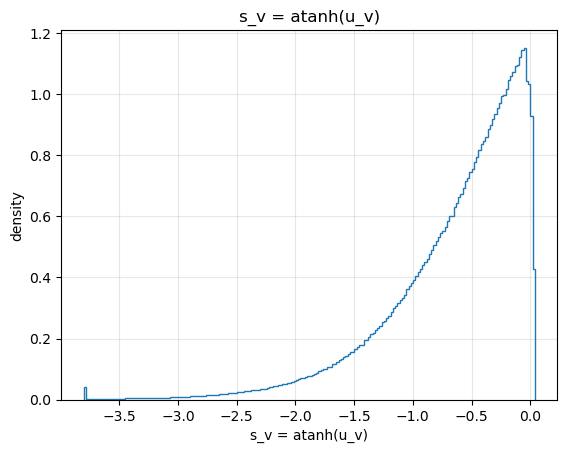

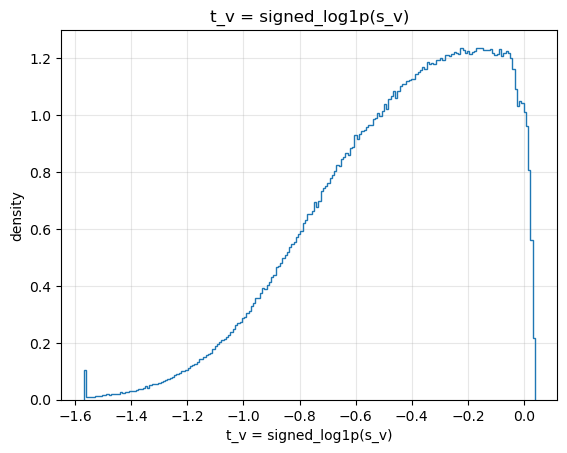

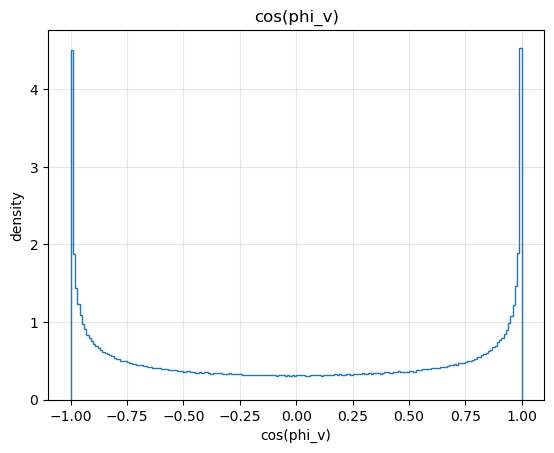

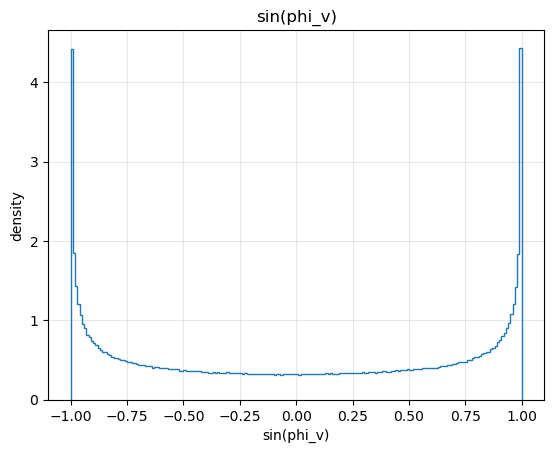


--- Check u_v / s_v / t_v ---
u_v: min = -0.999 max = 0.039454388658001965 fraction u_v > 0 = 0.027152410134665236
s_v: min = -3.8002011672501994 max = 0.03947488000882558 mean = -0.6355732574153312 std = 0.5702215944194755
t_v: min = -1.5686578268794438 max = 0.03871566256826599 mean = -0.44040760089239034 std = 0.3111690348281911

--- Check inversione signed-log ---
max |s_v_back - s_v| = 4.440892098500626e-16
max |u_v_back - u_v| = 1.1102230246251565e-16


In [ ]:
C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-3   # robusto vicino ai bordi per atanh

xyz = Data_K40[["X", "Y", "Z"]].to_numpy(dtype=np.float64)
v   = Data_K40[["Vx", "Vy", "Vz"]].to_numpy(dtype=np.float64)
E   = Data_K40["Energy"].to_numpy(dtype=np.float64)

x = xyz[:, 0]
y = xyz[:, 1]
z = xyz[:, 2]

vx = v[:, 0]
vy = v[:, 1]
vz = v[:, 2]

# =========================
# Trasformazioni signed-log per s_v
# =========================

def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

# =========================
# Controlli fisici iniziali
# =========================

rvec = xyz - C[None, :]
r = np.linalg.norm(rvec, axis=1)
vnorm = np.linalg.norm(v, axis=1)

print("\n--- Controllo sfera RAW (r = ||x-C||) ---")
print("r: mean =", r.mean(), " std =", r.std(), " min =", r.min(), " max =", r.max())
print("Deviazione media da R:", np.mean(np.abs(r - R)))

print("\n--- Controllo norma direzione RAW (||v||) ---")
print("||v||: mean =", vnorm.mean(), " std =", vnorm.std(), " min =", vnorm.min(), " max =", vnorm.max())
print("Deviazione media da 1:", np.mean(np.abs(vnorm - 1.0)))

print("\n--- Controllo energia ---")
print("E: min =", E.min(), " max =", E.max(), " #E<=0 =", np.sum(E <= 0))

# =========================
# Filtro su energia valida
# =========================

mask_posE = (E > 0) & np.isfinite(E)
if not mask_posE.all():
    print(f"\nRimuovo {np.sum(~mask_posE)} righe con E<=0 o non finita.")
    Data_K40 = Data_K40.loc[mask_posE].reset_index(drop=True)

    xyz = Data_K40[["X", "Y", "Z"]].to_numpy(dtype=np.float64)
    v   = Data_K40[["Vx", "Vy", "Vz"]].to_numpy(dtype=np.float64)
    E   = Data_K40["Energy"].to_numpy(dtype=np.float64)

    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    vx = v[:, 0]
    vy = v[:, 1]
    vz = v[:, 2]

    rvec = xyz - C[None, :]
    r = np.linalg.norm(rvec, axis=1)
    vnorm = np.linalg.norm(v, axis=1)

# =========================
# REGOLARIZZAZIONE POSIZIONE:
# proiezione di tutti i punti sulla sfera di raggio R
# =========================

rhat = rvec / (r[:, None] + 1e-12)
rvec_proj = R * rhat
xyz_proj = C[None, :] + rvec_proj

x_proj = xyz_proj[:, 0]
y_proj = xyz_proj[:, 1]
z_proj = xyz_proj[:, 2]

# check dopo proiezione
r_proj = np.linalg.norm(rvec_proj, axis=1)
print("\n--- Controllo sfera PROIETTATA ---")
print("r_proj: mean =", r_proj.mean(), " std =", r_proj.std(), " min =", r_proj.min(), " max =", r_proj.max())
print("Deviazione media da R:", np.mean(np.abs(r_proj - R)))

# =========================
# REGOLARIZZAZIONE DIREZIONE:
# rinormalizzo per sicurezza numerica
# =========================

vhat = v / (vnorm[:, None] + 1e-12)

vx_hat = vhat[:, 0]
vy_hat = vhat[:, 1]
vz_hat = vhat[:, 2]

vnorm_hat = np.linalg.norm(vhat, axis=1)
print("\n--- Controllo direzione RINORMALIZZATA ---")
print("||vhat||: mean =", vnorm_hat.mean(), " std =", vnorm_hat.std(), " min =", vnorm_hat.min(), " max =", vnorm_hat.max())
print("Deviazione media da 1:", np.mean(np.abs(vnorm_hat - 1.0)))

# =========================
# COSTRUZIONE FEATURE
# x = [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# dove:
#   u_v = cos(theta_v)
#   s_v = atanh(u_v)
#   t_v = sign(s_v) * log(1 + |s_v|)
# =========================

# -------------------------
# posizione dalla sfera proiettata
# -------------------------
u_r = np.clip(rhat[:, 2], -1.0 + eps, 1.0 - eps)
s_r = np.arctanh(u_r)

phi_r = np.arctan2(rhat[:, 1], rhat[:, 0])
cphi_r = np.cos(phi_r)
sphi_r = np.sin(phi_r)

# -------------------------
# direzione dal vettore rinormalizzato
# -------------------------
u_v = vz_hat #np.clip(vz_hat, -1.0 + eps, 1.0 - eps)
s_v = np.arctanh(u_v)

# nuova trasformazione smooth/compressa
t_v = signed_log1p(s_v)

phi_v = np.arctan2(vy_hat, vx_hat)
cphi_v = np.cos(phi_v)
sphi_v = np.sin(phi_v)

# energia
logE = np.log10(E)

# =========================
# Funzione per plot
# =========================

def plot_dist(data, name, bins=200):
    plt.figure()
    plt.hist(data, bins=bins, density=True, histtype="step")
    plt.xlabel(name)
    plt.ylabel("density")
    plt.title(name)
    plt.grid(True, alpha=0.3)
    plt.show()

# =========================
# Plot posizione RAW
# =========================

plot_dist(x, "x raw")
plot_dist(y, "y raw")
plot_dist(z, "z raw")
plot_dist(r, "r raw")

# =========================
# Plot posizione PROIETTATA
# =========================

plot_dist(x_proj, "x projected")
plot_dist(y_proj, "y projected")
plot_dist(z_proj, "z projected")
# plot_dist(r_proj, "r projected")

# =========================
# Plot direzioni
# =========================

plot_dist(vx_hat, "vx")
plot_dist(vy_hat, "vy")
plot_dist(vz_hat, "vz")

# =========================
# Plot feature posizione
# =========================

plot_dist(s_r, "s_r")
plot_dist(cphi_r, "cos(phi_r)")
plot_dist(sphi_r, "sin(phi_r)")

# =========================
# Plot feature direzione
# =========================

plot_dist(u_v, "u_v = cos(theta_v)")
plot_dist(s_v, "s_v = atanh(u_v)")
plot_dist(t_v, "t_v = signed_log1p(s_v)")
plot_dist(cphi_v, "cos(phi_v)")
plot_dist(sphi_v, "sin(phi_v)")

# =========================
# Check utili su u_v / s_v / t_v
# =========================

# inversione per controllo numerico
s_v_back = signed_expm1(t_v)
u_v_back = np.tanh(s_v_back)

print("\n--- Check u_v / s_v / t_v ---")
print("u_v: min =", u_v.min(), "max =", u_v.max(), "fraction u_v > 0 =", np.mean(u_v > 0))
print("s_v: min =", s_v.min(), "max =", s_v.max(), "mean =", s_v.mean(), "std =", s_v.std())
print("t_v: min =", t_v.min(), "max =", t_v.max(), "mean =", t_v.mean(), "std =", t_v.std())

print("\n--- Check inversione signed-log ---")
print("max |s_v_back - s_v| =", np.max(np.abs(s_v_back - s_v)))
print("max |u_v_back - u_v| =", np.max(np.abs(u_v_back - u_v)))

In [164]:
# ==========================================================
# Costruzione dataframe finale delle feature
# Ora usiamo:
#   u_v = cos(theta_v)
#   s_v = atanh(u_v)
#   t_v = sign(s_v) * log(1 + |s_v|)
#
# Feature finali:
# [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

# log energia
logE = np.log10(E)

# dataframe finale
feat = pd.DataFrame({
    "ParticleName": Data_K40["ParticleName"].astype(str).to_numpy(),
    "logE":   logE.astype(np.float32),
    "s_r":    s_r.astype(np.float32),
    "cphi_r": cphi_r.astype(np.float32),
    "sphi_r": sphi_r.astype(np.float32),
    "t_v":    t_v.astype(np.float32),
    "cphi_v": cphi_v.astype(np.float32),
    "sphi_v": sphi_v.astype(np.float32),
})

print("feat shape:", feat.shape)

print("\nPrime righe:")
display(feat.head())

# ==========================================================
# Check finitezza
# ==========================================================

print("\n--- Check finitezza ---")

arr = feat[["logE", "s_r", "cphi_r", "sphi_r", "t_v", "cphi_v", "sphi_v"]].to_numpy()
bad = ~np.isfinite(arr).all(axis=1)

print("Righe con NaN/Inf:", np.sum(bad))

# ==========================================================
# Range feature
# ==========================================================

print("\n--- Range feature ---")

for c in ["logE", "s_r", "cphi_r", "sphi_r", "t_v", "cphi_v", "sphi_v"]:
    print(f"{c:>8s} : {feat[c].min()}  {feat[c].max()}")

# ==========================================================
# Check cerchi unitari
# ==========================================================

print("\n--- Check cerchi unitari ---")

cr = np.sqrt(feat["cphi_r"].to_numpy()**2 + feat["sphi_r"].to_numpy()**2)
cv = np.sqrt(feat["cphi_v"].to_numpy()**2 + feat["sphi_v"].to_numpy()**2)

print("pos: mean =", cr.mean(), "std =", cr.std(), "min =", cr.min(), "max =", cr.max())
print("dir: mean =", cv.mean(), "std =", cv.std(), "min =", cv.min(), "max =", cv.max())

# ==========================================================
# Check direzione fisica ricostruita
# t_v -> s_v -> u_v
# ==========================================================

print("\n--- Check u_v ricostruito ---")

s_v_check = signed_expm1(feat["t_v"].to_numpy())
u_v_check = np.tanh(s_v_check)

print("u_v: min =", u_v_check.min(), "max =", u_v_check.max())
print("fraction u_v > 0 =", np.mean(u_v_check > 0))

# ==========================================================
# Check distribuzione t_v
# ==========================================================

print("\n--- Check t_v ---")

print("t_v mean =", feat["t_v"].mean())
print("t_v std  =", feat["t_v"].std())
print("t_v min/max =", feat["t_v"].min(), feat["t_v"].max())

# ==========================================================
# Check distribuzione s_v ricostruita
# ==========================================================

print("\n--- Check s_v ricostruito da t_v ---")

print("s_v mean =", s_v_check.mean())
print("s_v std  =", s_v_check.std())
print("s_v min/max =", s_v_check.min(), s_v_check.max())

# ==========================================================
# Check inversione numerica
# ==========================================================

print("\n--- Check inversione t_v -> s_v -> u_v ---")
print("max |s_v_check - s_v| =", np.max(np.abs(s_v_check - s_v)))
print("max |u_v_check - u_v| =", np.max(np.abs(u_v_check - u_v)))

feat shape: (1873609, 8)

Prime righe:


,ParticleName,logE,s_r,cphi_r,sphi_r,t_v,cphi_v,sphi_v
0,gamma,-0.823125,0.358586,0.210977,0.977491,-0.093188,0.097358,-0.995249
1,gamma,-1.038010,0.474478,-0.358955,-0.933355,-0.318245,0.978114,0.208069
2,gamma,-0.944515,0.274716,0.994918,0.100693,-0.364662,-0.186496,0.982456
3,gamma,-0.515061,1.214620,-0.877904,-0.478836,-0.344266,0.756988,-0.653428
4,gamma,-0.587246,-0.314929,0.231329,0.972875,-0.342467,-0.725534,-0.688187



--- Check finitezza ---
Righe con NaN/Inf: 0

--- Range feature ---
    logE : -2.956873655319214  0.16459670662879944
     s_r : -3.800201177597046  3.800201177597046
  cphi_r : -1.0  1.0
  sphi_r : -1.0  1.0
     t_v : -1.5686578750610352  0.0387156642973423
  cphi_v : -1.0  1.0
  sphi_v : -1.0  1.0

--- Check cerchi unitari ---
pos: mean = 1.0 std = 2.5750039e-08 min = 0.99999994 max = 1.0
dir: mean = 1.0 std = 2.5729706e-08 min = 0.99999994 max = 1.0

--- Check u_v ricostruito ---
u_v: min = -0.999 max = 0.03945439
fraction u_v > 0 = 0.027152410134665236

--- Check t_v ---
t_v mean = -0.44040784
t_v std  = 0.31116912
t_v min/max = -1.5686579 0.038715664

--- Check s_v ricostruito da t_v ---
s_v mean = -0.6355731
s_v std  = 0.5702215
s_v min/max = -3.8002014 0.039474882

--- Check inversione t_v -> s_v -> u_v ---
max |s_v_check - s_v| = 3.894143381089066e-07
max |u_v_check - u_v| = 1.034359070617441e-07


### Standardizzazione

In [165]:
# ==========================================================
# Filter rare particle types + build RAW feature matrix
# Features:
# [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

prob_threshold = 1e-5

# ----------------------------------------------------------
# 1) Filter rare particle types
# ----------------------------------------------------------
type_counts_full = feat["ParticleName"].value_counts()
type_probs_full = type_counts_full / type_counts_full.sum()

valid_types = type_probs_full[type_probs_full >= prob_threshold].index

print("Original particle types:", len(type_counts_full))
print("Keeping particle types:", len(valid_types))
print("Dropping rare types:", len(type_counts_full) - len(valid_types))

feat = feat[feat["ParticleName"].isin(valid_types)].reset_index(drop=True)

# Recompute counts after filtering
type_counts = feat["ParticleName"].value_counts()
type_names = type_counts.index.to_list()
n_types = len(type_names)

type_to_idx = {t: i for i, t in enumerate(type_names)}
idx_to_type = {i: t for t, i in type_to_idx.items()}

type_probs = (type_counts / type_counts.sum()).to_numpy(dtype=np.float64)

print("\nNumero tipi:", n_types)
print("Tipi:", type_names)

print("\nProbabilità empiriche:")
for t, p in zip(type_names, type_probs):
    print(f"{t:>12s}  p={p:.6e}")

# ----------------------------------------------------------
# 2) Build RAW feature matrix
# ----------------------------------------------------------
cont_cols = ["logE", "s_r", "cphi_r", "sphi_r", "t_v", "cphi_v", "sphi_v"]

X_raw = feat[cont_cols].to_numpy(dtype=np.float32)

# Labels as integer indices
y_type = feat["ParticleName"].map(type_to_idx).to_numpy(dtype=np.int32)

print("\nX_raw shape:", X_raw.shape)
print("y_type shape:", y_type.shape)

# ----------------------------------------------------------
# 3) Sanity checks on RAW features
# ----------------------------------------------------------
print("\n--- Feature ranges (RAW) ---")
for c in cont_cols:
    print(f"{c:>8s} : {feat[c].min()}  {feat[c].max()}")

print("\n--- Means/std (RAW) ---")
for j, c in enumerate(cont_cols):
    print(f"{c:>8s} : mean={X_raw[:, j].mean(): .6f}  std={X_raw[:, j].std(): .6f}")

# ----------------------------------------------------------
# 4) Check fisico aggiuntivo: u_v ricostruito da t_v
#    t_v -> s_v -> u_v
# ----------------------------------------------------------
t_v_raw = X_raw[:, 4]
s_v_from_tv = signed_expm1(t_v_raw)
u_v_from_tv = np.tanh(s_v_from_tv)

print("\n--- u_v reconstructed from t_v ---")
print("u_v: min =", u_v_from_tv.min(), "max =", u_v_from_tv.max())
print("fraction u_v > 0 =", np.mean(u_v_from_tv > 0))

Original particle types: 3
Keeping particle types: 2
Dropping rare types: 1

Numero tipi: 2
Tipi: ['gamma', 'e-']

Probabilità empiriche:
       gamma  p=9.926862e-01
          e-  p=7.313751e-03

X_raw shape: (1873594, 7)
y_type shape: (1873594,)

--- Feature ranges (RAW) ---
    logE : -2.956873655319214  0.16459670662879944
     s_r : -3.800201177597046  3.800201177597046
  cphi_r : -1.0  1.0
  sphi_r : -1.0  1.0
     t_v : -1.5686578750610352  0.0387156642973423
  cphi_v : -1.0  1.0
  sphi_v : -1.0  1.0

--- Means/std (RAW) ---
    logE : mean=-0.670269  std= 0.186155
     s_r : mean= 0.224779  std= 0.847345
  cphi_r : mean=-0.002363  std= 0.708133
  sphi_r : mean=-0.001698  std= 0.706073
     t_v : mean=-0.440407  std= 0.311169
  cphi_v : mean= 0.001036  std= 0.709011
  sphi_v : mean= 0.002043  std= 0.705194

--- u_v reconstructed from t_v ---
u_v: min = -0.999 max = 0.03945439
fraction u_v > 0 = 0.027152627516954048


In [166]:
# ==========================================================
# Train / Validation / Test split
# 70% train, 15% val, 15% test
# SPLIT SU DATI RAW
#
# Feature layout:
# [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

test_size_total = 0.30
val_size_from_temp = 0.50   # metà del 30% -> 15% val, 15% test

idx_all = np.arange(len(X_raw))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all,
    y_type,
    test_size=test_size_total,
    random_state=42,
    stratify=y_type
)

idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp,
    y_temp,
    test_size=val_size_from_temp,
    random_state=42,
    stratify=y_temp
)

# ----------------------------------------------------------
# RAW splits
# ----------------------------------------------------------
X_train = X_raw[idx_train]
X_val   = X_raw[idx_val]
X_test  = X_raw[idx_test]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# ----------------------------------------------------------
# Utility: frazioni per tipo
# ----------------------------------------------------------
def frac_per_type(y_idx, n_types):
    c = np.bincount(y_idx, minlength=n_types).astype(np.float64)
    return c / c.sum()

print("\nCheck distribuzione tipi:")
print("All  :", frac_per_type(y_type,  n_types))
print("Train:", frac_per_type(y_train, n_types))
print("Val  :", frac_per_type(y_val,   n_types))
print("Test :", frac_per_type(y_test,  n_types))

# ----------------------------------------------------------
# Copie RAW esplicite per confronti fisici
# ----------------------------------------------------------
X_train_unscaled = X_train.copy()
X_val_unscaled   = X_val.copy()
X_test_unscaled  = X_test.copy()

print("\nRAW copies ready:")
print("X_train_unscaled:", X_train_unscaled.shape)
print("X_val_unscaled  :", X_val_unscaled.shape)
print("X_test_unscaled :", X_test_unscaled.shape)

# ----------------------------------------------------------
# Check fisico aggiuntivo: u_v ricostruito da t_v nei vari split
# t_v -> s_v -> u_v
# ----------------------------------------------------------
t_v_train = X_train[:, 4]
t_v_val   = X_val[:, 4]
t_v_test  = X_test[:, 4]

s_v_train = signed_expm1(t_v_train)
s_v_val   = signed_expm1(t_v_val)
s_v_test  = signed_expm1(t_v_test)

u_v_train = np.tanh(s_v_train)
u_v_val   = np.tanh(s_v_val)
u_v_test  = np.tanh(s_v_test)

print("\n--- Check u_v reconstructed from t_v ---")
print("Train u_v min/max:", u_v_train.min(), u_v_train.max(), " frac > 0 =", np.mean(u_v_train > 0))
print("Val   u_v min/max:", u_v_val.min(),   u_v_val.max(),   " frac > 0 =", np.mean(u_v_val > 0))
print("Test  u_v min/max:", u_v_test.min(),  u_v_test.max(),  " frac > 0 =", np.mean(u_v_test > 0))

Train: (1311515, 7) Val: (281039, 7) Test: (281040, 7)

Check distribuzione tipi:
All  : [0.99268625 0.00731375]
Train: [0.99268632 0.00731368]
Val  : [0.99268785 0.00731215]
Test : [0.99268432 0.00731568]

RAW copies ready:
X_train_unscaled: (1311515, 7)
X_val_unscaled  : (281039, 7)
X_test_unscaled : (281040, 7)

--- Check u_v reconstructed from t_v ---
Train u_v min/max: -0.999 0.03945439  frac > 0 = 0.02702523417574332
Val   u_v min/max: -0.999 0.038946796  frac > 0 = 0.027508637591223992
Test  u_v min/max: -0.999 0.039442282  frac > 0 = 0.02739111870196413


In [167]:
# ==========================================================
# Scaling SOLO su train
# Standardizziamo:
#   col 0 -> logE
#   col 1 -> s_r
#   col 4 -> t_v
# Lasciamo invariati:
#   cphi_r, sphi_r, cphi_v, sphi_v
#
# Feature layout:
# [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

scaler_cont = StandardScaler()

# fit solo su train RAW, sulle colonne continue non limitate
scale_cols = [0, 1, 4]   # logE, s_r, t_v
scaler_cont.fit(X_train[:, scale_cols])

def apply_selected_scaler(X_in, scaler, scale_cols):
    X_out = X_in.copy()
    X_out[:, scale_cols] = scaler.transform(X_in[:, scale_cols]).astype(np.float32)
    return X_out

X_train_s = apply_selected_scaler(X_train, scaler_cont, scale_cols)
X_val_s   = apply_selected_scaler(X_val,   scaler_cont, scale_cols)
X_test_s  = apply_selected_scaler(X_test,  scaler_cont, scale_cols)

print("Scaler means  :", scaler_cont.mean_)
print("Scaler std dev:", np.sqrt(scaler_cont.var_))

# ==========================================================
# Salvo per uso futuro
# ==========================================================

logE_mean = float(scaler_cont.mean_[0])
logE_std  = float(np.sqrt(scaler_cont.var_[0]))

s_r_mean  = float(scaler_cont.mean_[1])
s_r_std   = float(np.sqrt(scaler_cont.var_[1]))

t_v_mean  = float(scaler_cont.mean_[2])
t_v_std   = float(np.sqrt(scaler_cont.var_[2]))

print("\nSaved parameters:")
print("logE_mean =", logE_mean, " logE_std =", logE_std)
print("s_r_mean  =", s_r_mean,  " s_r_std  =", s_r_std)
print("t_v_mean  =", t_v_mean,  " t_v_std  =", t_v_std)

# ==========================================================
# Check rapidi
# ==========================================================

print("\n--- RAW ranges ---")
print("logE RAW train:", X_train[:, 0].min(), X_train[:, 0].max())
print("s_r  RAW train:", X_train[:, 1].min(), X_train[:, 1].max())
print("t_v  RAW train:", X_train[:, 4].min(), X_train[:, 4].max())

print("\n--- SCALED ranges ---")
print("logE scaled train:", X_train_s[:, 0].min(), X_train_s[:, 0].max())
print("s_r  scaled train:", X_train_s[:, 1].min(), X_train_s[:, 1].max())
print("t_v  scaled train:", X_train_s[:, 4].min(), X_train_s[:, 4].max())

print("\n--- Means/std AFTER scaling (train only) ---")
print("logE: mean =", X_train_s[:, 0].mean(), "std =", X_train_s[:, 0].std())
print("s_r : mean =", X_train_s[:, 1].mean(), "std =", X_train_s[:, 1].std())
print("t_v : mean =", X_train_s[:, 4].mean(), "std =", X_train_s[:, 4].std())

# check fisico utile: u_v ricostruito da t_v scalato -> unscaled -> s_v -> tanh
t_v_train_unscaled = X_train_s[:, 4] * t_v_std + t_v_mean
s_v_train_unscaled = signed_expm1(t_v_train_unscaled)
u_v_train_check = np.tanh(s_v_train_unscaled)

print("\n--- Check u_v reconstructed from scaled t_v ---")
print("u_v train min/max:", u_v_train_check.min(), u_v_train_check.max())
print("fraction u_v > 0 :", np.mean(u_v_train_check > 0))

# ==========================================================
# One-hot encoding dei tipi di particella
# ==========================================================

def to_one_hot(y_idx, n_types):
    y_idx = np.asarray(y_idx, dtype=np.int32)
    return tf.one_hot(y_idx, depth=n_types, dtype=tf.float32)

cond_train = to_one_hot(y_train, n_types)
cond_val   = to_one_hot(y_val,   n_types)
cond_test  = to_one_hot(y_test,  n_types)

print("\ncond_train shape:", cond_train.shape)
print("cond_val shape  :", cond_val.shape)
print("cond_test shape :", cond_test.shape)

print("\nExample one-hot rows:")
print(cond_train[:5])

if n_types >= 1:
    print("\nClass fractions in train:")
    for i in range(n_types):
        print(f"{idx_to_type[i]}:", cond_train[:, i].numpy().mean())

# ==========================================================
# Compute class weights from train set
# ==========================================================

counts_train = np.bincount(y_train, minlength=n_types).astype(np.float64)
freq_train = counts_train / counts_train.sum()

alpha = 0.5   # soft balancing

# inverse frequency weighting
w = (1.0 / np.maximum(freq_train, 1e-12)) ** alpha

# normalize so mean weight = 1
w = w / np.mean(w)

type_weights = tf.constant(w.astype(np.float32))

print("\nClass counts:", counts_train)
print("Class frequencies:", freq_train)
print("Class weights:", w)

# ==========================================================
# tf.data datasets
# ==========================================================

BATCH = 4096
SHUFFLE_BUFFER = min(len(X_train_s), 200_000)

def make_dummy_targets(n):
    return tf.zeros((n, 1), dtype=tf.float32)

# ----------------------------------------------------------
# Train dataset
# ----------------------------------------------------------
train_ds = tf.data.Dataset.from_tensor_slices(
    ((X_train_s.astype(np.float32), cond_train),
     make_dummy_targets(len(X_train_s)))
)

train_ds = (
    train_ds
    .shuffle(SHUFFLE_BUFFER, reshuffle_each_iteration=True)
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# ----------------------------------------------------------
# Validation dataset
# ----------------------------------------------------------
val_ds = tf.data.Dataset.from_tensor_slices(
    ((X_val_s.astype(np.float32), cond_val),
     make_dummy_targets(len(X_val_s)))
)

val_ds = (
    val_ds
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# ----------------------------------------------------------
# Test dataset
# ----------------------------------------------------------
test_ds = tf.data.Dataset.from_tensor_slices(
    ((X_test_s.astype(np.float32), cond_test),
     make_dummy_targets(len(X_test_s)))
)

test_ds = (
    test_ds
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

print("\nDataset pronti.")
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches :", tf.data.experimental.cardinality(test_ds).numpy())

# check rapido shapes
for (xb, cb), _ in train_ds.take(1):
    print("\nBatch check:")
    print("X batch shape   :", xb.shape)
    print("cond batch shape:", cb.shape)

Scaler means  : [-0.67034117  0.22486136 -0.44046521]
Scaler std dev: [0.18604365 0.84801549 0.31128768]

Saved parameters:
logE_mean = -0.670341170225532  logE_std = 0.18604364556068692
s_r_mean  = 0.22486135642800265  s_r_std  = 0.8480154866038762
t_v_mean  = -0.44046520523301846  t_v_std  = 0.31128767769463334

--- RAW ranges ---
logE RAW train: -2.9568737 0.08618893
s_r  RAW train: -3.8002012 3.8002012
t_v  RAW train: -1.5686579 0.038715664

--- SCALED ranges ---
logE scaled train: -12.290301 4.066412
s_r  scaled train: -4.7464495 4.2161255
t_v  scaled train: -3.6242766 1.5393506

--- Means/std AFTER scaling (train only) ---
logE: mean = -1.3206584e-08 std = 1.0
s_r : mean = -1.2544874e-08 std = 0.99999994
t_v : mean = 1.00841815e-08 std = 1.0000001

--- Check u_v reconstructed from scaled t_v ---
u_v train min/max: -0.999 0.039454386
fraction u_v > 0 : 0.02702523417574332

cond_train shape: (1311515, 2)
cond_val shape  : (281039, 2)
cond_test shape : (281040, 2)

Example one-hot r

In [168]:
# ==========================================================
# Binning di logE (in spazio scalato)
# Serve per la categorical head dell'energia
# ==========================================================

n_logE_bins = 512   # prova 256 / 512 / 1024

logE_train_scaled = X_train_s[:, 0].astype(np.float32)

# ----------------------------------------------------------
# Costruzione edges dei bin
# ----------------------------------------------------------
logE_bin_edges = np.linspace(
    logE_train_scaled.min(),
    logE_train_scaled.max(),
    n_logE_bins + 1,
    dtype=np.float32
)

# centri dei bin (utili per diagnostica / generazione)
logE_bin_centers = 0.5 * (logE_bin_edges[:-1] + logE_bin_edges[1:])

# larghezza dei bin
logE_bin_width = logE_bin_edges[1] - logE_bin_edges[0]

print("n_logE_bins:", n_logE_bins)

print("\nlogE scaled min/max:")
print(logE_train_scaled.min(), logE_train_scaled.max())

print("\nbin width:", logE_bin_width)

print("\nFirst bin:", logE_bin_edges[0], logE_bin_edges[1])
print("Last bin :", logE_bin_edges[-2], logE_bin_edges[-1])

# ----------------------------------------------------------
# Check distribuzione occupazione bin
# ----------------------------------------------------------
logE_train_bins = np.digitize(logE_train_scaled, logE_bin_edges) - 1
logE_train_bins = np.clip(logE_train_bins, 0, n_logE_bins - 1)

counts = np.bincount(logE_train_bins, minlength=n_logE_bins)
empty_bins = np.sum(counts == 0)

print("\n--- Bin occupancy check ---")
print("min counts:", counts.min())
print("max counts:", counts.max())
print("empty bins:", empty_bins)
print("empty bin fraction:", empty_bins / n_logE_bins)

n_logE_bins: 512

logE scaled min/max:
-12.290301 4.066412

bin width: 0.031947136

First bin: -12.290301 -12.258354
Last bin : 4.034465 4.066412

--- Bin occupancy check ---
min counts: 0
max counts: 21966
empty bins: 104
empty bin fraction: 0.203125


### Modello e Training

In [169]:
# ==========================================================
# CVAE_CatLogE_GaussTV
# ==========================================================
#
# Conditional Variational Autoencoder con heads separate per:
#   - logE con righe strette  -> categorical discretized head
#   - s_r                     -> Gaussian head
#   - t_v = sign(s_v)*log(1+|s_v|), con s_v = atanh(u_v) -> Gaussian head
#   - (cphi_r, sphi_r)        -> head 2D con regolarizzazione su cerchio
#   - (cphi_v, sphi_v)        -> head 2D con regolarizzazione su cerchio
#
# INPUT / OUTPUT FEATURES
#   y = [logE_s, s_r_s, cphi_r, sphi_r, t_v_s, cphi_v, sphi_v]
#
# dove:
#   - logE_s, s_r_s, t_v_s sono le versioni scalate usate nel training
#   - cphi_*, sphi_* restano non scalate
#   - u_v = cos(theta_v) non viene appresa direttamente
#   - si usa la catena:
#         u_v -> s_v = atanh(u_v) -> t_v = sign(s_v) * log(1 + |s_v|)
#
# In generazione:
#         t_v -> s_v = sign(t_v) * (exp(|t_v|)-1) -> u_v = tanh(s_v)
# ==========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class CVAE_CatLogE_GaussTV(keras.Model):
    """
    Conditional VAE con heads separate.

    Input/output features:
      y = [logE_s, s_r_s, cphi_r, sphi_r, t_v_s, cphi_v, sphi_v]
      cond = one-hot particle type

    Decoder heads:
      1) logE_s  -> categorical discretized head
      2) s_r_s   -> Gaussian head
      3) t_v_s   -> Gaussian head con head dedicata più espressiva
      4) phi_r   -> 2D head for (cphi_r, sphi_r)
      5) phi_v   -> 2D head for (cphi_v, sphi_v) con head dedicata più espressiva
    """

    def __init__(
        self,
        n_types,
        logE_bin_edges,
        latent_dim=8,
        hidden=(128, 128, 64),
        beta=0.1,
        type_weights=None,

        # Gaussian heads
        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        # regularization
        lambda_sigma=1e-3,
        sigma_target=-2.0,
        lambda_phi=1e-2,
        lambda_phi_r=1e-2,

        # reconstruction weights
        w_logE=1.0,
        w_sr=1.0,
        w_tv=1.0,
        w_phi_r=1.0,
        w_phi_v=1.0,

        # geometric xy-loss from position head
        w_xy=0.0,
        sphere_R=100.0,
    ):
        super().__init__()

        self.n_types = n_types
        self.latent_dim = latent_dim
        self.beta = beta
        self.type_weights = type_weights

        self.min_log_sigma = min_log_sigma
        self.max_log_sigma = max_log_sigma

        self.lambda_sigma = lambda_sigma
        self.sigma_target = sigma_target
        self.lambda_phi = lambda_phi
        self.lambda_phi_r = lambda_phi_r

        self.w_logE = w_logE
        self.w_sr = w_sr
        self.w_tv = w_tv
        self.w_phi_r = w_phi_r
        self.w_phi_v = w_phi_v

        self.w_xy = w_xy
        self.sphere_R = sphere_R

        # ------------------------------------------------------
        # logE bins
        # ------------------------------------------------------
        logE_bin_edges = tf.convert_to_tensor(logE_bin_edges, dtype=tf.float32)
        self.logE_bin_edges = logE_bin_edges
        self.n_logE_bins = int(logE_bin_edges.shape[0] - 1)
        self.logE_bin_centers = 0.5 * (logE_bin_edges[:-1] + logE_bin_edges[1:])

        # ======================================================
        # Encoder
        # Input: y (7) + cond (n_types)
        # ======================================================
        enc_in = layers.Input(shape=(7 + n_types,))
        x = enc_in
        for h in hidden:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.05)(x)

        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_logvar = layers.Dense(latent_dim, name="z_logvar")(x)

        self.encoder = keras.Model(enc_in, [z_mean, z_logvar], name="encoder")

        # ======================================================
        # Decoder backbone
        # Input: z + cond
        # ======================================================
        dec_in = layers.Input(shape=(latent_dim + n_types,))
        x = dec_in
        for h in hidden[::-1]:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.01)(x)

        self.decoder_backbone = keras.Model(dec_in, x, name="decoder_backbone")

        # ======================================================
        # Decoder heads
        # ======================================================

        # 1) logE categorical head
        self.logE_logits_head = layers.Dense(self.n_logE_bins, name="logE_logits")

        # 2) s_r Gaussian head
        self.sr_mu_head = layers.Dense(1, name="sr_mu")
        self.sr_logsigma_head = layers.Dense(1, name="sr_logsigma")

        # 3) t_v Gaussian head - più espressiva
        self.tv_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
        ], name="tv_head")

        self.tv_mu_head = layers.Dense(1, name="tv_mu")
        self.tv_logsigma_head = layers.Dense(1, name="tv_logsigma")

        # 4) phi_r head
        self.phi_r_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.01),
            layers.Dense(2)
        ], name="phi_r_head")

        # 5) phi_v head - più espressiva
        self.phi_v_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.01),
            layers.Dense(2)
        ], name="phi_v_head")

        # ======================================================
        # Metrics
        # ======================================================
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec")
        self.kl_tracker = keras.metrics.Mean(name="kl")
        self.nll_tracker = keras.metrics.Mean(name="nll")

        self.sigma_reg_tracker = keras.metrics.Mean(name="sigma_reg")
        self.phi_reg_tracker = keras.metrics.Mean(name="phi_reg")
        self.phi_r_reg_tracker = keras.metrics.Mean(name="phi_r_reg")

        self.logE_ce_tracker = keras.metrics.Mean(name="logE_ce")
        self.sr_nll_tracker = keras.metrics.Mean(name="sr_nll")
        self.tv_nll_tracker = keras.metrics.Mean(name="tv_nll")
        self.phi_r_mse_tracker = keras.metrics.Mean(name="phi_r_mse")
        self.phi_v_mse_tracker = keras.metrics.Mean(name="phi_v_mse")
        self.xy_mse_tracker = keras.metrics.Mean(name="xy_mse")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.rec_tracker,
            self.kl_tracker,
            self.nll_tracker,
            self.sigma_reg_tracker,
            self.phi_reg_tracker,
            self.phi_r_reg_tracker,
            self.logE_ce_tracker,
            self.sr_nll_tracker,
            self.tv_nll_tracker,
            self.phi_r_mse_tracker,
            self.phi_v_mse_tracker,
            self.xy_mse_tracker,
        ]

    # ==========================================================
    # Utilities
    # ==========================================================
    def sample_z(self, z_mean, z_logvar):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * eps

    def _decode_params(self, z, cond, training=False):
        """
        Decodifica i parametri delle varie heads a partire da z e cond.
        """
        x = self.decoder_backbone(tf.concat([z, cond], axis=1), training=training)

        # 1) logE categorical head
        logE_logits = self.logE_logits_head(x)

        # 2) s_r Gaussian head
        sr_mu = self.sr_mu_head(x)
        sr_logsigma = tf.clip_by_value(
            self.sr_logsigma_head(x),
            self.min_log_sigma,
            self.max_log_sigma
        )

        # 3) t_v Gaussian head con sottorete dedicata
        tv_feat = self.tv_head(x)
        tv_mu = self.tv_mu_head(tv_feat)
        tv_logsigma = tf.clip_by_value(
            self.tv_logsigma_head(tv_feat),
            self.min_log_sigma,
            self.max_log_sigma
        )

        # 4-5) angular heads
        phi_r = self.phi_r_head(x)
        phi_v = self.phi_v_head(x)

        return {
            "logE_logits": logE_logits,
            "sr_mu": sr_mu,
            "sr_logsigma": sr_logsigma,
            "tv_mu": tv_mu,
            "tv_logsigma": tv_logsigma,
            "phi_r": phi_r,
            "phi_v": phi_v,
        }

    def _gaussian_nll(self, x, mu, log_sigma):
        """
        Negative log-likelihood gaussiana (a costanti additive irrilevanti).
        """
        sigma2 = tf.exp(2.0 * log_sigma)
        return 0.5 * ((tf.square(x - mu) / sigma2) + 2.0 * log_sigma)

    def _logE_to_bin_index(self, logE_scaled):
        """
        logE_scaled: (B,1) or (B,)
        returns int indices in [0, n_bins-1]
        """
        x = tf.reshape(logE_scaled, [-1])
        boundaries = self.logE_bin_edges[1:-1]
        idx = tf.searchsorted(boundaries, x, side="right")
        idx = tf.cast(idx, tf.int32)
        return idx

    def _categorical_logE_nll(self, logE_scaled, logits):
        """
        Sparse cross-entropy on discretized logE.
        """
        idx = self._logE_to_bin_index(logE_scaled)
        ce = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=idx,
            logits=logits
        )
        return ce

    def _sigma_regularizer(self, params):
        """
        Penalizza sigma troppo grandi nelle heads gaussiane.
        Agisce su s_r e t_v.
        """
        if self.lambda_sigma <= 0:
            return tf.constant(0.0, dtype=tf.float32)

        logsigmas = tf.concat([
            params["sr_logsigma"],
            params["tv_logsigma"],
        ], axis=1)

        return self.lambda_sigma * tf.reduce_mean(
            tf.square(tf.nn.relu(logsigmas - self.sigma_target))
        )

    def _phi_regularizers(self, params):
        """
        Regolarizzazione sulla norma delle coppie angolari:
        spinge c^2 + s^2 verso 1.
        """
        phi_r_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi_r > 0:
            c = params["phi_r"][:, 0]
            s = params["phi_r"][:, 1]
            r2 = c*c + s*s
            phi_r_reg = self.lambda_phi_r * tf.reduce_mean(tf.square(r2 - 1.0))

        phi_v_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi > 0:
            c = params["phi_v"][:, 0]
            s = params["phi_v"][:, 1]
            r2 = c*c + s*s
            phi_v_reg = self.lambda_phi * tf.reduce_mean(tf.square(r2 - 1.0))

        return phi_v_reg, phi_r_reg

    def _xy_from_sr_phi(self, s_r, phi_pair):
        """
        Ricostruisce x e y da s_r e dalla coppia (cphi_r, sphi_r).
        """
        u_r = tf.tanh(tf.squeeze(s_r, axis=1))  # (B,)

        c = phi_pair[:, 0]
        s = phi_pair[:, 1]

        norm = tf.sqrt(c*c + s*s + 1e-12)
        c = c / norm
        s = s / norm

        sin_theta = tf.sqrt(tf.maximum(0.0, 1.0 - u_r*u_r))

        x = self.sphere_R * sin_theta * c
        y = self.sphere_R * sin_theta * s
        return x, y

    def _reconstruction_terms(self, y_true, params):
        """
        y_true = [logE_s, s_r_s, cphi_r, sphi_r, t_v_s, cphi_v, sphi_v]
        """
        logE_true = y_true[:, 0:1]
        sr_true   = y_true[:, 1:2]
        phi_r_true = y_true[:, 2:4]
        tv_true   = y_true[:, 4:5]
        phi_v_true = y_true[:, 5:7]

        # 1) logE categorical CE
        logE_ce = self._categorical_logE_nll(logE_true, params["logE_logits"])

        # 2) s_r Gaussian NLL
        sr_nll = tf.squeeze(
            self._gaussian_nll(sr_true, params["sr_mu"], params["sr_logsigma"]),
            axis=1
        )

        # 3) t_v Gaussian NLL
        tv_nll = tf.squeeze(
            self._gaussian_nll(tv_true, params["tv_mu"], params["tv_logsigma"]),
            axis=1
        )

        # 4) angular heads
        phi_r_mse = tf.reduce_sum(tf.square(phi_r_true - params["phi_r"]), axis=1)
        phi_v_mse = tf.reduce_sum(tf.square(phi_v_true - params["phi_v"]), axis=1)

        # 5) geometric xy-loss derived from sr + phi_r
        x_true, y_true_xy = self._xy_from_sr_phi(sr_true, phi_r_true)
        x_pred, y_pred_xy = self._xy_from_sr_phi(params["sr_mu"], params["phi_r"])

        xy_mse = tf.square(x_true - x_pred) + tf.square(y_true_xy - y_pred_xy)

        rec_per = (
            self.w_logE  * logE_ce +
            self.w_sr    * sr_nll +
            self.w_tv    * tv_nll +
            self.w_phi_r * phi_r_mse +
            self.w_phi_v * phi_v_mse +
            self.w_xy    * xy_mse
        )

        pieces = {
            "logE_ce": logE_ce,
            "sr_nll": sr_nll,
            "tv_nll": tv_nll,
            "phi_r_mse": phi_r_mse,
            "phi_v_mse": phi_v_mse,
            "xy_mse": xy_mse,
        }
        return rec_per, pieces

    # ==========================================================
    # Keras train/test
    # ==========================================================
    def train_step(self, data):
        (y, cond), _ = data
        x_in = tf.concat([y, cond], axis=1)

        with tf.GradientTape() as tape:
            z_mean, z_logvar = self.encoder(x_in, training=True)
            z = self.sample_z(z_mean, z_logvar)

            params = self._decode_params(z, cond, training=True)
            rec_per, pieces = self._reconstruction_terms(y, params)

            if self.type_weights is not None:
                t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
                w = tf.gather(self.type_weights, t_idx)
                rec_per_weighted = rec_per * w
            else:
                rec_per_weighted = rec_per

            rec = tf.reduce_mean(rec_per_weighted)
            nll = tf.reduce_mean(rec_per)

            kl_per = -0.5 * tf.reduce_sum(
                1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
                axis=1
            )
            kl = tf.reduce_mean(kl_per)

            sigma_reg = self._sigma_regularizer(params)
            phi_reg, phi_r_reg = self._phi_regularizers(params)

            loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.logE_ce_tracker.update_state(tf.reduce_mean(pieces["logE_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.tv_nll_tracker.update_state(tf.reduce_mean(pieces["tv_nll"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (y, cond), _ = data
        x_in = tf.concat([y, cond], axis=1)

        z_mean, z_logvar = self.encoder(x_in, training=False)
        z = self.sample_z(z_mean, z_logvar)

        params = self._decode_params(z, cond, training=False)
        rec_per, pieces = self._reconstruction_terms(y, params)

        if self.type_weights is not None:
            t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
            w = tf.gather(self.type_weights, t_idx)
            rec_per_weighted = rec_per * w
        else:
            rec_per_weighted = rec_per

        rec = tf.reduce_mean(rec_per_weighted)
        nll = tf.reduce_mean(rec_per)

        kl_per = -0.5 * tf.reduce_sum(
            1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
            axis=1
        )
        kl = tf.reduce_mean(kl_per)

        sigma_reg = self._sigma_regularizer(params)
        phi_reg, phi_r_reg = self._phi_regularizers(params)

        loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.logE_ce_tracker.update_state(tf.reduce_mean(pieces["logE_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.tv_nll_tracker.update_state(tf.reduce_mean(pieces["tv_nll"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))

        return {m.name: m.result() for m in self.metrics}

    # ==========================================================
    # Sampling / generation
    # ==========================================================
    @tf.function
    def decode(self, z, cond):
        return self._decode_params(z, cond, training=False)

    def _sample_logE_from_logits(self, logits):
        """
        Sample logE_s from categorical bins with uniform jitter inside the bin.
        logits: (B, n_bins)
        returns: (B,1)
        """
        bin_idx = tf.random.categorical(logits, num_samples=1)
        bin_idx = tf.squeeze(bin_idx, axis=1)

        edges_left = tf.gather(self.logE_bin_edges[:-1], bin_idx)
        edges_right = tf.gather(self.logE_bin_edges[1:], bin_idx)

        u = tf.random.uniform(tf.shape(edges_left), 0.0, 1.0)
        sample = edges_left + u * (edges_right - edges_left)

        return tf.expand_dims(sample, axis=1)

    def generate_y(self, cond, n_samples):
        """
        Restituisce y = [logE_s, s_r_s, cphi_r, sphi_r, t_v_s, cphi_v, sphi_v]
        nel feature space del training.
        """
        z = tf.random.normal((n_samples, self.latent_dim))
        params = self.decode(z, cond)

        # 1) logE categorical
        logE_s = self._sample_logE_from_logits(params["logE_logits"])

        # 2) s_r Gaussian
        sr_eps = tf.random.normal(tf.shape(params["sr_mu"]))
        s_r_s = params["sr_mu"] + tf.exp(params["sr_logsigma"]) * sr_eps

        # 3) t_v Gaussian
        tv_eps = tf.random.normal(tf.shape(params["tv_mu"]))
        temperature = 0.85
        sigma = tf.exp(params["tv_logsigma"]) * temperature
        t_v_s = params["tv_mu"] + sigma * tv_eps

        # 4) angular heads
        phi_r = params["phi_r"]
        phi_v = params["phi_v"]

        y = tf.concat([logE_s, s_r_s, phi_r, t_v_s, phi_v], axis=1)
        return y

In [ ]:
# Instanzia il nuovo modello e fai il fit
n_types = int(cond_train.shape[1])

model = CVAE_CatLogE_GaussTV(
    n_types=n_types,
    logE_bin_edges=logE_bin_edges,   # bin di logE in spazio scalato
    latent_dim=12,
    hidden=(128, 128, 64, 64, 64),
    beta=0.1,
    type_weights=type_weights,

    # Gaussian heads
    min_log_sigma=-6.0,
    max_log_sigma=1.5,

    # Regularization
    lambda_sigma=1e-3,
    sigma_target=-2.0,
    lambda_phi=2e-2,
    lambda_phi_r=2e-2,

    # Reconstruction weights
    w_logE=1.0,
    w_sr=1.0,
    w_tv=1.1,      # peso sulla variabile trasformata t_v
    w_phi_r=1.4,
    w_phi_v=1.1,

    # Geometric xy-loss
    w_xy=0.01,

    # Geometria della sfera per la xy-loss
    sphere_R=R,
)

model.compile(
    optimizer=keras.optimizers.Adam(2e-4)
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
321/321 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step - kl: 4.9980 - logE_ce: 5.7162 - loss: 8.5062 - nll: 46.4929 - phi_r_mse: 0.5426 - phi_r_reg: 0.0149 - phi_reg: 0.0172 - phi_v_mse: 0.9491 - rec: 7.9696 - sigma_reg: 0.0047 - sr_nll: 0.8303 - tv_nll: 0.4940 - xy_mse: 3759.9465 - val_kl: 6.8920 - val_logE_ce: 5.2596 - val_loss: 3.2644 - val_nll: 14.8395 - val_phi_r_mse: 0.1801 - val_phi_r_reg: 0.0079 - val_phi_reg: 0.0158 - val_phi_v_mse: 0.9291 - val_rec: 2.5470 - val_sigma_reg: 0.0045 - val_sr_nll: 0.7365 - val_tv_nll: 0.4668 - val_xy_mse: 705.5818 - learning_rate: 2.0000e-04
Epoch 2/60
321/321 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - kl: 6.9085 - logE_ce: 5.0222 - loss: 2.6524 - nll: 11.2220 - phi_r_mse: 0.0913 - phi_r_reg: 0.0044 - phi_reg: 0.0156 - phi_v_mse: 0.9131 - rec: 1.9373 - sigma_reg: 0.0042 - sr_nll: 0.6116 - tv_nll: 0.3880 - xy_mse: 402.9207 - val_kl: 6.6602 - val_logE_ce: 4.9169 - val_loss: 2.2108 - val_nll: 8.8037 - val_phi_r_mse: 0.0572 - val_phi_r_reg: 0.0027 - val_phi


Available history keys:
['kl', 'logE_ce', 'loss', 'nll', 'phi_r_mse', 'phi_r_reg', 'phi_reg', 'phi_v_mse', 'rec', 'sigma_reg', 'sr_nll', 'tv_nll', 'val_kl', 'val_logE_ce', 'val_loss', 'val_nll', 'val_phi_r_mse', 'val_phi_r_reg', 'val_phi_reg', 'val_phi_v_mse', 'val_rec', 'val_sigma_reg', 'val_sr_nll', 'val_tv_nll', 'val_xy_mse', 'xy_mse', 'learning_rate']


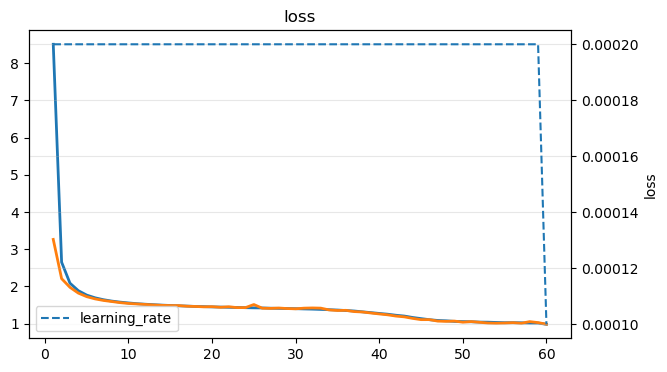

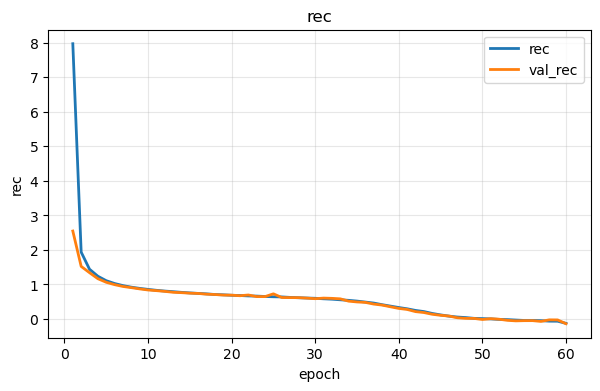

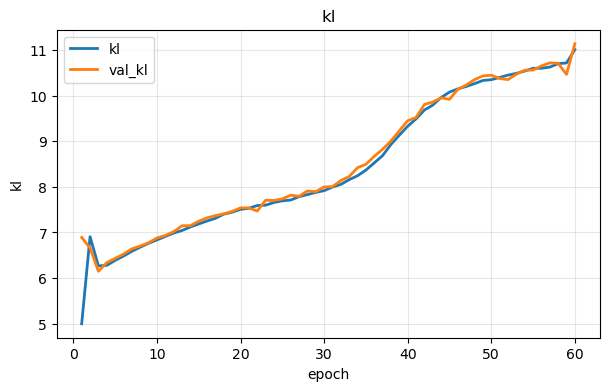

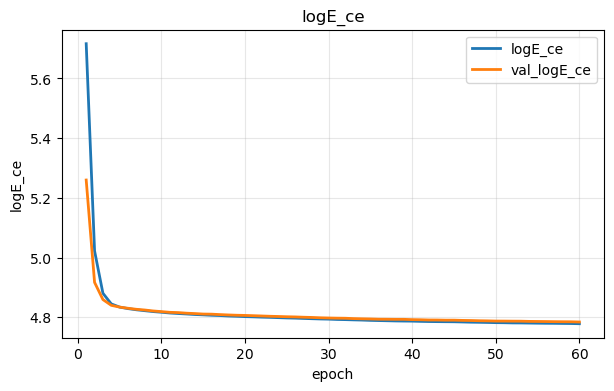

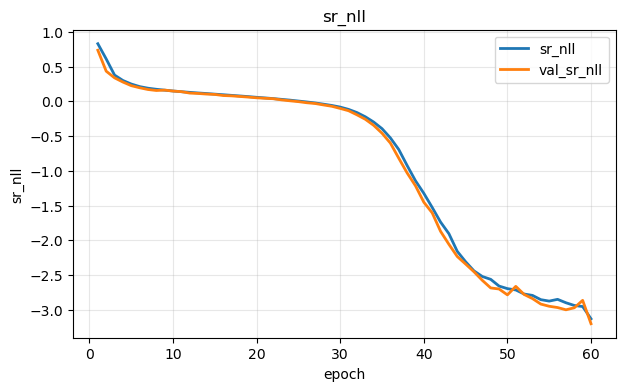

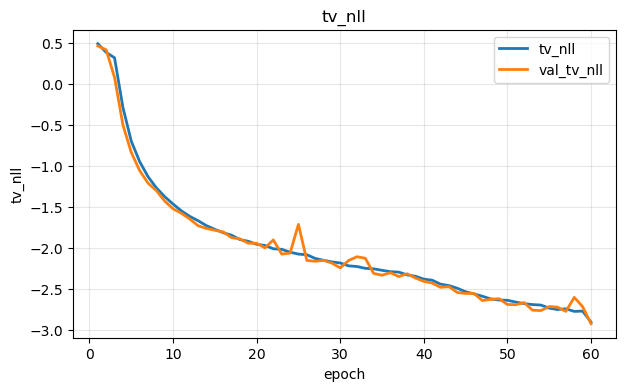

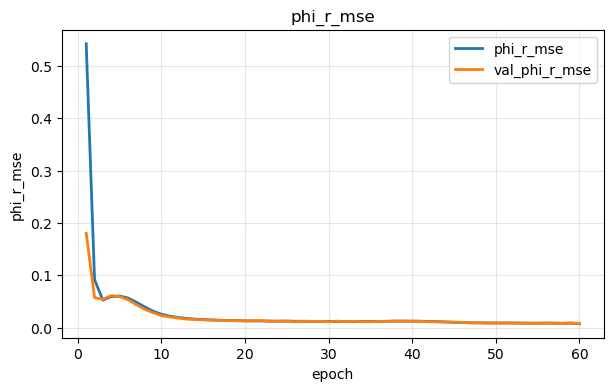

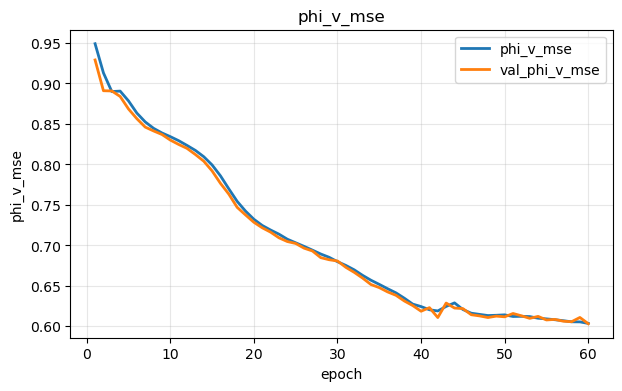

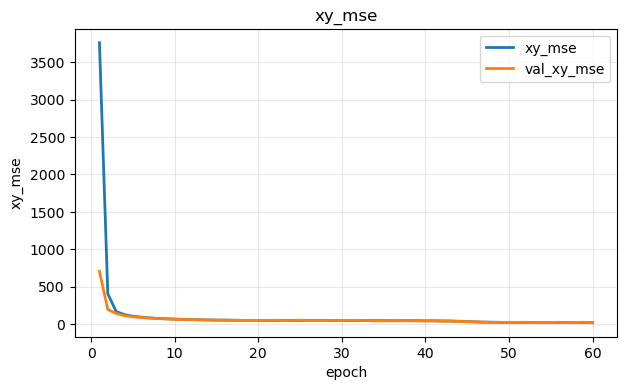

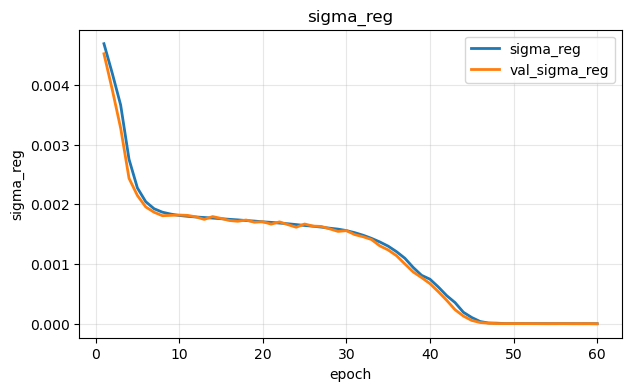

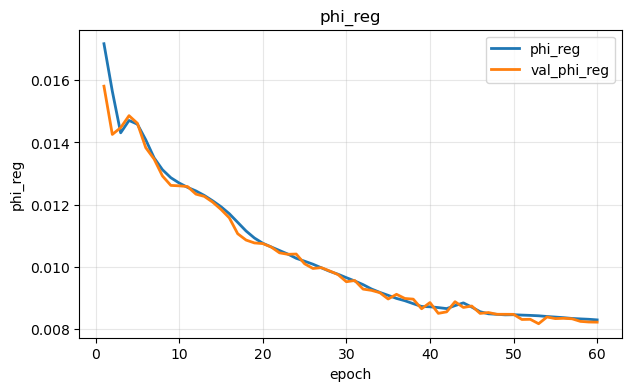

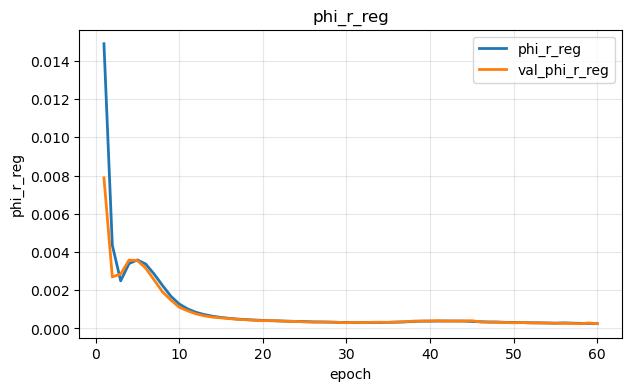

In [171]:
def plot_history(history, keys=None, show_available=True):
    h = history.history

    if show_available:
        print("\nAvailable history keys:")
        print(list(h.keys()))

    # ==========================================================
    # Metriche default per CVAE_CatLogE_GaussTV
    # ==========================================================
    if keys is None:
        keys = [
            "loss",
            "rec",
            "kl",

            # energia
            "logE_ce",

            # posizione polare
            "sr_nll",

            # direzione polare trasformata (ora su t_v)
            "tv_nll",

            # direzioni azimutali
            "phi_r_mse",
            "phi_v_mse",

            # loss geometrica
            "xy_mse",

            # regularizers
            "sigma_reg",
            "phi_reg",
            "phi_r_reg",
        ]

    # ==========================================================
    # numero epoche
    # ==========================================================
    if "loss" in h:
        n_ep = len(h["loss"])
    else:
        n_ep = len(next(iter(h.values())))

    epochs = np.arange(1, n_ep + 1)

    has_lr = ("learning_rate" in h)

    # ==========================================================
    # plotting
    # ==========================================================
    for k in keys:

        if k not in h:
            print("Metric not present:", k)
            continue

        plt.figure(figsize=(7, 4))

        plt.plot(
            epochs,
            h[k],
            label=k,
            linewidth=2
        )

        val_k = "val_" + k

        if val_k in h:
            plt.plot(
                epochs,
                h[val_k],
                label=val_k,
                linewidth=2
            )

        # learning rate solo sul grafico della loss
        if k == "loss" and has_lr:
            ax1 = plt.gca()
            ax2 = ax1.twinx()

            ax2.plot(
                epochs,
                h["learning_rate"],
                linestyle="--",
                label="learning_rate"
            )

            ax2.set_ylabel("learning_rate")
            ax2.legend(loc="upper right")

        plt.xlabel("epoch")
        plt.ylabel(k)
        plt.title(k)

        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.show()

# ==========================================================
# uso standard
# ==========================================================
plot_history(history)

### Confronto e Validazione

In [172]:
def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

def sample_types(n_samples, type_probs, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.choice(len(type_probs), size=n_samples, p=type_probs)
    return idx.astype(np.int32)

def one_hot_from_idx(idx, n_types):
    return tf.one_hot(idx, depth=n_types, dtype=tf.float32)

# ==========================================================
# Generazione tipi di particella
# ==========================================================
NGEN = len(X_test)   # confronto 1:1 col test set

gen_type_idx = sample_types(NGEN, type_probs)
gen_cond = one_hot_from_idx(gen_type_idx, n_types)

unique, counts = np.unique(gen_type_idx, return_counts=True)

print("\nGenerated particle counts:")
for u, c in zip(unique, counts):
    print(idx_to_type[u], c)

# ==========================================================
# Generazione feature nello spazio del training
# y_gen_scaled = [logE_s, s_r_s, cphi_r, sphi_r, t_v_s, cphi_v, sphi_v]
# ==========================================================
y_gen_scaled = model.generate_y(gen_cond, NGEN).numpy().astype(np.float32)

# ==========================================================
# Unscale delle feature scalate
# - col 0 = logE
# - col 1 = s_r
# - col 4 = t_v
# ==========================================================
y_gen = y_gen_scaled.copy()

# unscale logE
y_gen[:, 0] = y_gen_scaled[:, 0] * logE_std + logE_mean

# unscale s_r
y_gen[:, 1] = y_gen_scaled[:, 1] * s_r_std + s_r_mean

# unscale t_v
y_gen[:, 4] = y_gen_scaled[:, 4] * t_v_std + t_v_mean

# ==========================================================
# Energia fisica
# ==========================================================
E_gen = np.power(10.0, y_gen[:, 0], dtype=np.float32)

# ==========================================================
# Check fisico su u_v ricostruito da t_v
# t_v -> s_v -> u_v
# ==========================================================
s_v_gen = signed_expm1(y_gen[:, 4])
u_v_gen = np.tanh(s_v_gen)

# ==========================================================
# Check rapidi
# ==========================================================
print("\n--- Generated feature ranges ---")
print("logE_gen min/max:", y_gen[:, 0].min(), y_gen[:, 0].max())
print("s_r_gen  min/max:", y_gen[:, 1].min(), y_gen[:, 1].max())
print("t_v_gen  min/max:", y_gen[:, 4].min(), y_gen[:, 4].max())
print("s_v_gen  min/max:", s_v_gen.min(), s_v_gen.max())
print("u_v_gen  min/max:", u_v_gen.min(), u_v_gen.max())
print("E_gen    min/max:", E_gen.min(), E_gen.max())

print("\nGenerated fractions by type:")
for u, c in zip(unique, counts):
    print(f"{idx_to_type[u]:>8s}: {c / NGEN:.6f}")


Generated particle counts:
gamma 278903
e- 2137

--- Generated feature ranges ---
logE_gen min/max: -2.8378081 0.08520669
s_r_gen  min/max: -4.2629294 4.08563
t_v_gen  min/max: -2.087514 0.06552452
s_v_gen  min/max: -7.0648403 0.067718916
u_v_gen  min/max: -0.99999857 0.06761559
E_gen    min/max: 0.0014527533 1.2167649

Generated fractions by type:
   gamma: 0.992396
      e-: 0.007604


In [173]:
# Ricostruzione posizione e direzione da feature generate
C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-6

def renorm_cos_sin(c, s, eps=1e-12):
    r = np.sqrt(c*c + s*s) + eps
    return c/r, s/r

def u_from_s(s):
    # trasforma una variabile non limitata s in u in (-1, 1)
    return np.tanh(s)

def signed_expm1(y):
    # inversa di signed_log1p
    return np.sign(y) * np.expm1(np.abs(y))

# ==========================================================
# Estrai feature generate
# y = [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

s_r_gen = y_gen[:, 1]
u_r_gen = u_from_s(s_r_gen)

t_v_gen = y_gen[:, 4]
s_v_gen = signed_expm1(t_v_gen)
u_v_gen = u_from_s(s_v_gen)

# ==========================================================
# POSIZIONE su sfera
# ==========================================================

cpr_gen, spr_gen = renorm_cos_sin(y_gen[:, 2], y_gen[:, 3])
sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen * u_r_gen))

x_gen = C[0] + R * sin_tr_gen * cpr_gen
ypos_gen = C[1] + R * sin_tr_gen * spr_gen
z_gen = C[2] + R * u_r_gen

# ==========================================================
# DIREZIONE: (t_v, phi_v) -> s_v -> u_v -> (vx, vy, vz)
# ==========================================================

# clip solo per sicurezza numerica dopo la tanh
u_v_gen = np.clip(u_v_gen, -1.0 + eps, 1.0 - eps)

cpv_gen, spv_gen = renorm_cos_sin(y_gen[:, 5], y_gen[:, 6])
sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen * u_v_gen))

vx_gen = sin_tv_gen * cpv_gen
vy_gen = sin_tv_gen * spv_gen
vz_gen = u_v_gen

# ==========================================================
# Sanity check vincoli
# ==========================================================

rvec_gen = np.vstack([x_gen, ypos_gen, z_gen]).T - C[None, :]
r_gen = np.linalg.norm(rvec_gen, axis=1)

vnorm_gen_check = np.sqrt(vx_gen * vx_gen + vy_gen * vy_gen + vz_gen * vz_gen)

phi_r_norm = np.sqrt(cpr_gen * cpr_gen + spr_gen * spr_gen)
phi_v_norm = np.sqrt(cpv_gen * cpv_gen + spv_gen * spv_gen)

print("--- VINCOLI ---")
print("r_gen: mean", r_gen.mean(), "std", r_gen.std(), "min", r_gen.min(), "max", r_gen.max())
print("mean |r-R| =", np.mean(np.abs(r_gen - R)))

print("||v||: mean", vnorm_gen_check.mean(), "std", vnorm_gen_check.std(),
      "min", vnorm_gen_check.min(), "max", vnorm_gen_check.max())
print("mean ||v||-1| =", np.mean(np.abs(vnorm_gen_check - 1.0)))

print("phi_r norm: mean", phi_r_norm.mean(), "std", phi_r_norm.std(),
      "min", phi_r_norm.min(), "max", phi_r_norm.max())
print("phi_v norm: mean", phi_v_norm.mean(), "std", phi_v_norm.std(),
      "min", phi_v_norm.min(), "max", phi_v_norm.max())

print("E_gen: min", E_gen.min(), "max", E_gen.max())
print("u_r_gen min/max:", u_r_gen.min(), u_r_gen.max())
print("t_v_gen min/max:", t_v_gen.min(), t_v_gen.max())
print("s_v_gen min/max:", s_v_gen.min(), s_v_gen.max())
print("u_v_gen min/max:", u_v_gen.min(), u_v_gen.max())
print("fraction u_v_gen > 0:", np.mean(u_v_gen > 0))

--- VINCOLI ---
r_gen: mean 99.9999999823031 std 4.164326021600238e-06 min 99.99998098672255 max 100.0000198198057
mean |r-R| = 3.2711470684202185e-06
||v||: mean 1.0 std 3.550071e-08 min 0.9999998 max 1.0000001
mean ||v||-1| = 1.7814163e-08
phi_r norm: mean 1.0 std 3.839833e-08 min 0.9999998 max 1.0000001
phi_v norm: mean 1.0 std 3.6527243e-08 min 0.9999998 max 1.0000001
E_gen: min 0.0014527533 max 1.2167649
u_r_gen min/max: -0.99960357 0.9994349
t_v_gen min/max: -2.087514 0.06552452
s_v_gen min/max: -7.0648403 0.067718916
u_v_gen min/max: -0.99999857 0.06761559
fraction u_v_gen > 0: 0.021327924850555083


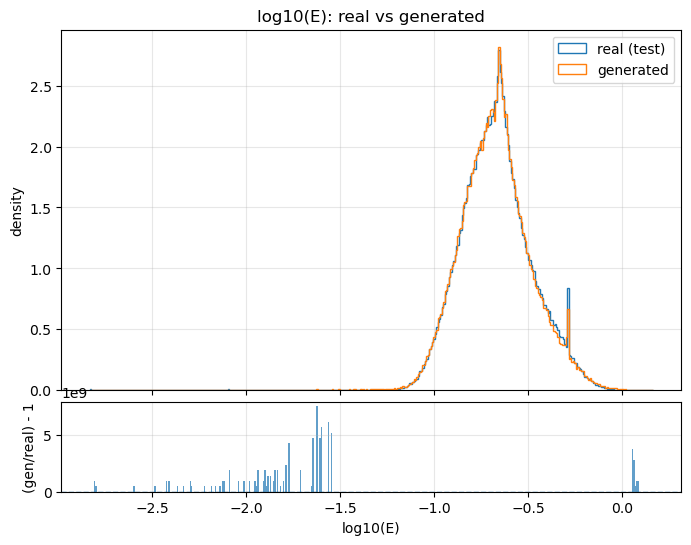

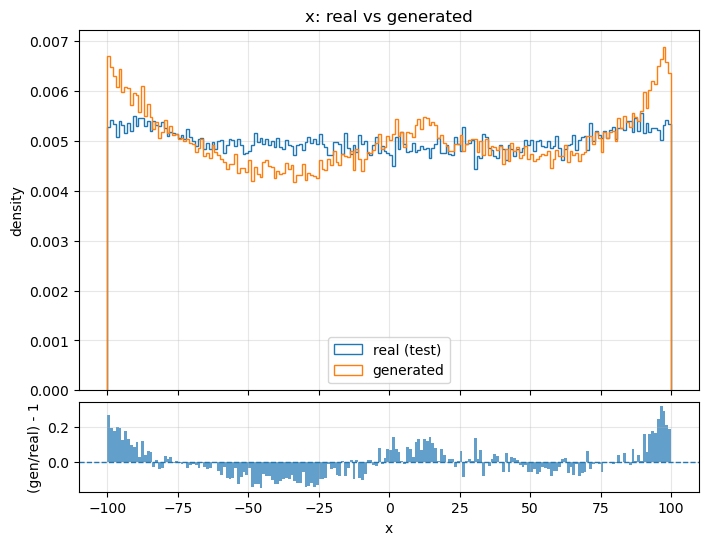

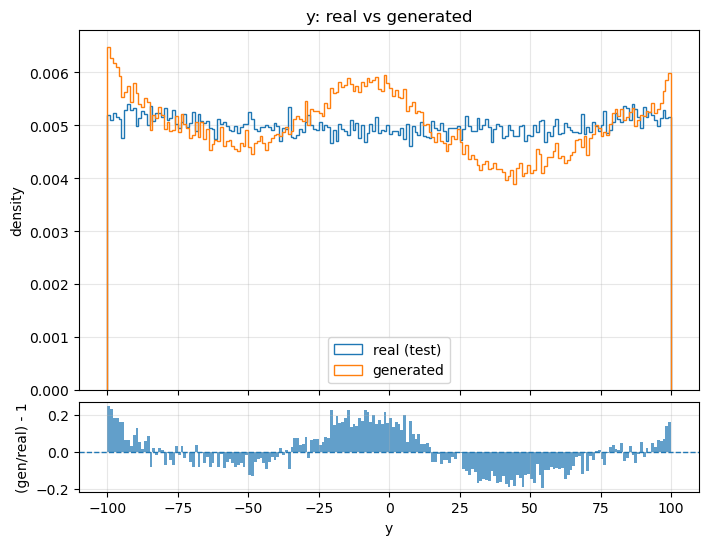

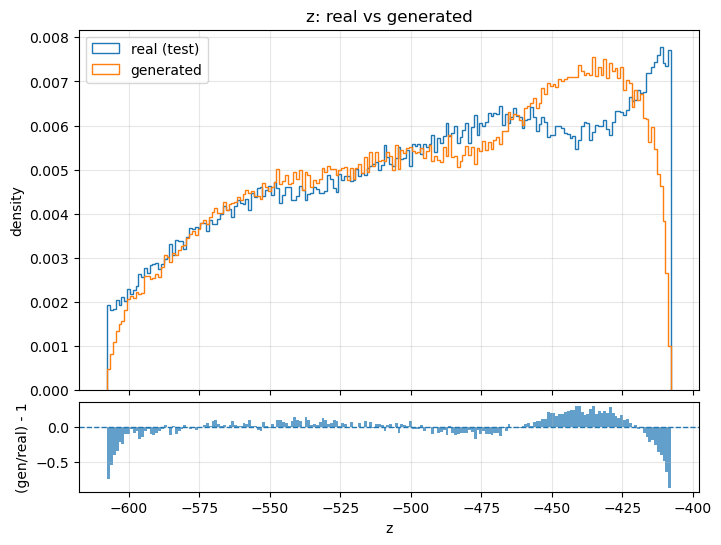

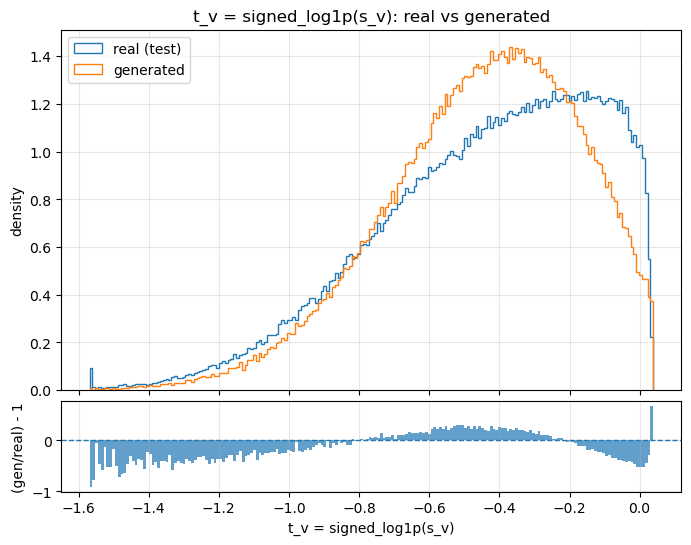

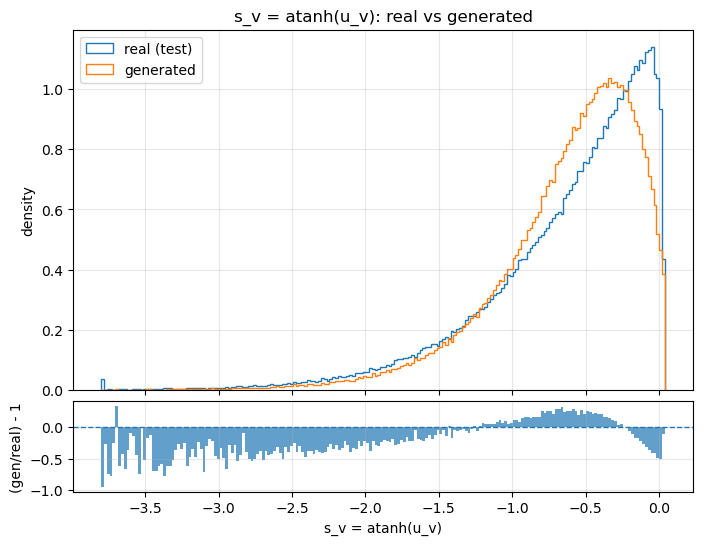

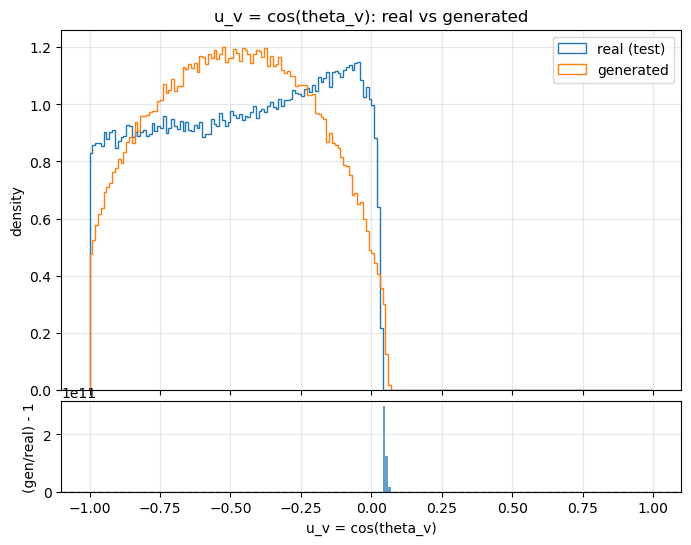

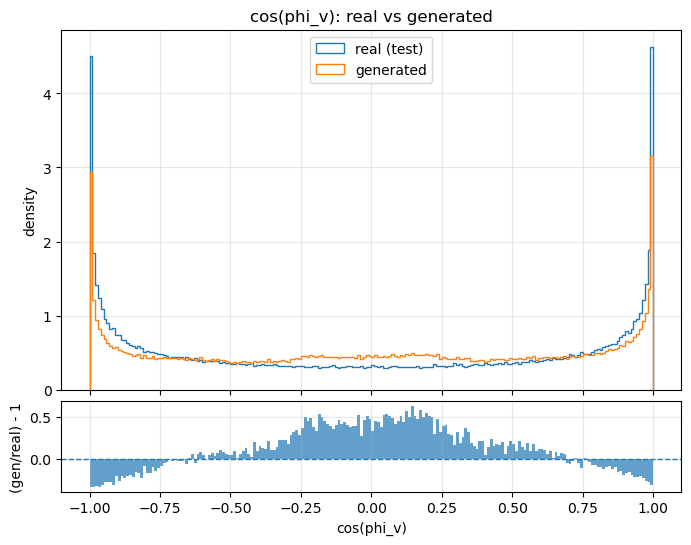

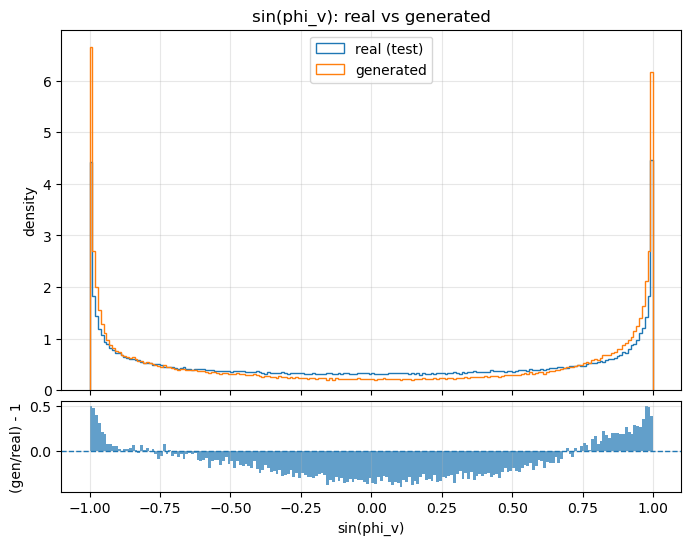

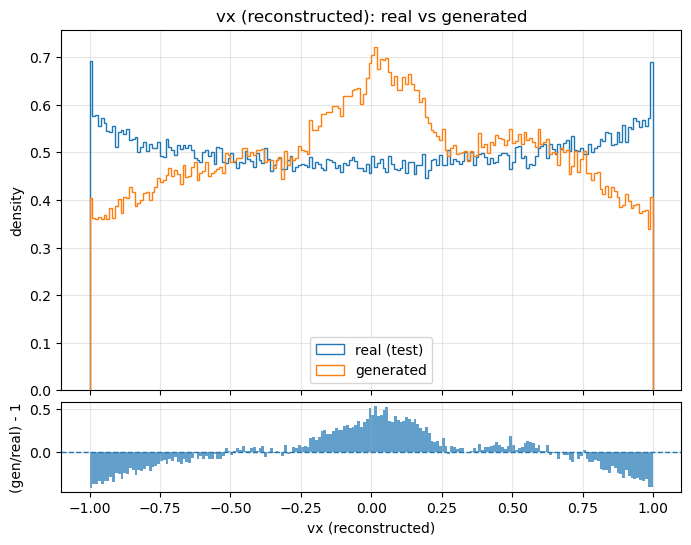

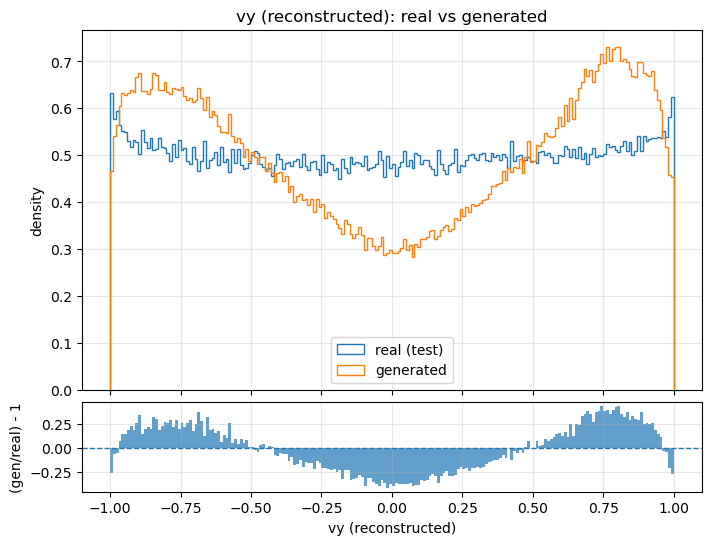

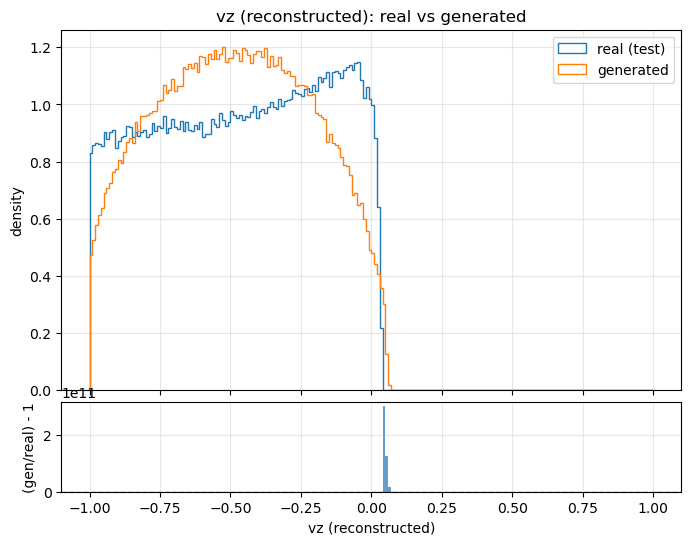


--- RANGE CHECK ---
logE real/gen: -2.833067 0.1645967 | -2.8378081 0.08520669
x real/gen: -99.99797058105469 99.99978637695312 | -100.0 99.99945831298828
y real/gen: -99.99983978271484 99.99964904785156 | -99.99882507324219 99.99982452392578
z real/gen: -607.560001525879 -407.7599984741211 | -607.6203576660157 -407.716510925293
t_v real/gen: -1.5686579 0.038704 | -2.087514 0.06552452
s_v real/gen: -3.8002014 0.039462756 | -7.0648403 0.067718916
u_v real/gen: -0.999 0.039442282 | -0.99999857 0.06761559
cos(phi_v) real/gen: -1.0 1.0 | -1.0 1.0
sin(phi_v) real/gen: -1.0 1.0 | -1.0 1.0
vx rec real/gen: -0.9999941 0.9999954 | -0.9999968 0.9999981
vy rec real/gen: -0.9999958 0.9999981 | -0.99999326 0.99999744
vz rec real/gen: -0.999 0.039442282 | -0.99999857 0.06761559

--- COS/SIN NORM CHECK ---
phi_r real/gen: 1.0 1.0
phi_v real/gen: 1.0 1.0


In [174]:
eps = 1e-6

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

# ==========================================================
# DATI REALI (test) in scala fisica / feature non scalate
# layout: [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

# Usa direttamente la copia RAW costruita nella cella di split
# (se non esiste, fallback su X_test)
if "X_test_unscaled" in globals():
    X_real = X_test_unscaled.copy()
else:
    X_real = X_test.copy()

# -------------------------------
# Energia reale
# -------------------------------
logE_real_test = X_real[:, 0]

# -------------------------------
# Posizione reale
# -------------------------------
s_r_real = X_real[:, 1]
u_r_real = np.tanh(s_r_real)

cphi_r_real = X_real[:, 2].copy()
sphi_r_real = X_real[:, 3].copy()

norm_r = np.sqrt(cphi_r_real**2 + sphi_r_real**2) + 1e-12
cphi_r_real /= norm_r
sphi_r_real /= norm_r

sin_tr_real = np.sqrt(np.maximum(0.0, 1.0 - u_r_real**2))

x_real = C[0] + R * sin_tr_real * cphi_r_real
y_real = C[1] + R * sin_tr_real * sphi_r_real
z_real = C[2] + R * u_r_real

# -------------------------------
# Direzione reale
# t_v -> s_v -> u_v
# -------------------------------
t_v_real = X_real[:, 4].copy()
s_v_real = signed_expm1(t_v_real)
u_v_real = np.tanh(s_v_real)
u_v_real = np.clip(u_v_real, -1.0 + eps, 1.0 - eps)

cphi_v_real = X_real[:, 5].copy()
sphi_v_real = X_real[:, 6].copy()

norm_v = np.sqrt(cphi_v_real**2 + sphi_v_real**2) + 1e-12
cphi_v_real /= norm_v
sphi_v_real /= norm_v

sin_tv_real = np.sqrt(np.maximum(0.0, 1.0 - u_v_real**2))
vx_real = sin_tv_real * cphi_v_real
vy_real = sin_tv_real * sphi_v_real
vz_real = u_v_real

vnorm_real = np.sqrt(vx_real**2 + vy_real**2 + vz_real**2) + 1e-12
vx_real /= vnorm_real
vy_real /= vnorm_real
vz_real /= vnorm_real

# ==========================================================
# DATI GENERATI
# y_gen layout: [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

logE_gen = y_gen[:, 0]

# -------------------------------
# Posizione generata
# -------------------------------
s_r_gen = y_gen[:, 1]
u_r_gen = np.tanh(s_r_gen)

cphi_r_gen = y_gen[:, 2].copy()
sphi_r_gen = y_gen[:, 3].copy()

norm_rg = np.sqrt(cphi_r_gen**2 + sphi_r_gen**2) + 1e-12
cphi_r_gen /= norm_rg
sphi_r_gen /= norm_rg

sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen**2))

x_gen = C[0] + R * sin_tr_gen * cphi_r_gen
ypos_gen = C[1] + R * sin_tr_gen * sphi_r_gen
z_gen = C[2] + R * u_r_gen

# -------------------------------
# Direzione generata
# t_v -> s_v -> u_v
# -------------------------------
t_v_gen = y_gen[:, 4].copy()
s_v_gen = signed_expm1(t_v_gen)
u_v_gen = np.tanh(s_v_gen)
u_v_gen = np.clip(u_v_gen, -1.0 + eps, 1.0 - eps)

cphi_v_gen = y_gen[:, 5].copy()
sphi_v_gen = y_gen[:, 6].copy()

norm_vg = np.sqrt(cphi_v_gen**2 + sphi_v_gen**2) + 1e-12
cphi_v_gen /= norm_vg
sphi_v_gen /= norm_vg

sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen**2))
vx_gen_rec = sin_tv_gen * cphi_v_gen
vy_gen_rec = sin_tv_gen * sphi_v_gen
vz_gen = u_v_gen

vnorm_gen = np.sqrt(vx_gen_rec**2 + vy_gen_rec**2 + vz_gen**2) + 1e-12
vx_gen_rec /= vnorm_gen
vy_gen_rec /= vnorm_gen
vz_gen /= vnorm_gen

# ==========================================================
# FUNZIONE PLOT CON PANNELLO RESIDUI
# ==========================================================
def compare_hist_with_residuals(real, gen, name, bins=200, range_=None,
                                residual_mode="ratio-1", eps_res=1e-12):
    """
    residual_mode:
      - "diff"    -> gen_density - real_density
      - "ratio-1" -> gen_density / real_density - 1
    """
    real = np.asarray(real)
    gen = np.asarray(gen)

    # istogrammi con stessi bin
    real_hist, bin_edges = np.histogram(real, bins=bins, range=range_, density=True)
    gen_hist, _          = np.histogram(gen,  bins=bin_edges, density=True)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)

    if residual_mode == "ratio-1":
        residuals = gen_hist / np.maximum(real_hist, eps_res) - 1.0
        resid_ylabel = "(gen/real) - 1"
    else:
        residuals = gen_hist - real_hist
        resid_ylabel = "gen - real"

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(8, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05}
    )

    # pannello superiore
    ax_top.hist(real, bins=bin_edges, density=True, histtype="step", label="real (test)")
    ax_top.hist(gen,  bins=bin_edges, density=True, histtype="step", label="generated")
    ax_top.set_ylabel("density")
    ax_top.set_title(f"{name}: real vs generated")
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)

    # pannello residui
    ax_bot.axhline(0.0, linestyle="--", linewidth=1)
    ax_bot.bar(bin_centers, residuals, width=bin_widths, align="center", alpha=0.7)
    ax_bot.set_xlabel(name)
    ax_bot.set_ylabel(resid_ylabel)
    ax_bot.grid(True, alpha=0.3)

    plt.show()

# ==========================================================
# PLOT: Energia
# ==========================================================
compare_hist_with_residuals(logE_real_test, logE_gen, "log10(E)", bins=400)

# ==========================================================
# PLOT: Posizione ricostruita
# ==========================================================
compare_hist_with_residuals(x_real, x_gen, "x")
compare_hist_with_residuals(y_real, ypos_gen, "y")
compare_hist_with_residuals(z_real, z_gen, "z")

# ==========================================================
# PLOT: Direzione - FEATURE
# ==========================================================
compare_hist_with_residuals(t_v_real,    t_v_gen,    "t_v = signed_log1p(s_v)")
compare_hist_with_residuals(s_v_real,    s_v_gen,    "s_v = atanh(u_v)")
compare_hist_with_residuals(u_v_real,    u_v_gen,    "u_v = cos(theta_v)", range_=(-1, 1))
compare_hist_with_residuals(cphi_v_real, cphi_v_gen, "cos(phi_v)",         range_=(-1, 1))
compare_hist_with_residuals(sphi_v_real, sphi_v_gen, "sin(phi_v)",         range_=(-1, 1))

# ==========================================================
# PLOT: Direzione - CARTESIANA ricostruita
# ==========================================================
compare_hist_with_residuals(vx_real, vx_gen_rec, "vx (reconstructed)", range_=(-1, 1))
compare_hist_with_residuals(vy_real, vy_gen_rec, "vy (reconstructed)", range_=(-1, 1))
compare_hist_with_residuals(vz_real, vz_gen,     "vz (reconstructed)", range_=(-1, 1))

# ==========================================================
# RANGE CHECK
# ==========================================================
print("\n--- RANGE CHECK ---")
print("logE real/gen:", logE_real_test.min(), logE_real_test.max(), "|", logE_gen.min(), logE_gen.max())

print("x real/gen:", x_real.min(), x_real.max(), "|", x_gen.min(), x_gen.max())
print("y real/gen:", y_real.min(), y_real.max(), "|", ypos_gen.min(), ypos_gen.max())
print("z real/gen:", z_real.min(), z_real.max(), "|", z_gen.min(), z_gen.max())

print("t_v real/gen:", t_v_real.min(), t_v_real.max(), "|", t_v_gen.min(), t_v_gen.max())
print("s_v real/gen:", s_v_real.min(), s_v_real.max(), "|", s_v_gen.min(), s_v_gen.max())
print("u_v real/gen:", u_v_real.min(), u_v_real.max(), "|", u_v_gen.min(), u_v_gen.max())

print("cos(phi_v) real/gen:", cphi_v_real.min(), cphi_v_real.max(), "|", cphi_v_gen.min(), cphi_v_gen.max())
print("sin(phi_v) real/gen:", sphi_v_real.min(), sphi_v_real.max(), "|", sphi_v_gen.min(), sphi_v_gen.max())

print("vx rec real/gen:", vx_real.min(), vx_real.max(), "|", vx_gen_rec.min(), vx_gen_rec.max())
print("vy rec real/gen:", vy_real.min(), vy_real.max(), "|", vy_gen_rec.min(), vy_gen_rec.max())
print("vz rec real/gen:", vz_real.min(), vz_real.max(), "|", vz_gen.min(), vz_gen.max())

# check norme cos/sin
norm_phi_r_real = np.sqrt(cphi_r_real**2 + sphi_r_real**2)
norm_phi_r_gen  = np.sqrt(cphi_r_gen**2  + sphi_r_gen**2)
norm_phi_v_real = np.sqrt(cphi_v_real**2 + sphi_v_real**2)
norm_phi_v_gen  = np.sqrt(cphi_v_gen**2  + sphi_v_gen**2)

print("\n--- COS/SIN NORM CHECK ---")
print("phi_r real/gen:", norm_phi_r_real.mean(), norm_phi_r_gen.mean())
print("phi_v real/gen:", norm_phi_v_real.mean(), norm_phi_v_gen.mean())